In [2]:


import numpy as np
import pandas as pd
import os
from pathlib import Path
from dotenv import load_dotenv
import re
import platform
import pymssql  # вместо pyodbc
from datetime import datetime, timedelta

# Загружаем переменные из .env файла
load_dotenv('/home/jovyan/work/.env')

class DatabaseChecker:
    """Класс для изъятия цен на прошедшие продажи из БД"""

    def __init__(self, use_sa_login=True):
        """
        use_sa_login: если True, использует SQL-логин (sa)
                     если False, использует доменную аутентификацию (только для Windows)
        """
        # Определяем, где мы запущены
        self.is_windows = platform.system() == 'Windows'
        self.is_linux = platform.system() == 'Linux'

        # Берем настройки из .env или используем значения по умолчанию
        self.db_host = os.getenv("DB_HOST", "172.16.0.108")
        self.db_name = os.getenv("DB_NAME", "ВитринаДанных")

        if self.is_linux or use_sa_login:
            # В контейнере используем SQL-логин (sa)
            self.db_user = os.getenv("DB_USER", "sa")
            self.db_password = os.getenv("DB_PASSWORD", "sasa")
            self.auth_type = "SQL логин"
        else:
            # На Windows (локально) оставляем доменную аутентификацию
            self.db_user = None
            self.db_password = None
            self.auth_type = "Windows аутентификация"

        print(f" Подключение через {self.auth_type}")
        print(f"   Сервер: {self.db_host}/{self.db_name}")
        if self.db_user:
            print(f"   Пользователь: {self.db_user}")

        # Не создаём engine заранее, будем создавать подключение при каждом запросе
        self.connection = None

    def get_connection(self):
        """Создаёт подключение к БД"""
        if self.is_windows and not self.db_user:
            # Для Windows с доменной аутентификацией
            import pyodbc
            conn_str = (
                f"DRIVER={os.getenv('DB_DRIVER', 'SQL Server')};"
                f"SERVER={self.db_host};"
                f"DATABASE={self.db_name};"
                f"Trusted_Connection=yes;"
                f"Connection Timeout=120;"
            )
            return pyodbc.connect(conn_str)
        else:
            # Для Linux или SQL-логина
            return pymssql.connect(
                server=self.db_host,
                user=self.db_user,
                password=self.db_password,
                database=self.db_name,
                timeout=120,
                login_timeout=120,
                charset='UTF-8'
            )

    def get_sales_data(self, name=None, years_back=1, limit=50000) -> pd.DataFrame:
        """Получает детальные данные по продажам для указанной номенклатуры"""
        from datetime import datetime, timedelta
        timeout_seconds = 120
        cutoff_date = datetime.now() - timedelta(days=years_back*365)

        if name is None:
            name = input("Название номенклатуры: ")

        try:
            # ДЕТАЛЬНЫЙ ЗАПРОС (без GROUP BY, с городами)
            query = """
            SELECT nomenklatura._Description as [Номенклатура],
                DATEADD(year, -2000, [Дата]) as [Дата],
                [Количество],
                [Цена],
                [Сумма],
                [НДС],
                kontrag._Description as [Контрагент],
                organ._Description as [Организация],
                SSO._description as [город]
            FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
            inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
                on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
            left join [onec-9].upp_2012.dbo._Reference124 as kontrag
                on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
            left join [onec-9].upp_2012.dbo._Reference164 as organ
                on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
                on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
                on obect._fld19781_rrref = kontrag._idrref
            left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
                on svoystvoOB._idrref = obect._fld19782rref
            left join [onec-9].upp_2012.dbo._reference97 as SSO
                on SSO._idrref = obect._fld19783_rrref
            WHERE nomenklatura._Description = %s
                and DATEADD(year, -2000, [Дата]) > %s
                and svoystvoOB._description like '%Населенный пункт%'
            ORDER BY [Дата] DESC
            """

            conn = self.get_connection()
            df = pd.read_sql(query, conn, params=(name, cutoff_date))
            conn.close()

            if len(df) > 0:
                print(f"\n Найдено {len(df)} записей для '{name}'")
                print(f"   Период: с {df['Дата'].min()} по {df['Дата'].max()}")
                return df
            else:
                print(f" Нет данных для '{name}'")
                return pd.DataFrame()

        except Exception as e:
            print(f" Ошибка запроса: {e}")
            return pd.DataFrame()

    def save_to_csv(self, df: pd.DataFrame, filename: str = None) -> str:
        """Сохраняет DataFrame в CSV с безопасным именем"""
        if df.empty:
            print(" Нет данных для сохранения")
            return None

        if filename is None:
            # Очищаем название от недопустимых символов
            item_name = df['Номенклатура'].iloc[0] if not df.empty else "data"
            safe_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', item_name)
            safe_name = safe_name[:50]
            # Сохраняем в папку data, которая примонтирована
            filename = f"/home/jovyan/work/data/raw/{safe_name}_sales_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"

        # Создаем папку, если её нет
        os.makedirs(os.path.dirname(filename), exist_ok=True)

        df.to_csv(filename, index=False, sep=';', encoding='utf-8-sig')
        abs_path = os.path.abspath(filename)
        print(f"\n Данные сохранены в файл: {filename}")
        print(f"   Путь: {abs_path}")
        return filename

    def get_products_with_min_records(self, min_records=300, years_back=1):
        """
        Получает список товаров с количеством записей не меньше min_records
        Возвращает DataFrame с колонками: Номенклатура, записей, сумма, первая_дата, последняя_дата
        """
        from datetime import datetime, timedelta

        cutoff_date = (datetime.now() - timedelta(days=years_back*365)).strftime('%Y-%m-%d')

        query = """
        SELECT 
            nomenklatura._Description as [Номенклатура],
            COUNT(*) as [Количество_записей],
            SUM([Сумма]) as [Общая_сумма],
            MIN(DATEADD(year, -2000, [Дата])) as [Первая_продажа],
            MAX(DATEADD(year, -2000, [Дата])) as [Последняя_продажа]
        FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
        inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
            on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
        WHERE DATEADD(year, -2000, [Дата]) > %s
        GROUP BY nomenklatura._Description
        HAVING COUNT(*) >= %s
        ORDER BY COUNT(*) DESC
        """

        conn = self.get_connection()
        df = pd.read_sql(query, conn, params=(cutoff_date, min_records))
        conn.close()

        print(f" Найдено {len(df)} товаров с >= {min_records} записями")
        return df

    def get_detailed_sales_data(self, name=None, years_back=1, limit=50000) -> pd.DataFrame:
    """Получает ДЕТАЛЬНЫЕ данные по продажам для указанной номенклатуры"""
        from datetime import datetime, timedelta
        
        cutoff_date = datetime.now() - timedelta(days=years_back*365)
    
        if name is None:
            name = input("Название номенклатуры: ")
    
        try:
            query = """
            SELECT TOP %s nomenklatura._Description as [Номенклатура],
                DATEADD(year, -2000, [Дата]) as [Дата],
                [Количество],
                [Цена],
                [Сумма],
                [НДС],
                kontrag._Description as [Контрагент],
                organ._Description as [Организация],
                SSO._description as [город]
            FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
            inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
                on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
            left join [onec-9].upp_2012.dbo._Reference124 as kontrag
                on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
            left join [onec-9].upp_2012.dbo._Reference164 as organ
                on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
                on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
            left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
                on obect._fld19781_rrref = kontrag._idrref
            left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
                on svoystvoOB._idrref = obect._fld19782rref
            left join [onec-9].upp_2012.dbo._reference97 as SSO
                on SSO._idrref = obect._fld19783_rrref
            WHERE nomenklatura._Description = %s
                and DATEADD(year, -2000, [Дата]) > %s
                and svoystvoOB._description like '%Населенный пункт%'
            ORDER BY [Дата] DESC
            """
    
            conn = self.get_connection()
            df = pd.read_sql(query, conn, params=(limit, name, cutoff_date))
            conn.close()
    
            if len(df) > 0:
                print(f"\n Найдено {len(df)} детальных записей для '{name}'")
                return df
            else:
                print(f" Нет данных для '{name}'")
                return pd.DataFrame()
    
        except Exception as e:
            print(f" Ошибка запроса: {e}")
            return pd.DataFrame()

In [30]:
from clickhouse_driver import Client
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# Проверяем, какие базы данных есть
print(" БАЗЫ ДАННЫХ:")
dbs = ch_client.execute("SHOW DATABASES")
for db in dbs:
    print(f"   - {db[0]}")

# Проверяем, какие таблицы в external_data
print("\n ТАБЛИЦЫ В external_data:")
tables = ch_client.execute("SHOW TABLES FROM external_data")
for table in tables:
    print(f"   - {table[0]}")

# Если sales_raw нет, создадим её прямо сейчас
if ('sales_raw',) not in tables:
    print("\n Таблица sales_raw не найдена! Создаем...")
    
    # Убедимся, что база external_data существует
    ch_client.execute("CREATE DATABASE IF NOT EXISTS external_data")
    
    # Создаем таблицу
    ch_client.execute("""
    CREATE TABLE external_data.sales_raw
    (
        `Номенклатура` String,
        `Дата` DateTime,
        `Количество` Float64,
        `Цена` Float64,
        `Сумма` Float64,
        `НДС` Float64,
        `Контрагент` String,
        `Организация` String,
        `город` String
    ) ENGINE = MergeTree()
    ORDER BY (`Дата`)
    """)
    print(" Таблица sales_raw создана")
    
    # Проверим еще раз
    tables = ch_client.execute("SHOW TABLES FROM external_data")
    print("\n ТАБЛИЦЫ ПОСЛЕ СОЗДАНИЯ:")
    for table in tables:
        print(f"   - {table[0]}")
else:
    print("\n Таблица sales_raw уже существует")

 БАЗЫ ДАННЫХ:
   - INFORMATION_SCHEMA
   - default
   - external_data
   - information_schema
   - system

 ТАБЛИЦЫ В external_data:
   - demographic_data
   - inflation_monthly
   - inflation_yearly
   - macro_monthly
   - median_salaries_regional
   - municipal_salaries_detailed
   - regional_salary_ratio
   - salary_groups
   - salary_growth
   - sales_raw
   - weather_hourly

 Таблица sales_raw уже существует


In [29]:
# ЯЧЕЙКА 1: Перезагрузка класса (если нужно)
import importlib
import database_checker

importlib.reload(database_checker)
from database_checker import DatabaseChecker
checker = DatabaseChecker(use_sa_login=True)
print(" Класс перезагружен")

 Товаров с >=300 записями: 0
 Подключение через SQL логин
   Сервер: 172.16.0.108/ВитринаДанных
   Пользователь: sa
 Класс перезагружен


In [31]:
# ЯЧЕЙКА 2: Функция для выгрузки и загрузки
def load_all_sales_to_clickhouse(years_back=1):
    """Выгружает ВСЕ продажи за период и сохраняет в ClickHouse"""
    from datetime import datetime, timedelta
    from clickhouse_driver import Client
    import pandas as pd

    cutoff_date = datetime.now() - timedelta(days=years_back*365)

    query = """
    SELECT 
        nomenklatura._Description as [Номенклатура],
        DATEADD(year, -2000, [Дата]) as [Дата],
        [Количество],
        [Цена],
        [Сумма],
        [НДС],
        kontrag._Description as [Контрагент],
        organ._Description as [Организация],
        SSO._description as [город]
    FROM [ВитринаДанных].[dbo].[ПродажиПервичные] as vypuskProduktNakoplenie
    inner join [onec-9].upp_2012.dbo._Reference154 as nomenklatura
        on nomenklatura._Idrref = vypuskProduktNakoplenie.[НоменклатураИД]
    left join [onec-9].upp_2012.dbo._Reference124 as kontrag
        on kontrag._Idrref = vypuskProduktNakoplenie.[КонтрагентИД]
    left join [onec-9].upp_2012.dbo._Reference164 as organ
        on organ._Idrref = vypuskProduktNakoplenie.[ОрганизацияИД]
    left join [onec-9].upp_2012.dbo._InfoRg19780 as zna4svoy
        on zna4svoy._fld19781_RRRef = vypuskProduktNakoplenie.[ОрганизацияИД]
    left join [onec-9].upp_2012.dbo._InfoRg19780 as obect
        on obect._fld19781_rrref = kontrag._idrref
    left join [onec-9].upp_2012.dbo._Chrc1140 as svoystvoOB
        on svoystvoOB._idrref = obect._fld19782rref
    left join [onec-9].upp_2012.dbo._reference97 as SSO
        on SSO._idrref = obect._fld19783_rrref
    WHERE DATEADD(year, -2000, [Дата]) > %s
        and svoystvoOB._description like '%Населенный пункт%'
    ORDER BY [Дата] DESC
    """

    conn = checker.get_connection()
    print(" Выгружаем все данные из MSSQL...")

    # Загружаем порциями
    chunks = []
    for chunk in pd.read_sql(query, conn, params=(cutoff_date,), chunksize=50000):
        chunks.append(chunk)
        print(f"   Загружено {len(chunk)} записей...")

    df_all = pd.concat(chunks, ignore_index=True)
    conn.close()

    print(f"\n Всего выгружено: {len(df_all)} записей")

    # Подключаемся к ClickHouse
    client = Client(host='my_clickhouse', port=9000, user='default', password='')

    # Загружаем данные
    data_to_insert = [tuple(x) for x in df_all.to_numpy()]
    
    print(f" Загружаем {len(data_to_insert)} записей в ClickHouse...")
    client.execute("INSERT INTO external_data.sales_raw VALUES", data_to_insert)

    print(f" Данные сохранены в ClickHouse")
    return df_all

In [32]:
# ЯЧЕЙКА 3: ВЫПОЛНЯЕМ ВЫГРУЗКУ (это может занять время)
df_all = load_all_sales_to_clickhouse(years_back=1)
print(f" Загружено {len(df_all)} записей")

# ЯЧЕЙКА 4: Проверяем результат
from clickhouse_driver import Client
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# Проверяем количество записей
count = ch_client.execute("SELECT COUNT(*) FROM external_data.sales_raw")[0][0]
print(f" Всего записей в sales_raw: {count}")

# Проверяем первые несколько
sample = ch_client.execute("SELECT * FROM external_data.sales_raw LIMIT 5")
print("\n Пример данных:")
for row in sample:
    print(f"   {row[:2]}...")  # покажем только первые 2 колонки

 Выгружаем все данные из MSSQL...


/tmp/ipykernel_14348/2790480.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  for chunk in pd.read_sql(query, conn, params=(cutoff_date,), chunksize=50000):


   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 50000 записей...
   Загружено 8716 записей...

 Всего выгружено: 558716 записей
 Загружаем 558716 записей в ClickHouse...
 Данные сохранены в ClickHouse
 Загружено 558716 записей
 Всего записей в sales_raw: 558716

 Пример данных:
   ('Сыр ломт.сол.Ашан.40%.Дружба.80г.фол.20шт', datetime.datetime(2025, 3, 16, 9, 41, 27))...
   ('Сыр ломт.сол.Ашан.40%.Дружба.80г.фол.20шт', datetime.datetime(2025, 3, 16, 9, 41, 27))...
   ('Сыр ломт.сол.Ашан.40%.Дружба.80г.фол.20шт', datetime.datetime(2025, 3, 16, 9, 41, 27))...
   ('Пр.пл.с сыром ломт.сол.КД.40%.Салат.80г.фол.20шт', datetime.datetime(2025, 3, 16, 9, 41, 27))...
   ('Пр.пл.с сыром ломт.сол.КД.40%.Салат.80г.фол.20шт', datetime.date

 Подключение через SQL логин
   Сервер: 172.16.0.108/ВитринаДанных
   Пользователь: sa

 Найдено 4 агрегированных записей для 'Мас.Тандер.72,5%.180г.фол.12шт'
Колонки: ['Номенклатура', 'Количество_записей', 'Общая_сумма', 'Среднее_количество', 'Первая_продажа', 'Последняя_продажа', 'Контрагент', 'Организация', 'город']
Города: ['Волгоград' 'Воронеж' 'Тула' 'Тамбов']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import io
import json
from scipy import stats
from minio import Minio
from io import BytesIO

# ============================================
# ФУНКЦИЯ СОХРАНЕНИЯ В MINIO (ИСПРАВЛЕННАЯ)
# ============================================

def save_to_minio(
    bucket_name="sales-analytics", 
    block_name="анализ_продаж", 
    data=None, 
    plot_name=None, 
    fig=None, 
    dpi=150, 
    formats=['png'],
    excel_data=None
):
    """
    Сохраняет данные в Minio
    """
    print(f"\n Сохраняем в Minio: {bucket_name}/{block_name}")
    
    # Подключение к Minio
    minio_endpoint = "host.docker.internal:9002"
    minio_access = "minioadmin"
    minio_secret = "minioadmin"
    
    try:
        client = Minio(
            endpoint=minio_endpoint,
            access_key=minio_access,
            secret_key=minio_secret,
            secure=False
        )
        
        # Проверяем/создаём бакет
        if not client.bucket_exists(bucket_name):
            client.make_bucket(bucket_name)
            print(f" Создан бакет: {bucket_name}")
        
        # Очищаем имя блока
        clean_block = re.sub(r'[<>:"/\\|?*%\'"]', '_', block_name)
        clean_block = clean_block[:50]
        
        # Формируем путь
        current_date = datetime.now().strftime('%Y-%m-%d')
        base_path = f"{current_date}/{clean_block}"
        
        saved_objects = []
        
        # 1. СОХРАНЯЕМ CSV
        if data is not None:
            csv_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"data_{datetime.now().strftime('%Y%m%d_%H%M')}"
            csv_name = csv_name[:100]
            
            csv_buffer = io.StringIO()
            data.to_csv(csv_buffer, index=False, sep=';', encoding='utf-8-sig')
            csv_bytes = csv_buffer.getvalue().encode('utf-8-sig')
            
            object_path = f"{base_path}/{csv_name}.csv"
            client.put_object(
                bucket_name,
                object_path,
                data=BytesIO(csv_bytes),
                length=len(csv_bytes),
                content_type='text/csv; charset=utf-8'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" CSV: {file_url}")
            saved_objects.append(file_url)
        
        # 2. СОХРАНЯЕМ EXCEL
        if excel_data is not None:
            excel_name = f"stats_{datetime.now().strftime('%Y%m%d_%H%M')}.xlsx"
            
            excel_buffer = io.BytesIO()
            with pd.ExcelWriter(excel_buffer, engine='openpyxl') as writer:
                for sheet_name, sheet_data in excel_data.items():
                    sheet_data.to_excel(writer, sheet_name=sheet_name)
            excel_buffer.seek(0)
            
            object_path = f"{base_path}/{excel_name}"
            client.put_object(
                bucket_name,
                object_path,
                data=excel_buffer,
                length=excel_buffer.getbuffer().nbytes,
                content_type='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
            )
            
            file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
            print(f" Excel: {file_url}")
            saved_objects.append(file_url)
        
        # 3. СОХРАНЯЕМ ГРАФИКИ (раздельная логика для разных форматов)
        if fig is not None:
            clean_plot = re.sub(r'[<>:"/\\|?*%\'"]', '_', plot_name) if plot_name else f"plot_{datetime.now().strftime('%Y%m%d_%H%M')}"
            clean_plot = clean_plot[:100]
            
            for fmt in formats:
                img_buffer = io.BytesIO()
                
                try:
                    if fmt == 'pdf':
                        # Для PDF не используем fonttype
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    elif fmt == 'svg':
                        # Для SVG тоже особые настройки не нужны
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt)
                    else:
                        # Для PNG и других растровых форматов
                        fig.savefig(img_buffer, dpi=dpi, bbox_inches='tight', 
                                  facecolor='white', format=fmt, 
                                  pil_kwargs={'optimize': True})
                    
                    img_buffer.seek(0)
                    
                    object_path = f"{base_path}/{clean_plot}.{fmt}"
                    client.put_object(
                        bucket_name,
                        object_path,
                        data=img_buffer,
                        length=img_buffer.getbuffer().nbytes,
                        content_type=f'image/{fmt}'
                    )
                    
                    file_url = f"http://localhost:9003/{bucket_name}/{object_path}"
                    print(f" {fmt.upper()}: {file_url}")
                    saved_objects.append(file_url)
                    
                except Exception as e:
                    print(f" Ошибка при сохранении {fmt}: {e}")
                    continue
        
        print(f"    Всего сохранено: {len(saved_objects)} объектов")
        return saved_objects
        
    except Exception as e:
        print(f" Ошибка при сохранении в Minio: {e}")
        import traceback
        traceback.print_exc()
        return []

In [33]:
import pandas as pd
import numpy as np
from clickhouse_driver import Client

# ============================================
# ПОДКЛЮЧАЕМСЯ К CLICKHOUSE (а не к MSSQL)
# ============================================
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# ============================================
# 1. ПОЛУЧАЕМ СПИСОК ТОВАРОВ ИЗ CLICKHOUSE (ОДИН РАЗ!)
# ============================================
products_df = ch_client.query_dataframe("""
    SELECT 
        `Номенклатура`,
        COUNT(*) as `Количество_записей`,
        SUM(`Сумма`) as `Общая_сумма`,
        MIN(`Дата`) as `Первая_продажа`,
        MAX(`Дата`) as `Последняя_продажа`
    FROM external_data.sales_raw
    GROUP BY `Номенклатура`
    HAVING `Количество_записей` >= 300
    ORDER BY `Количество_записей` DESC
""")

all_products = products_df['Номенклатура'].tolist()

print(f"\n Найдено товаров для анализа: {len(all_products)}")
print("Топ-10 по количеству записей:")
print(products_df.head(10))

# ============================================
# 2. РАЗБИВКА НА БАТЧИ ПО 10 ТОВАРОВ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
batch_size = 10
num_batches = (len(all_products) + batch_size - 1) // batch_size
print(f"\n Всего батчей: {num_batches}")

# Словари для хранения данных по батчам
all_batches_stats = {}

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min(start_idx + batch_size, len(all_products))
    batch_products = all_products[start_idx:end_idx]
    
    print(f"\n{'='*70}")
    print(f" БАТЧ {batch_num + 1}/{num_batches}: товары {start_idx+1}-{end_idx}")
    print('='*70)
    
    # Фильтруем данные для текущего батча
    batch_df = products_df.iloc[start_idx:end_idx].copy()
    
    print("\n Данные батча (агрегированные):")
    print(batch_df[['Номенклатура', 'Количество_записей', 'Общая_сумма']].to_string(index=False))
    
    # Сохраняем статистику батча
    batch_stats = {
        'products': batch_products,
        'total_records': batch_df['Количество_записей'].sum(),
        'total_sum': batch_df['Общая_сумма'].sum(),
        'avg_records': batch_df['Количество_записей'].mean()
    }
    all_batches_stats[batch_num] = batch_stats
    
    print(f"\n Статистика батча:")
    print(f"   Всего записей: {batch_stats['total_records']}")
    print(f"   Общая сумма: {batch_stats['total_sum']:.2f}")
    print(f"   Среднее записей на товар: {batch_stats['avg_records']:.1f}")

# ============================================
# 3. ИТОГОВАЯ СТАТИСТИКА ПО ВСЕМ БАТЧАМ
# ============================================
print(f"\n{'='*70}")
print(" ИТОГОВАЯ СТАТИСТИКА")
print('='*70)

total_records_all = 0
total_sum_all = 0

for batch_num, stats in all_batches_stats.items():
    print(f"\n Батч {batch_num + 1}:")
    print(f"   Товаров: {len(stats['products'])}")
    print(f"   Записей: {stats['total_records']}")
    print(f"   Сумма: {stats['total_sum']:.2f}")
    
    total_records_all += stats['total_records']
    total_sum_all += stats['total_sum']

print(f"\n ИТОГО:")
print(f"   Всего товаров: {len(all_products)}")
print(f"   Всего записей: {total_records_all}")
print(f"   Общая сумма: {total_sum_all:.2f}")


 Найдено товаров для анализа: 236
Топ-10 по количеству записей:
                                        Номенклатура  Количество_записей  \
0                   Поддон стандартный (1,2м * 0,8м)               20488   
1        Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт               12002   
2       Пр.из творога БЛ с изюмом 23%.180г.ф/пак.8шт               11161   
3                Пр.из творога БЛ 24%.500г.пакет.8шт               10576   
4       Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт               10199   
5     Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт                9908   
6  Пр.из творога БЛ со вкус.ванилина 23%.180г.ф/п...                9907   
7     Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт                8140   
8               Пр.со смет.БЛ.20%.400г.ст.12шт.с змж                8138   
9       Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт                8116   

    Общая_сумма      Первая_продажа   Последняя_продажа  
0  8.264500e+02 2025-03-16 11:38:50 2026


 Найдено товаров для анализа: 236

 КЛАСТЕРИЗАЦИЯ ТОВАРОВ...

 АНАЛИЗ КЛАСТЕРОВ:

 КЛАСТЕР 0: 42 товаров
   Среднее записей: 2172
   Коэф. вариации: 1.47 (стабильность)
   Среднее городов: 40.6
   Тип: REGIONAL
   Размер батча: 7
   Примеры: Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20...

 КЛАСТЕР 1: 134 товаров
   Среднее записей: 1168
   Коэф. вариации: 1.45 (стабильность)
   Среднее городов: 14.5
   Тип: REGIONAL
   Размер батча: 7
   Примеры: ПРС.КУ.72,5%.380г.фол.8шт...

 КЛАСТЕР 2: 17 товаров
   Среднее записей: 9122
   Коэф. вариации: 2.19 (стабильность)
   Среднее городов: 41.6
   Тип: VOLATILE
   Размер батча: 6
   Примеры: Поддон стандартный (1,2м * 0,8м)...

 КЛАСТЕР 3: 11 товаров
   Среднее записей: 1193
   Коэф. вариации: 0.71 (стабильность)
   Среднее городов: 5.9
   Тип: REGULAR
   Размер батча: 10
   Примеры: Пр.пл.с сыром ломт.сол.МЦ.50%.Друж.70г.фол.40шт...

 КЛАСТЕР 4: 32 товаров
   Среднее записей: 3497
   Коэф. вариации: 3.55 (стабильность)
   Среднее городов: 28.

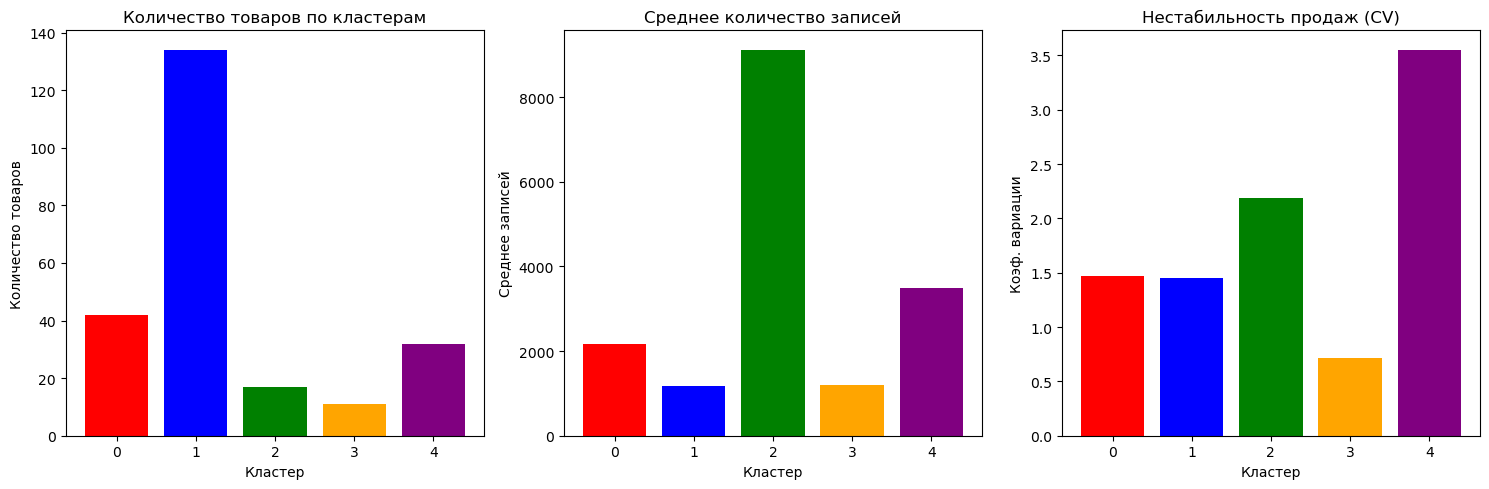


 Статистика по батчам:
   Всего товаров: 236
   Всего батчей: 37
   Средний размер батча: 6.4 товаров


In [3]:
import pandas as pd
import numpy as np
from clickhouse_driver import Client
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================
# ПОДКЛЮЧАЕМСЯ К CLICKHOUSE
# ============================================
ch_client = Client(host='my_clickhouse', port=9000, user='default', password='')

# ============================================
# 1. ПОЛУЧАЕМ ДЕТАЛЬНУЮ ИНФОРМАЦИЮ ПО ТОВАРАМ
# ============================================
products_df = ch_client.query_dataframe("""
    SELECT 
        `Номенклатура`,
        COUNT(*) as record_count,
        SUM(`Сумма`) as total_sum,
        AVG(`Количество`) as avg_quantity,
        stddevSamp(`Количество`) as std_quantity,  --  ИСПРАВЛЕНО: stddevSamp вместо STDDEV
        COUNT(DISTINCT `город`) as city_count,
        COUNT(DISTINCT `Контрагент`) as customer_count,
        MIN(`Дата`) as first_sale,
        MAX(`Дата`) as last_sale
    FROM external_data.sales_raw
    GROUP BY `Номенклатура`
    HAVING record_count >= 300
    ORDER BY record_count DESC
""")

print(f"\n Найдено товаров для анализа: {len(products_df)}")

# Добавляем вычисляемые признаки
products_df['days_on_market'] = (pd.to_datetime(products_df['last_sale']) - 
                                  pd.to_datetime(products_df['first_sale'])).dt.days
products_df['cv'] = products_df['std_quantity'] / products_df['avg_quantity']  # коэффициент вариации
products_df['avg_daily'] = products_df['record_count'] / products_df['days_on_market']

# ============================================
# 2. КЛАСТЕРИЗАЦИЯ ТОВАРОВ
# ============================================
print("\n КЛАСТЕРИЗАЦИЯ ТОВАРОВ...")

# Выбираем признаки для кластеризации
features = ['record_count', 'avg_quantity', 'cv', 'city_count', 'customer_count', 'avg_daily']
X = products_df[features].fillna(0)

# Нормализуем
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Определяем оптимальное количество кластеров
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
products_df['cluster'] = kmeans.fit_predict(X_scaled)

# ============================================
# 3. АНАЛИЗ КЛАСТЕРОВ
# ============================================
print("\n АНАЛИЗ КЛАСТЕРОВ:")
print("=" * 70)

cluster_params = {}

for cluster in range(n_clusters):
    cluster_data = products_df[products_df['cluster'] == cluster]
    
    # Характеристики кластера
    avg_records = cluster_data['record_count'].mean()
    avg_cv = cluster_data['cv'].mean()
    avg_cities = cluster_data['city_count'].mean()
    
    print(f"\n КЛАСТЕР {cluster}: {len(cluster_data)} товаров")
    print(f"   Среднее записей: {avg_records:.0f}")
    print(f"   Коэф. вариации: {avg_cv:.2f} (стабильность)")
    print(f"   Среднее городов: {avg_cities:.1f}")
    
    # Определяем тип кластера на основе реальных данных
    if avg_records > 50000:
        cluster_type = "super_popular"
        batch_size = 5
        params = {
            'n_estimators': 500,
            'learning_rate': 0.03,
            'max_depth': 6,
            'subsample': 0.7,
            'reg_alpha': 0.1
        }
    elif avg_records > 20000:
        cluster_type = "popular"
        batch_size = 8
        params = {
            'n_estimators': 400,
            'learning_rate': 0.04,
            'max_depth': 5,
            'subsample': 0.8,
            'reg_alpha': 0.1
        }
    elif avg_cv > 1.5:  # Нестабильные
        cluster_type = "volatile"
        batch_size = 6
        params = {
            'n_estimators': 800,
            'learning_rate': 0.01,
            'max_depth': 3,
            'subsample': 0.5,
            'reg_alpha': 1.0,
            'reg_lambda': 1.0,
            'min_child_weight': 5
        }
    elif avg_cities > 10:  # Много городов
        cluster_type = "regional"
        batch_size = 7
        params = {
            'n_estimators': 600,
            'learning_rate': 0.02,
            'max_depth': 5,
            'colsample_bytree': 0.7,
            'subsample': 0.7
        }
    else:
        cluster_type = "regular"
        batch_size = 10
        params = {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 4,
            'subsample': 0.8,
            'reg_alpha': 0.2
        }
    
    cluster_params[cluster] = {
        'name': cluster_type,
        'batch_size': batch_size,
        'params': params,
        'products': cluster_data['Номенклатура'].tolist()
    }
    
    print(f"   Тип: {cluster_type.upper()}")
    print(f"   Размер батча: {batch_size}")
    if len(cluster_data) > 0:
        print(f"   Примеры: {cluster_data['Номенклатура'].iloc[0][:50]}...")

# ============================================
# 4. ФОРМИРОВАНИЕ БАТЧЕЙ ПО КЛАСТЕРАМ
# ============================================
print(f"\n{'='*70}")
print(" ФОРМИРОВАНИЕ БАТЧЕЙ")
print('='*70)

all_batches = []
batch_counter = 1

for cluster, info in cluster_params.items():
    products = info['products']
    batch_size = info['batch_size']
    cluster_name = info['name']
    
    if len(products) == 0:
        continue
        
    print(f"\n Кластер {cluster} ({cluster_name.upper()}) - {len(products)} товаров")
    
    # Разбиваем на батчи
    for i in range(0, len(products), batch_size):
        batch_products = products[i:i+batch_size]
        
        batch_info = {
            'batch_num': batch_counter,
            'cluster': cluster,
            'cluster_name': cluster_name,
            'products': batch_products,
            'product_count': len(batch_products),
            'params': info['params'],
            'description': f"{cluster_name}_batch_{batch_counter}"
        }
        
        all_batches.append(batch_info)
        
        print(f"   Батч {batch_counter}: {len(batch_products)} товаров ({cluster_name})")
        
        # Показываем первые товары в батче
        if len(batch_products) > 0:
            print(f"      Например: {batch_products[0][:60]}...")
        
        batch_counter += 1

print(f"\n{'='*70}")
print(f" ВСЕГО БАТЧЕЙ: {len(all_batches)}")
print('='*70)

# ============================================
# 5. ФУНКЦИИ ДЛЯ РАБОТЫ С БАТЧАМИ
# ============================================
def get_batch_params(batch_num):
    """Возвращает параметры для конкретного батча"""
    for batch in all_batches:
        if batch['batch_num'] == batch_num:
            return batch
    return None

def get_product_batch(product_name):
    """Определяет в каком батче находится товар"""
    for batch in all_batches:
        if product_name in batch['products']:
            return batch
    return None

# ============================================
# 6. СОХРАНЯЕМ ИНФОРМАЦИЮ О БАТЧАХ
# ============================================
import json
import os

# Создаем директорию если нет
os.makedirs('/home/jovyan/work/data/processed', exist_ok=True)

batches_info = {
    'total_batches': len(all_batches),
    'total_products': len(products_df),
    'clusters': {}
}

for cluster in range(n_clusters):
    if cluster in cluster_params:
        cluster_data = products_df[products_df['cluster'] == cluster]
        batches_info['clusters'][cluster] = {
            'name': cluster_params[cluster]['name'],
            'product_count': len(cluster_data),
            'batch_size': cluster_params[cluster]['batch_size'],
            'params': cluster_params[cluster]['params']
        }

# Сохраняем в JSON
with open('/home/jovyan/work/data/processed/batch_config.json', 'w', encoding='utf-8') as f:
    json.dump(batches_info, f, ensure_ascii=False, indent=2)

# Сохраняем детальную информацию по батчам
batches_detail = []
for batch in all_batches:
    batches_detail.append({
        'batch_num': batch['batch_num'],
        'cluster': batch['cluster'],
        'cluster_name': batch['cluster_name'],
        'product_count': batch['product_count'],
        'products': batch['products'][:3] if len(batch['products']) > 0 else []
    })

pd.DataFrame(batches_detail).to_csv('/home/jovyan/work/data/processed/batches_detail.csv', index=False)

print(f"\n Информация о батчах сохранена в /home/jovyan/work/data/processed/")

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ КЛАСТЕРОВ
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# График 1: Распределение по кластерам
plt.subplot(1, 3, 1)
cluster_sizes = products_df['cluster'].value_counts().sort_index()
colors = ['red', 'blue', 'green', 'orange', 'purple'][:len(cluster_sizes)]
plt.bar(cluster_sizes.index, cluster_sizes.values, color=colors)
plt.title('Количество товаров по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Количество товаров')

# График 2: Среднее количество записей
plt.subplot(1, 3, 2)
cluster_means = products_df.groupby('cluster')['record_count'].mean()
plt.bar(cluster_means.index, cluster_means.values, color=colors)
plt.title('Среднее количество записей')
plt.xlabel('Кластер')
plt.ylabel('Среднее записей')

# График 3: Коэффициент вариации
plt.subplot(1, 3, 3)
cluster_cv = products_df.groupby('cluster')['cv'].mean()
plt.bar(cluster_cv.index, cluster_cv.values, color=colors)
plt.title('Нестабильность продаж (CV)')
plt.xlabel('Кластер')
plt.ylabel('Коэф. вариации')

plt.tight_layout()
plt.show()

print(f"\n Статистика по батчам:")
print(f"   Всего товаров: {len(products_df)}")
print(f"   Всего батчей: {len(all_batches)}")
print(f"   Средний размер батча: {sum(b['product_count'] for b in all_batches)/len(all_batches):.1f} товаров")

In [ ]:
#перед визуальным анализом нужно добавить все важные внешние признаки

In [37]:
from clickhouse_driver import Client

# Создаем подключение заново
client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# Теперь проверяем
result = client.execute("SELECT COUNT(*) FROM external_data.weather_hourly")
print(f" Всего записей в таблице: {result[0][0]}")

# Посмотрим первые несколько записей
sample = client.execute("SELECT city, timestamp, temperature FROM external_data.weather_hourly LIMIT 5")
print("\nПример данных:")
for row in sample:
    print(f"   {row}")


 Всего записей в таблице: 63418

Пример данных:
   ('Адыге-Хабль аул.', datetime.datetime(2025, 1, 1, 12, 0, tzinfo=<DstTzInfo 'Europe/Moscow' MSK+3:00:00 STD>), 3.0999999046325684)
   ('Адыге-Хабль аул.', datetime.datetime(2025, 1, 2, 12, 0, tzinfo=<DstTzInfo 'Europe/Moscow' MSK+3:00:00 STD>), 4.300000190734863)
   ('Адыге-Хабль аул.', datetime.datetime(2025, 1, 3, 12, 0, tzinfo=<DstTzInfo 'Europe/Moscow' MSK+3:00:00 STD>), 3.0)
   ('Адыге-Хабль аул.', datetime.datetime(2025, 1, 4, 12, 0, tzinfo=<DstTzInfo 'Europe/Moscow' MSK+3:00:00 STD>), 3.0999999046325684)
   ('Адыге-Хабль аул.', datetime.datetime(2025, 1, 5, 12, 0, tzinfo=<DstTzInfo 'Europe/Moscow' MSK+3:00:00 STD>), -1.399999976158142)


In [7]:
import pandas as pd
import json
from clickhouse_driver import Client

# ============================================
# 1. ЗАГРУЖАЕМ ИНФОРМАЦИЮ О БАТЧАХ
# ============================================

# Загружаем детальную информацию
batches_df = pd.read_csv('/home/jovyan/work/data/processed/batches_detail.csv')
print(f" Всего батчей: {len(batches_df)}")
print(batches_df.head(10))

# Загружаем конфигурацию
with open('/home/jovyan/work/data/processed/batch_config.json', 'r') as f:
    batch_config = json.load(f)

print("\n КОНФИГУРАЦИЯ КЛАСТЕРОВ:")
for cluster, info in batch_config['clusters'].items():
    print(f"   Кластер {cluster} ({info['name']}): {info['product_count']} товаров, батч по {info['batch_size']}")

# ============================================
# 2. ФУНКЦИЯ ДЛЯ ПРОСМОТРА КОНКРЕТНОГО БАТЧА
# ============================================

def show_batch(batch_num):
    """Показывает содержимое батча по номеру"""
    
    # Находим батч в DataFrame
    batch_info = batches_df[batches_df['batch_num'] == batch_num].iloc[0]
    
    print(f"\n{'='*70}")
    print(f" БАТЧ {batch_num}: {batch_info['cluster_name'].upper()}")
    print('='*70)
    print(f"   Кластер: {batch_info['cluster']}")
    print(f"   Тип: {batch_info['cluster_name']}")
    print(f"   Товаров в батче: {batch_info['product_count']}")
    
    # Получаем список товаров (нужно распарсить строку)
    products_str = batch_info['products']
    # Это строка вида "['товар1', 'товар2', 'товар3']"
    import ast
    products = ast.literal_eval(products_str)
    
    print(f"\n ТОВАРЫ В БАТЧЕ:")
    for i, product in enumerate(products, 1):
        print(f"   {i:2d}. {product[:80]}...")
    
    # Показываем параметры для этого типа
    cluster_id = str(int(batch_info['cluster']))
    if cluster_id in batch_config['clusters']:
        params = batch_config['clusters'][cluster_id]['params']
        print(f"\n ПАРАМЕТРЫ МОДЕЛИ ДЛЯ ЭТОГО ТИПА:")
        for param, value in params.items():
            print(f"   {param}: {value}")
    
    return products

# ============================================
# 3. ФУНКЦИЯ ДЛЯ ЗАГРУЗКИ ДАННЫХ БАТЧА ИЗ CLICKHOUSE
# ============================================

def load_batch_data(batch_products):
    """Загружает данные для всех товаров батча из ClickHouse"""
    
    client = Client(
        host='my_clickhouse',
        port=9000,
        user='default',
        password='',
        database='external_data'
    )
    
    all_dfs = []
    
    for i, product in enumerate(batch_products, 1):
        print(f"\n   {i}/{len(batch_products)}: Загрузка {product[:60]}...")
        
        product_escaped = product.replace("'", "\\'")
        
        query = f"""
        SELECT 
            `Номенклатура`,
            `Дата` as date,
            `Количество` as quantity,
            `Цена` as price,
            `Сумма` as amount,
            `НДС` as vat,
            `Контрагент` as counterparty,
            `Организация` as organization,
            `город` as city
        FROM external_data.sales_raw
        WHERE `Номенклатура` = '{product_escaped}'
        ORDER BY `Дата`
        """
        
        try:
            df = client.query_dataframe(query)
            if not df.empty:
                all_dfs.append(df)
                print(f"      ✓ {len(df)} записей, {df['city'].nunique()} городов")
            else:
                print(f"      ✗ Нет данных")
        except Exception as e:
            print(f"      ✗ Ошибка: {e}")
    
    if all_dfs:
        full_df = pd.concat(all_dfs, ignore_index=True)
        return full_df
    else:
        return None

# ============================================
# 4. ФУНКЦИЯ ДЛЯ АНАЛИЗА БАТЧА
# ============================================

def analyze_batch(batch_num):
    """Полный анализ батча: просмотр товаров, загрузка, статистика"""
    
    # Получаем список товаров
    products = show_batch(batch_num)
    
    # Загружаем данные
    print(f"\n{'='*70}")
    print(f" ЗАГРУЗКА ДАННЫХ БАТЧА {batch_num}")
    print('='*70)
    
    df_batch = load_batch_data(products)
    
    if df_batch is not None:
        print(f"\n СТАТИСТИКА БАТЧА {batch_num}:")
        print(f"   Всего записей: {len(df_batch):,}")
        print(f"   Всего товаров: {df_batch['Номенклатура'].nunique()}")
        print(f"   Всего городов: {df_batch['city'].nunique()}")
        print(f"   Общая сумма: {df_batch['amount'].sum():,.2f}")
        print(f"   Период: {df_batch['date'].min().date()} - {df_batch['date'].max().date()}")
        
        # Статистика по каждому товару
        print(f"\n СТАТИСТИКА ПО ТОВАРАМ В БАТЧЕ:")
        product_stats = df_batch.groupby('Номенклатура').agg({
            'date': ['count', 'min', 'max'],
            'amount': 'sum',
            'city': 'nunique'
        }).round(2)
        product_stats.columns = ['записей', 'первая_продажа', 'последняя_продажа', 'сумма', 'городов']
        product_stats = product_stats.sort_values('записей', ascending=False)
        
        for product, stats in product_stats.iterrows():
            print(f"\n   {product[:70]}...")
            print(f"      Записей: {stats['записей']:,.0f}")
            print(f"      Сумма: {stats['сумма']:,.2f}")
            print(f"      Городов: {stats['городов']}")
            print(f"      Период: {stats['первая_продажа'].date()} - {stats['последняя_продажа'].date()}")
        
        return df_batch
    else:
        print(f"\n Не удалось загрузить данные для батча {batch_num}")
        return None

# ============================================
# 5. ИНТЕРАКТИВНЫЙ ВЫБОР БАТЧА
# ============================================

def interactive_batch_selection():
    """Интерактивный выбор батча для анализа"""
    
    print("\n ДОСТУПНЫЕ БАТЧИ:")
    print("-" * 80)
    
    # Группируем по кластерам
    for cluster in sorted(batches_df['cluster'].unique()):
        cluster_batches = batches_df[batches_df['cluster'] == cluster]
        cluster_name = cluster_batches['cluster_name'].iloc[0].upper()
        print(f"\n Кластер {int(cluster)} ({cluster_name}):")
        
        for _, batch in cluster_batches.iterrows():
            print(f"   Батч {int(batch['batch_num']):2d}: {int(batch['product_count'])} товаров")
    
    while True:
        try:
            choice = input("\n Введите номер батча для анализа: ").strip()
            batch_num = int(choice)
            
            if batch_num in batches_df['batch_num'].values:
                return batch_num
            else:
                print(f" Батч {batch_num} не найден. Введите номер от 1 до {len(batches_df)}")
        except ValueError:
            print(" Пожалуйста, введите число")

# ============================================
# 6. СОХРАНЕНИЕ БАТЧА ДЛЯ ДАЛЬНЕЙШЕЙ РАБОТЫ
# ============================================

def save_batch_data(df_batch, batch_num):
    """Сохраняет данные батча для дальнейшей работы"""
    
    filename = f'batch_{batch_num}_data'
    parquet_path = f'/home/jovyan/work/data/processed/{filename}.parquet'
    df_batch.to_parquet(parquet_path)
    
    print(f"\n Данные батча {batch_num} сохранены: {parquet_path}")
    
    # Сохраняем информацию о батче
    batch_info = batches_df[batches_df['batch_num'] == batch_num].iloc[0]
    info = {
        'batch_num': batch_num,
        'cluster': int(batch_info['cluster']),
        'cluster_name': batch_info['cluster_name'],
        'product_count': int(batch_info['product_count']),
        'total_records': len(df_batch),
        'total_amount': float(df_batch['amount'].sum()),
        'unique_cities': int(df_batch['city'].nunique()),
        'date_range': {
            'min': df_batch['date'].min().isoformat(),
            'max': df_batch['date'].max().isoformat()
        }
    }
    
    import json
    info_path = f'/home/jovyan/work/data/processed/batch_{batch_num}_info.json'
    with open(info_path, 'w', encoding='utf-8') as f:
        json.dump(info, f, ensure_ascii=False, indent=2)
    
    print(f" Информация сохранена: {info_path}")
    
    return parquet_path

# ============================================
# 7. ОСНОВНОЙ БЛОК - ВЫБОР И АНАЛИЗ БАТЧА
# ============================================

if __name__ == "__main__":
    # Загружаем информацию о батчах
    batches_df = pd.read_csv('/home/jovyan/work/data/processed/batches_detail.csv')
    
    # Интерактивный выбор
    selected_batch = interactive_batch_selection()
    
    # Анализируем выбранный батч
    df_batch = analyze_batch(selected_batch)
    
    if df_batch is not None:
        # Сохраняем для дальнейшей работы
        save_batch_data(df_batch, selected_batch)
        
        print(f"\n{'='*70}")
        print(f" БАТЧ {selected_batch} ГОТОВ К ДАЛЬНЕЙШЕЙ РАБОТЕ")
        print('='*70)
        print(f"\nТеперь нужно:")
        print(f"   1. Использовать df_batch для feature engineering")
        print(f"   2. Обучить модель с параметрами из конфига")
        print(f"   3. Сравнить с другими батчами")

 Всего батчей: 37
   batch_num  cluster cluster_name  product_count  \
0          1        0     regional              7   
1          2        0     regional              7   
2          3        0     regional              7   
3          4        0     regional              7   
4          5        0     regional              7   
5          6        0     regional              7   
6          7        1     regional              7   
7          8        1     regional              7   
8          9        1     regional              7   
9         10        1     regional              7   

                                            products  
0  ['Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20'...  
1  ['Йогурт.7Утра.2,5%.с киви.двухсл.350г.ст.12шт...  
2  ['Пр.пл.с сыром ломт.слад.БЛ.30%.шок.70г.фол.4...  
3  ['Десерт БЛ.7,2%.с манго-маракуйей.3кг.вед', '...  
4  ['Мол.пр.йогурт.БЛ.5,6%.с клубн.3кг.вед', 'Мол...  
5  ['Марг.скв.смет.БЛ.Классическая.20%.5кг.вед.с ...  
6  ['ПРС.КУ.7


 Введите номер батча для анализа:  1



 БАТЧ 1: REGIONAL
   Кластер: 0
   Тип: regional
   Товаров в батче: 7

 ТОВАРЫ В БАТЧЕ:
    1. Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20...
    2. Пр.со смет.БЛ.20%.200г.ст.8шт.с змж...
    3. Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5...

 ПАРАМЕТРЫ МОДЕЛИ ДЛЯ ЭТОГО ТИПА:
   n_estimators: 600
   learning_rate: 0.02
   max_depth: 5
   colsample_bytree: 0.7
   subsample: 0.7

 ЗАГРУЗКА ДАННЫХ БАТЧА 1

   1/3: Загрузка Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20...
      ✓ 5282 записей, 38 городов

   2/3: Загрузка Пр.со смет.БЛ.20%.200г.ст.8шт.с змж...
      ✓ 5102 записей, 29 городов

   3/3: Загрузка Мол.пр.йогурт.БЛ.1%.с черникой.3кг.вед №5...
      ✓ 5048 записей, 50 городов

 СТАТИСТИКА БАТЧА 1:
   Всего записей: 15,432
   Всего товаров: 3
   Всего городов: 64
   Общая сумма: 416,179,140.18
   Период: 2025-03-16 - 2026-03-15

 СТАТИСТИКА ПО ТОВАРАМ В БАТЧЕ:

   Мол.смет.пр.БЛ.Классическая.10%.5кг.вед.№20...
      Записей: 5,282
      Сумма: 190,344,720.00
      Городов: 38
     

In [60]:
from clickhouse_driver import Client
import pandas as pd
import numpy as np
from datetime import datetime

def enrich_full_dataset(df):
    """
    Обогащает полный датасет всеми внешними признаками из таблиц ClickHouse
    """
    client = Client(
        host='my_clickhouse',
        port=9000,
        user='default',
        password='',
        database='external_data'
    )
    
    # Создаем копию датасета
    df_enriched = df.copy()
    
    # Убеждаемся, что date в правильном формате
    df_enriched['date'] = pd.to_datetime(df_enriched['date'])
    df_enriched['year'] = df_enriched['date'].dt.year
    df_enriched['month'] = df_enriched['date'].dt.month
    df_enriched['day'] = df_enriched['date'].dt.day
    df_enriched['date_only'] = df_enriched['date'].dt.date
    
    print("="*60)
    print(" НАЧИНАЕМ ОБОГАЩЕНИЕ ПОЛНОГО ДАТАСЕТА")
    print("="*60)
    print(f" Исходный датасет: {df_enriched.shape}")
    print(f"   Записей: {len(df_enriched):,}")
    print(f"   Городов: {df_enriched['city'].nunique()}")
    print(f"   Товаров: {df_enriched['Номенклатура'].nunique()}")
    print(f"   Период: {df_enriched['date'].min().date()} - {df_enriched['date'].max().date()}")
    
    # 1. ПОГОДА (weather_hourly) - ИСПРАВЛЕННАЯ ВЕРСИЯ
    print("\n1. ДОБАВЛЯЕМ ПОГОДНЫЕ ДАННЫЕ...")
    
    # Получаем все данные погоды, группируя по дате (без времени)
    weather_query = """
    SELECT 
        city,
        toDate(timestamp) as weather_date,
        AVG(temperature) as avg_temperature,
        MIN(temperature) as min_temperature,
        MAX(temperature) as max_temperature,
        AVG(humidity) as avg_humidity,
        AVG(pressure) as avg_pressure,
        AVG(wind_speed) as avg_wind_speed,
        SUM(precipitation) as daily_precipitation
    FROM weather_hourly
    GROUP BY city, weather_date
    ORDER BY city, weather_date
    """
    
    try:
        weather_df = client.query_dataframe(weather_query)
        print(f"   Загружено {len(weather_df)} записей о погоде")
        
        # Преобразуем weather_date в datetime (без времени)
        weather_df['weather_date'] = pd.to_datetime(weather_df['weather_date'])
        
        # В датасете продаж извлекаем ТОЛЬКО ДАТУ (без времени)
        df_enriched['sale_date'] = pd.to_datetime(df_enriched['date']).dt.date
        df_enriched['sale_date'] = pd.to_datetime(df_enriched['sale_date'])
        
        print(f"\n   Примеры форматов:")
        print(f"   Продажи (первая запись): {df_enriched['date'].iloc[0]} -> дата: {df_enriched['sale_date'].iloc[0]}")
        print(f"   Погода (первая запись): {weather_df['weather_date'].iloc[0]}")
        
        # Мерджим по городу и ДАТЕ (без времени)
        df_before = len(df_enriched)
        df_enriched = df_enriched.merge(
            weather_df,
            left_on=['city', 'sale_date'],
            right_on=['city', 'weather_date'],
            how='left'
        )
        
        # Проверяем результат мерджа
        weather_filled = df_enriched['avg_temperature'].notna().sum()
        weather_pct = (weather_filled / len(df_enriched)) * 100
        print(f"\n   Результат мерджа:")
        print(f"   - Записей с погодой: {weather_filled} из {len(df_enriched)} ({weather_pct:.1f}%)")
        
        # Если все еще мало совпадений, покажем диагностику
        if weather_filled < len(df_enriched) * 0.9:  # меньше 90%
            print("\n   Диагностика:")
            
            # Возьмем первый город для примера
            example_city = df_enriched['city'].iloc[0]
            example_date = df_enriched['sale_date'].iloc[0]
            
            print(f"   Пример: город '{example_city}', дата {example_date.date()}")
            
            # Проверим, есть ли погода для этого города и даты
            weather_check = weather_df[
                (weather_df['city'] == example_city) & 
                (weather_df['weather_date'] == example_date)
            ]
            
            if len(weather_check) == 0:
                print(f"   В погоде НЕТ данных для {example_city} на {example_date.date()}")
                
                # Покажем, какие даты есть в погоде для этого города
                city_weather_dates = weather_df[weather_df['city'] == example_city]['weather_date'].sort_values()
                if len(city_weather_dates) > 0:
                    print(f"   Даты в погоде для {example_city}: {city_weather_dates.iloc[:5].dt.date.tolist()}...")
                else:
                    print(f"   Для города {example_city} вообще нет данных в погоде!")
        
        # Удаляем временные колонки
        df_enriched = df_enriched.drop(columns=['sale_date', 'weather_date'])
        
        # Заполняем пропуски
        print("\n   Заполняем пропуски в погодных данных...")
        
        # Для каждого города интерполируем пропуски
        for city in df_enriched['city'].unique():
            city_mask = df_enriched['city'] == city
            if city_mask.any():
                for col in ['avg_temperature', 'avg_humidity', 'avg_pressure', 'avg_wind_speed', 'daily_precipitation']:
                    if col in df_enriched.columns:
                        # Интерполяция по времени
                        df_enriched.loc[city_mask, col] = (
                            df_enriched.loc[city_mask, col]
                            .interpolate(method='linear', limit_direction='both')
                        )
        
        # Для оставшихся пропусков - заполняем средними по городу
        for col in ['avg_temperature', 'avg_humidity', 'avg_pressure', 'avg_wind_speed', 'daily_precipitation']:
            if col in df_enriched.columns:
                city_means = df_enriched.groupby('city')[col].transform('mean')
                df_enriched[col] = df_enriched[col].fillna(city_means)
        
        # Финальная проверка
        print("\n   Финальное заполнение:")
        for col in ['avg_temperature', 'avg_humidity', 'avg_pressure', 'avg_wind_speed', 'daily_precipitation']:
            if col in df_enriched.columns:
                filled = df_enriched[col].notna().sum()
                pct = (filled / len(df_enriched)) * 100
                print(f"   {col}: заполнено {filled}/{len(df_enriched)} ({pct:.1f}%)")
        
        print(f"   ✓ Погодные данные обработаны")
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке погоды: {e}")
        import traceback
        traceback.print_exc()
    
    # 2. МАКРОЭКОНОМИЧЕСКИЕ ПОКАЗАТЕЛИ (macro_monthly)
    print("\n2. ДОБАВЛЯЕМ МАКРОЭКОНОМИЧЕСКИЕ ПОКАЗАТЕЛИ...")
    
    try:
        macro_df = client.query_dataframe("""
            SELECT 
                toYear(date) as year,
                toMonth(date) as month,
                inflation_rate as macro_inflation,
                key_rate,
                usd_rate,
                eur_rate
            FROM macro_monthly
            ORDER BY year, month
        """)
        print(f"   Загружено {len(macro_df)} записей из macro_monthly")
        
        df_enriched = df_enriched.merge(
            macro_df,
            on=['year', 'month'],
            how='left'
        )
        
        # Заполняем пропуски
        for col in ['macro_inflation', 'key_rate', 'usd_rate', 'eur_rate']:
            if col in df_enriched.columns:
                df_enriched[col] = df_enriched[col].fillna(method='ffill').fillna(method='bfill')
                filled = df_enriched[col].notna().sum()
                print(f"   {col}: заполнено {filled}/{len(df_enriched)}")
        
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке macro_monthly: {e}")
    
    # 3. ИНФЛЯЦИЯ (inflation_monthly) - ИСПРАВЛЕНО
    print("\n3. ДОБАВЛЯЕМ ДАННЫЕ ПО ИНФЛЯЦИИ...")
    
    try:
        # Берем данные за нужные годы (2024-2026)
        infl_df = client.query_dataframe("""
            SELECT 
                year,
                month,
                inflation_rate as inflation_rate_monthly
            FROM inflation_monthly
            WHERE year >= 2024 AND year <= 2026
            ORDER BY year, month
        """)
        print(f"   Загружено {len(infl_df)} записей из inflation_monthly за 2024-2026")
        
        # Проверяем покрытие
        years_months = infl_df.groupby('year')['month'].nunique()
        print(f"   Покрытие по годам:")
        for year, months in years_months.items():
            print(f"     {year}: {months} месяцев")
        
        df_enriched = df_enriched.merge(
            infl_df,
            on=['year', 'month'],
            how='left'
        )
        
        # Заполняем пропуски (если есть)
        if 'inflation_rate_monthly' in df_enriched.columns:
            # Исправляем предупреждение
            df_enriched['inflation_rate_monthly'] = df_enriched.groupby('year')['inflation_rate_monthly'].ffill().bfill()
            filled = df_enriched['inflation_rate_monthly'].notna().sum()
            print(f"   inflation_rate_monthly: заполнено {filled}/{len(df_enriched)}")
            
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке inflation_monthly: {e}")
    
    # 4. ИНФЛЯЦИЯ ГОДОВАЯ (inflation_yearly) - ИСПРАВЛЕНО
    print("\n4. ДОБАВЛЯЕМ ГОДОВУЮ ИНФЛЯЦИЮ...")
    
    try:
        # Это тоже помесячные данные, поэтому агрегируем по годам
        infl_yearly_df = client.query_dataframe("""
            SELECT 
                year,
                AVG(inflation_rate) as inflation_rate_yearly
            FROM inflation_yearly
            WHERE year >= 2024 AND year <= 2026
            GROUP BY year
            ORDER BY year
        """)
        print(f"   Загружено {len(infl_yearly_df)} записей из inflation_yearly")
        
        df_enriched = df_enriched.merge(
            infl_yearly_df,
            on=['year'],
            how='left'
        )
        
        if 'inflation_rate_yearly' in df_enriched.columns:
            filled = df_enriched['inflation_rate_yearly'].notna().sum()
            print(f"   inflation_rate_yearly: заполнено {filled}/{len(df_enriched)}")
            
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке inflation_yearly: {e}")
    
    # 5. ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ - ИСПРАВЛЕНО
    print("\n5. ДОБАВЛЯЕМ ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ...")
    
    try:
        # Агрегируем по годам (суммируем все возрастные группы)
        demo_df = client.query_dataframe("""
            SELECT 
                year,
                SUM(total_population) as total_population,
                SUM(male_population) as male_population,
                SUM(female_population) as female_population
            FROM demographic_data
            WHERE year >= 2024 AND year <= 2026
            GROUP BY year
            ORDER BY year
        """)
        print(f"   Загружено {len(demo_df)} записей из demographic_data")
        
        # Покажем реальные значения
        for _, row in demo_df.iterrows():
            print(f"     {int(row['year'])}: население {int(row['total_population']/1e6):.1f} млн чел.")
        
        df_enriched = df_enriched.merge(
            demo_df,
            on=['year'],
            how='left'
        )
        
        for col in ['total_population', 'male_population', 'female_population']:
            if col in df_enriched.columns:
                filled = df_enriched[col].notna().sum()
                # Покажем уникальные значения (сколько разных значений попало в датасет)
                unique_vals = df_enriched[col].nunique()
                print(f"   {col}: заполнено {filled}/{len(df_enriched)}, уникальных значений: {unique_vals}")
            
    except Exception as e:
        print(f"   ✗ Ошибка при загрузке demographic_data: {e}")
    
    # 6. СТАТИСТИЧЕСКИЕ ПРИЗНАКИ
    print("\n6. ДОБАВЛЯЕМ СТАТИСТИЧЕСКИЕ ПРИЗНАКИ...")
    
    # Сортируем по дате для каждого товара
    df_enriched = df_enriched.sort_values(['Номенклатура', 'date'])
    
    # Лаги (предыдущие значения)
    for lag in [1, 7, 30]:
        df_enriched[f'amount_lag_{lag}'] = df_enriched.groupby('Номенклатура')['amount'].shift(lag)
    
    # Скользящие средние
    for window in [7, 14, 30]:
        df_enriched[f'amount_rolling_mean_{window}'] = (
            df_enriched.groupby('Номенклатура')['amount']
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df_enriched[f'amount_rolling_std_{window}'] = (
            df_enriched.groupby('Номенклатура')['amount']
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        )
    
    print(f"   ✓ Добавлены статистические признаки")
    
    # 7. СЕЗОННЫЕ ПРИЗНАКИ
    print("\n7. ДОБАВЛЯЕМ СЕЗОННЫЕ ПРИЗНАКИ...")
    
    # Сезоны
    def get_season(month):
        if month in [12, 1, 2]:
            return 'winter'
        elif month in [3, 4, 5]:
            return 'spring'
        elif month in [6, 7, 8]:
            return 'summer'
        else:
            return 'autumn'
    
    df_enriched['season'] = df_enriched['month'].apply(get_season)
    df_enriched['quarter'] = df_enriched['month'].apply(lambda x: (x-1)//3 + 1)
    df_enriched['is_weekend'] = (df_enriched['date'].dt.dayofweek >= 5).astype(int)
    df_enriched['day_of_year'] = df_enriched['date'].dt.dayofyear
    
    # Циклические признаки
    df_enriched['month_sin'] = np.sin(2 * np.pi * df_enriched['month'] / 12)
    df_enriched['month_cos'] = np.cos(2 * np.pi * df_enriched['month'] / 12)
    df_enriched['dow_sin'] = np.sin(2 * np.pi * df_enriched['date'].dt.dayofweek / 7)
    df_enriched['dow_cos'] = np.cos(2 * np.pi * df_enriched['date'].dt.dayofweek / 7)
    
    print(f"   ✓ Добавлены сезонные признаки")
    
    # Итоговая статистика
    print(f"\n{'='*60}")
    print(" ИТОГОВЫЙ ОБОГАЩЕННЫЙ ДАТАСЕТ")
    print('='*60)
    print(f"   Размерность: {df_enriched.shape}")
    print(f"   Записей: {len(df_enriched):,}")
    print(f"   Колонок: {len(df_enriched.columns)}")
    
    # Список всех добавленных колонок
    original_cols = set(df.columns) | {'year', 'month', 'day', 'date_only'}
    new_cols = set(df_enriched.columns) - original_cols
    print(f"\n   Добавлено новых колонок: {len(new_cols)}")
    
    return df_enriched

# --- ВЫПОЛНЕНИЕ ---
# Загружаем датасет первого батча
import os

print("="*60)
print(" ЗАГРУЗКА ДАННЫХ ПЕРВОГО БАТЧА")
print("="*60)

input_path = '/home/jovyan/work/data/processed/batch1_sales_data.parquet'

if os.path.exists(input_path):
    full_df = pd.read_parquet(input_path)
    print(f" Загружен датасет: {full_df.shape}")
    print(f"   Колонки: {list(full_df.columns)}")
else:
    print(f" Файл не найден: {input_path}")
    full_df = None

if full_df is not None:
    # ОБОГАЩАЕМ ДАТАСЕТ
    full_df_enriched = enrich_full_dataset(full_df)
    
    # СОХРАНЯЕМ ОБОГАЩЕННЫЙ ДАТАСЕТ
    output_path = '/home/jovyan/work/data/processed/batch1_sales_data_enriched.parquet'
    full_df_enriched.to_parquet(output_path)
    print(f"\n✓ Обогащенный датасет сохранен: {output_path}")
    
    # Базовая статистика
    print("\n СТАТИСТИКА ПО КЛЮЧЕВЫМ ПРИЗНАКАМ:")
    
    key_cols = ['avg_temperature', 'inflation_rate_monthly', 'key_rate', 
                'usd_rate', 'total_population']
    
    for col in key_cols:
        if col in full_df_enriched.columns:
            print(f"\n {col}:")
            print(f"   Среднее: {full_df_enriched[col].mean():.2f}")
            print(f"   Медиана: {full_df_enriched[col].median():.2f}")
            print(f"   Мин: {full_df_enriched[col].min():.2f}")
            print(f"   Макс: {full_df_enriched[col].max():.2f}")
            print(f"   Заполнено: {full_df_enriched[col].notna().sum()}/{len(full_df_enriched)}")
# Функция для проверки источников данных
def check_data_sources(df_enriched):
    """
    Проверяет, откуда взялись данные (реальные или синтетические)
    """
    print("\n" + "="*60)
    print(" ПРОВЕРКА ИСТОЧНИКОВ ДАННЫХ")
    print("="*60)
    
    # 1. Инфляция помесячная
    if 'inflation_rate_monthly' in df_enriched.columns:
        unique_months = df_enriched.groupby(['year', 'month'])['inflation_rate_monthly'].first()
        print(f"\n1. inflation_rate_monthly:")
        print(f"   Уникальных комбинаций (год-месяц): {len(unique_months)}")
        print(f"   Диапазон значений: {df_enriched['inflation_rate_monthly'].min():.2f} - {df_enriched['inflation_rate_monthly'].max():.2f}")
        
        # Покажем первые несколько
        print("   Примеры:")
        for (year, month), val in list(unique_months.items())[:5]:
            print(f"     {year}-{month:02d}: {val:.2f}")
    
    # 2. Годовая инфляция
    if 'inflation_rate_yearly' in df_enriched.columns:
        yearly_vals = df_enriched.groupby('year')['inflation_rate_yearly'].first()
        print(f"\n2. inflation_rate_yearly:")
        print(f"   Уникальных значений по годам: {len(yearly_vals)}")
        for year, val in yearly_vals.items():
            print(f"     {year}: {val:.2f}")
    
    # 3. Демография
    print(f"\n3. Демографические данные:")
    for col in ['total_population', 'male_population', 'female_population']:
        if col in df_enriched.columns:
            yearly_vals = df_enriched.groupby('year')[col].first()
            print(f"   {col}:")
            for year, val in yearly_vals.items():
                val_millions = val / 1e6
                print(f"     {year}: {val_millions:.2f} млн")

# Запускаем проверку
check_data_sources(full_df_enriched)

 ЗАГРУЗКА ДАННЫХ ПЕРВОГО БАТЧА
 Загружен датасет: (108635, 9)
   Колонки: ['Номенклатура', 'date', 'quantity', 'price', 'amount', 'vat', 'counterparty', 'organization', 'city']
 НАЧИНАЕМ ОБОГАЩЕНИЕ ПОЛНОГО ДАТАСЕТА
 Исходный датасет: (108635, 13)
   Записей: 108,635
   Городов: 89
   Товаров: 10
   Период: 2025-03-16 - 2026-03-16

1. ДОБАВЛЯЕМ ПОГОДНЫЕ ДАННЫЕ...
   Загружено 55000 записей о погоде

   Примеры форматов:
   Продажи (первая запись): 2025-03-16 11:38:50 -> дата: 2025-03-16 00:00:00
   Погода (первая запись): 2025-01-01 00:00:00

   Результат мерджа:
   - Записей с погодой: 108524 из 108635 (99.9%)

   Заполняем пропуски в погодных данных...

   Финальное заполнение:
   avg_temperature: заполнено 108524/108635 (99.9%)
   avg_humidity: заполнено 108524/108635 (99.9%)
   avg_pressure: заполнено 108524/108635 (99.9%)
   avg_wind_speed: заполнено 108524/108635 (99.9%)
   daily_precipitation: заполнено 108524/108635 (99.9%)
   ✓ Погодные данные обработаны

2. ДОБАВЛЯЕМ МАКРОЭКОН

/tmp/ipykernel_14348/3940492956.py:178: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_enriched[col] = df_enriched[col].fillna(method='ffill').fillna(method='bfill')


   Загружено 25 записей из inflation_monthly за 2024-2026
   Покрытие по годам:
     2024: 12 месяцев
     2025: 12 месяцев
     2026: 1 месяцев
   inflation_rate_monthly: заполнено 108635/108635

4. ДОБАВЛЯЕМ ГОДОВУЮ ИНФЛЯЦИЮ...
   Загружено 3 записей из inflation_yearly
   inflation_rate_yearly: заполнено 108635/108635

5. ДОБАВЛЯЕМ ДЕМОГРАФИЧЕСКИЕ ДАННЫЕ...
   Загружено 3 записей из demographic_data
     2024: население 292.0 млн чел.
     2025: население 291.0 млн чел.
     2026: население 290.0 млн чел.
   total_population: заполнено 108635/108635, уникальных значений: 2
   male_population: заполнено 108635/108635, уникальных значений: 2
   female_population: заполнено 108635/108635, уникальных значений: 2

6. ДОБАВЛЯЕМ СТАТИСТИЧЕСКИЕ ПРИЗНАКИ...
   ✓ Добавлены статистические признаки

7. ДОБАВЛЯЕМ СЕЗОННЫЕ ПРИЗНАКИ...
   ✓ Добавлены сезонные признаки

 ИТОГОВЫЙ ОБОГАЩЕННЫЙ ДАТАСЕТ
   Размерность: (108635, 46)
   Записей: 108,635
   Колонок: 46

   Добавлено новых колонок: 33

✓ О

In [61]:
full_df_enriched.head()

,Номенклатура,date,quantity,price,amount,vat,counterparty,organization,city,year,...,amount_rolling_mean_30,amount_rolling_std_30,season,quarter,is_weekend,day_of_year,month_sin,month_cos,dow_sin,dow_cos
84241,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,65786.950,0.000000,spring,1,1,75,1.0,6.123234e-17,-0.781831,0.62349
84242,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,65786.950,0.000000,spring,1,1,75,1.0,6.123234e-17,-0.781831,0.62349
84243,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,65786.950,0.000000,spring,1,1,75,1.0,6.123234e-17,-0.781831,0.62349
84244,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,60022.115,11529.670000,spring,1,1,75,1.0,6.123234e-17,-0.781831,0.62349
84245,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,56563.214,12630.120679,spring,1,1,75,1.0,6.123234e-17,-0.781831,0.62349


In [58]:
# Диагностика источников данных
print("="*60)
print(" ДИАГНОСТИКА ИСТОЧНИКОВ ДАННЫХ")
print("="*60)

client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# 1. Проверяем inflation_monthly
print("\n1. inflation_monthly:")
count = client.execute("SELECT COUNT(*) FROM inflation_monthly")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    sample = client.execute("SELECT * FROM inflation_monthly LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

# 2. Проверяем inflation_yearly
print("\n2. inflation_yearly:")
count = client.execute("SELECT COUNT(*) FROM inflation_yearly")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    sample = client.execute("SELECT * FROM inflation_yearly LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

# 3. Проверяем demographic_data
print("\n3. demographic_data:")
count = client.execute("SELECT COUNT(*) FROM demographic_data")[0][0]
print(f"   Всего записей: {count}")

if count > 0:
    # Смотрим уникальные года
    years = client.execute("SELECT DISTINCT year FROM demographic_data ORDER BY year")
    print(f"   Года: {[y[0] for y in years]}")
    
    sample = client.execute("SELECT * FROM demographic_data LIMIT 3")
    print("   Примеры:")
    for row in sample:
        print(f"     {row}")

 ДИАГНОСТИКА ИСТОЧНИКОВ ДАННЫХ

1. inflation_monthly:
   Всего записей: 410
   Примеры:
     (1991, 12, 160.4, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1992, 1, 746.67, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1992, 2, 1014.89, datetime.datetime(2026, 3, 13, 6, 48, 41))

2. inflation_yearly:
   Всего записей: 421
   Примеры:
     (1991, 1, 6.2, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1991, 2, 4.8, datetime.datetime(2026, 3, 13, 6, 48, 41))
     (1991, 3, 6.3, datetime.datetime(2026, 3, 13, 6, 48, 41))

3. demographic_data:
   Всего записей: 2001
   Года: [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046]
   Примеры:
     (2024, '0 лет', 1240610, 638344, 602266, datetime.datetime(2026, 3, 13, 6, 24, 47))
     (2024, '1 год', 1302922, 669277, 633645, datetime.datetime(2026, 3, 13, 6, 24, 47))
     (2024, '10 лет', 1920588, 987037, 933551, datetime.datetime(2026, 3, 13, 6, 24, 

In [45]:
from clickhouse_driver import Client

client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

# 1. Смотрим все таблицы в базе
print("="*60)
print(" ТАБЛИЦЫ В БАЗЕ external_data")
print("="*60)

tables = client.execute("SHOW TABLES")
for table in tables:
    print(f"  {table[0]}")
    
    # Смотрим структуру каждой таблицы
    columns = client.execute(f"DESCRIBE TABLE {table[0]}")
    for col in columns:
        print(f"    └ {col[0]}: {col[1]}")

# 2. Проверяем наличие данных в weather_hourly
print("\n" + "="*60)
print(" ПРОВЕРКА weather_hourly")
print("="*60)

weather_check = client.execute("SELECT COUNT(*) FROM weather_hourly")
print(f" Всего записей в weather_hourly: {weather_check[0][0]}")

# Покажем несколько примеров
weather_sample = client.execute("SELECT city, timestamp, temperature FROM weather_hourly LIMIT 5")
print("\n Примеры данных:")
for row in weather_sample:
    print(f"   {row[0]}: {row[1]} - {row[2]}°C")

 ТАБЛИЦЫ В БАЗЕ external_data
  demographic_data
    └ year: UInt16
    └ age_group: String
    └ total_population: UInt32
    └ male_population: UInt32
    └ female_population: UInt32
    └ loaded_at: DateTime
  inflation_monthly
    └ year: UInt16
    └ month: UInt8
    └ inflation_rate: Float64
    └ loaded_at: DateTime
  inflation_yearly
    └ year: UInt16
    └ month: UInt8
    └ inflation_rate: Float64
    └ loaded_at: DateTime
  macro_monthly
    └ date: Date
    └ inflation_rate: Float32
    └ key_rate: Float32
    └ usd_rate: Float32
    └ eur_rate: Float32
  median_salaries_regional
    └ region_code: String
    └ region_name: String
    └ year: UInt16
    └ salary_value: Float64
    └ loaded_at: DateTime
  municipal_salaries_detailed
    └ region: String
    └ category: String
    └ year: UInt16
    └ period: String
    └ salary: Float64
    └ loaded_at: DateTime
  regional_salary_ratio
    └ region_code: String
    └ region_name: String
    └ year: UInt16
    └ ratio_value:

In [65]:
from clickhouse_driver import Client
import numpy as np
import pandas as pd

# Подключаемся к ClickHouse
client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

def create_trend_features_from_clickhouse():
    """
    Создает признаки на основе исторических трендов из ClickHouse
    """
    print("="*60)
    print(" ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ")
    print("="*60)
    
    # Проверяем, есть ли таблица
    check_query = "EXISTS TABLE median_salaries_regional"
    exists = client.execute(check_query)[0][0]
    
    if not exists:
        print(" Таблица median_salaries_regional не найдена!")
        return pd.DataFrame()
    
    # Загружаем данные
    salary_query = """
    SELECT 
        region_name,
        year,
        salary_value
    FROM median_salaries_regional
    WHERE year >= 2018
    ORDER BY region_name, year
    """
    
    try:
        salary_df = client.query_dataframe(salary_query)
        print(f"   Загружено {len(salary_df)} записей")
        print(f"   Регионов: {salary_df['region_name'].nunique()}")
        print(f"   Годы: {salary_df['year'].min()}-{salary_df['year'].max()}")
        
        # Проверяем покрытие по годам
        year_coverage = salary_df.groupby('region_name')['year'].nunique()
        print(f"\n   Покрытие по годам (мин-макс):")
        print(f"     Минимум лет на регион: {year_coverage.min()}")
        print(f"     Максимум лет на регион: {year_coverage.max()}")
        print(f"     Среднее лет на регион: {year_coverage.mean():.1f}")
        
        # Словарь для хранения трендов
        trend_features = []
        
        for region in salary_df['region_name'].unique():
            region_data = salary_df[salary_df['region_name'] == region].sort_values('year')
            
            if len(region_data) >= 2:  # минимум 2 точки для тренда
                years = region_data['year'].values
                salaries = region_data['salary_value'].values
                
                # 1. Линейный тренд
                x = np.arange(len(years))
                coeffs = np.polyfit(x, salaries, 1)
                slope = coeffs[0]
                
                # 2. Средний темп роста
                growth_rates = region_data['salary_value'].pct_change().dropna()
                avg_growth = growth_rates.mean() if len(growth_rates) > 0 else 0
                median_growth = growth_rates.median() if len(growth_rates) > 0 else 0
                
                # 3. Волатильность
                volatility = salaries.std()
                cv = volatility / salaries.mean() if salaries.mean() > 0 else 0  # коэффициент вариации
                
                # 4. Последнее значение и его год
                last_value = salaries[-1]
                last_year = years[-1]
                
                # 5. Рост за весь период
                total_growth = (salaries[-1] / salaries[0] - 1) if salaries[0] > 0 else 0
                
                # 6. Годовой рост (CAGR)
                n_years = len(years) - 1
                if n_years > 0 and salaries[0] > 0:
                    cagr = (salaries[-1] / salaries[0]) ** (1/n_years) - 1
                else:
                    cagr = 0
                
                # 7. Прогноз на следующий год (линейная экстраполяция)
                next_year_value = salaries[-1] + slope
                
                trend_features.append({
                    'region_name': region,
                    'salary_trend_slope': slope,
                    'salary_avg_growth': avg_growth,
                    'salary_median_growth': median_growth,
                    'salary_volatility': volatility,
                    'salary_cv': cv,
                    'salary_last_known': last_value,
                    'salary_last_year': last_year,
                    'salary_total_growth': total_growth,
                    'salary_cagr': cagr,
                    'salary_min': salaries.min(),
                    'salary_max': salaries.max(),
                    'salary_mean': salaries.mean(),
                    'salary_next_year_forecast': next_year_value
                })
        
        trend_df = pd.DataFrame(trend_features)
        print(f"\n Рассчитаны тренды для {len(trend_df)} регионов")
        
        # Покажем статистику по трендам
        print("\n Статистика по трендам:")
        print(f"   Средний наклон тренда: {trend_df['salary_trend_slope'].mean():.2f}")
        print(f"   Средний рост за период: {trend_df['salary_total_growth'].mean()*100:.1f}%")
        print(f"   Средняя волатильность: {trend_df['salary_volatility'].mean():.2f}")
        
        return trend_df
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return pd.DataFrame()

# Расширенный словарь сопоставления город-регион
# Добавьте сюда все города из вашего датасета!
city_to_region = {
    # Центральный федеральный округ
    'Москва': 'г. Москва',
    'Московская область': 'Московская область',
    'Дмитров': 'Московская область',
    'Ногинск': 'Московская область',
    'Подольск': 'Московская область',
    'Мытищи': 'Московская область',
    'Люберцы': 'Московская область',
    'Красногорск': 'Московская область',
    'Одинцово': 'Московская область',
    'Химки': 'Московская область',
    'Балашиха': 'Московская область',
    
    'Воронеж': 'Воронежская область',
    'Воронежская область': 'Воронежская область',
    'Борисоглебск': 'Воронежская область',
    'Бобров': 'Воронежская область',
    'Семилуки': 'Воронежская область',
    'Лиски': 'Воронежская область',
    'Острогожск': 'Воронежская область',
    'Россошь': 'Воронежская область',
    
    'Тула': 'Тульская область',
    'Тульская область': 'Тульская область',
    'Новомосковск': 'Тульская область',
    'Алексин': 'Тульская область',
    'Щекино': 'Тульская область',
    
    'Орел': 'Орловская область',
    'Орловская область': 'Орловская область',
    'Ливны': 'Орловская область',
    'Мценск': 'Орловская область',
    
    'Курск': 'Курская область',
    'Курская область': 'Курская область',
    'Железногорск': 'Курская область',
    'Курчатов': 'Курская область',
    
    'Смоленск': 'Смоленская область',
    'Смоленская область': 'Смоленская область',
    'Вязьма': 'Смоленская область',
    'Рославль': 'Смоленская область',
    'Ярцево': 'Смоленская область',
    'Гагарин': 'Смоленская область',
    'Велиж': 'Смоленская область',
    'Демидов': 'Смоленская область',
    
    'Брянск': 'Брянская область',
    'Брянская область': 'Брянская область',
    'Клинцы': 'Брянская область',
    'Новозыбков': 'Брянская область',
    
    'Тамбов': 'Тамбовская область',
    'Тамбовская область': 'Тамбовская область',
    'Мичуринск': 'Тамбовская область',
    
    'Ярославль': 'Ярославская область',
    'Ярославская область': 'Ярославская область',
    'Рыбинск': 'Ярославская область',
    'Переславль-Залесский': 'Ярославская область',
    
    'Иваново': 'Ивановская область',
    'Ивановская область': 'Ивановская область',
    'Кинешма': 'Ивановская область',
    'Шуя': 'Ивановская область',
    
    'Владимир': 'Владимирская область',
    'Владимирская область': 'Владимирская область',
    'Муром': 'Владимирская область',
    'Ковров': 'Владимирская область',
    'Александров': 'Владимирская область',
    
    'Вологда': 'Вологодская область',
    'Вологодская область': 'Вологодская область',
    'Череповец': 'Вологодская область',
    'Сокол': 'Вологодская область',
    'Великий Устюг': 'Вологодская область',
    
    # Северо-Западный федеральный округ
    'Санкт-Петербург': 'г. Санкт-Петербург',
    'Ленинградская область': 'Ленинградская область',
    'Выборг': 'Ленинградская область',
    'Гатчина': 'Ленинградская область',
    'Тихвин': 'Ленинградская область',
    
    'В. Новгород': 'Новгородская область',
    'Новгородская область': 'Новгородская область',
    'Боровичи': 'Новгородская область',
    'Старая Русса': 'Новгородская область',
    
    'Псков': 'Псковская область',
    'Псковская область': 'Псковская область',
    'Великие Луки': 'Псковская область',
    
    'Петрозаводск': 'Республика Карелия',
    'Карелия': 'Республика Карелия',
    'Кондопога': 'Республика Карелия',
    'Сегежа': 'Республика Карелия',
    
    'Мурманск': 'Мурманская область',
    'Мурманская область': 'Мурманская область',
    'Апатиты': 'Мурманская область',
    'Североморск': 'Мурманская область',
    
    # Южный федеральный округ
    'Астрахань': 'Астраханская область',
    'Астраханская область': 'Астраханская область',
    'Ахтубинск': 'Астраханская область',
    'Знаменск': 'Астраханская область',
    
    'Волгоград': 'Волгоградская область',
    'Волгоградская область': 'Волгоградская область',
    'Волжский': 'Волгоградская область',
    'Камышин': 'Волгоградская область',
    'Михайловка': 'Волгоградская область',
    
    'Ростов-на-Дону': 'Ростовская область',
    'Ростовская область': 'Ростовская область',
    'Таганрог': 'Ростовская область',
    'Шахты': 'Ростовская область',
    'Новочеркасск': 'Ростовская область',
    'Волгодонск': 'Ростовская область',
    'Батайск': 'Ростовская область',
    'Новошахтинск': 'Ростовская область',
    
    'Краснодар': 'Краснодарский край',
    'Краснодарский край': 'Краснодарский край',
    'Сочи': 'Краснодарский край',
    'Новороссийск': 'Краснодарский край',
    'Армавир': 'Краснодарский край',
    'Ейск': 'Краснодарский край',
    'Кропоткин': 'Краснодарский край',
    'Славянск-на-Кубани': 'Краснодарский край',
    'Туапсе': 'Краснодарский край',
    'Лабинск': 'Краснодарский край',
    'Тихорецк': 'Краснодарский край',
    'Крымск': 'Краснодарский край',
    'Анапа': 'Краснодарский край',
    'Геленджик': 'Краснодарский край',
    
    'Симферополь': 'Республика Крым',
    'Крым': 'Республика Крым',
    'Севастополь': 'г. Севастополь',
    'Керчь': 'Республика Крым',
    'Ялта': 'Республика Крым',
    'Феодосия': 'Республика Крым',
    'Евпатория': 'Республика Крым',
    
    # Северо-Кавказский федеральный округ
    'Ставрополь': 'Ставропольский край',
    'Ставропольский край': 'Ставропольский край',
    'Пятигорск': 'Ставропольский край',
    'Кисловодск': 'Ставропольский край',
    'Ессентуки': 'Ставропольский край',
    'Минеральные Воды': 'Ставропольский край',
    'Георгиевск': 'Ставропольский край',
    'Буденновск': 'Ставропольский край',
    'Лермонтов': 'Ставропольский край',
    
    'Владикавказ': 'Республика Северная Осетия-Алания',
    'Северная Осетия': 'Республика Северная Осетия-Алания',
    'Моздок': 'Республика Северная Осетия-Алания',
    
    'Махачкала': 'Республика Дагестан',
    'Дагестан': 'Республика Дагестан',
    'Дербент': 'Республика Дагестан',
    'Хасавюрт': 'Республика Дагестан',
    'Каспийск': 'Республика Дагестан',
    
    'Грозный': 'Чеченская Республика',
    'Чечня': 'Чеченская Республика',
    
    'Нальчик': 'Кабардино-Балкарская Республика',
    'Кабардино-Балкария': 'Кабардино-Балкарская Республика',
    
    'Черкесск': 'Карачаево-Черкесская Республика',
    'Карачаево-Черкесия': 'Карачаево-Черкесская Республика',
    
    'Майкоп': 'Республика Адыгея',
    'Адыгея': 'Республика Адыгея',
    
    'Назрань': 'Республика Ингушетия',
    'Ингушетия': 'Республика Ингушетия',
    
    # Приволжский федеральный округ
    'Нижний Новгород': 'Нижегородская область',
    'Нижегородская область': 'Нижегородская область',
    'Дзержинск': 'Нижегородская область',
    'Арзамас': 'Нижегородская область',
    'Саров': 'Нижегородская область',
    'Бор': 'Нижегородская область',
    'Кстово': 'Нижегородская область',
    'Павлово': 'Нижегородская область',
    'Выкса': 'Нижегородская область',
    'Балахна': 'Нижегородская область',
    
    'Казань': 'Республика Татарстан',
    'Татарстан': 'Республика Татарстан',
    'Набережные Челны': 'Республика Татарстан',
    'Нижнекамск': 'Республика Татарстан',
    'Альметьевск': 'Республика Татарстан',
    'Зеленодольск': 'Республика Татарстан',
    'Бугульма': 'Республика Татарстан',
    'Елабуга': 'Республика Татарстан',
    'Лениногорск': 'Республика Татарстан',
    'Чистополь': 'Республика Татарстан',
    
    'Самара': 'Самарская область',
    'Самарская область': 'Самарская область',
    'Тольятти': 'Самарская область',
    'Сызрань': 'Самарская область',
    'Новокуйбышевск': 'Самарская область',
    'Чапаевск': 'Самарская область',
    'Жигулевск': 'Самарская область',
    
    'Уфа': 'Республика Башкортостан',
    'Башкортостан': 'Республика Башкортостан',
    'Стерлитамак': 'Республика Башкортостан',
    'Салават': 'Республика Башкортостан',
    'Нефтекамск': 'Республика Башкортостан',
    'Октябрьский': 'Республика Башкортостан',
    
    'Пермь': 'Пермский край',
    'Пермский край': 'Пермский край',
    'Березники': 'Пермский край',
    'Соликамск': 'Пермский край',
    'Чайковский': 'Пермский край',
    'Лысьва': 'Пермский край',
    'Краснокамск': 'Пермский край',
    
    'Саратов': 'Саратовская область',
    'Саратовская область': 'Саратовская область',
    'Энгельс': 'Саратовская область',
    'Балаково': 'Саратовская область',
    'Вольск': 'Саратовская область',
    'Ртищево': 'Саратовская область',
    'Пугачев': 'Саратовская область',
    
    'Оренбург': 'Оренбургская область',
    'Оренбургская область': 'Оренбургская область',
    'Орск': 'Оренбургская область',
    'Новотроицк': 'Оренбургская область',
    'Бузулук': 'Оренбургская область',
    
    'Пенза': 'Пензенская область',
    'Пензенская область': 'Пензенская область',
    'Кузнецк': 'Пензенская область',
    'Заречный': 'Пензенская область',
    
    'Киров': 'Кировская область',
    'Кировская область': 'Кировская область',
    'Кирово-Чепецк': 'Кировская область',
    
    'Ижевск': 'Удмуртская Республика',
    'Удмуртия': 'Удмуртская Республика',
    'Сарапул': 'Удмуртская Республика',
    'Глазов': 'Удмуртская Республика',
    'Воткинск': 'Удмуртская Республика',
    
    'Ульяновск': 'Ульяновская область',
    'Ульяновская область': 'Ульяновская область',
    'Димитровград': 'Ульяновская область',
    
    'Саранск': 'Республика Мордовия',
    'Мордовия': 'Республика Мордовия',
    'Рузаевка': 'Республика Мордовия',
    
    'Чебоксары': 'Чувашская Республика',
    'Чувашия': 'Чувашская Республика',
    'Новочебоксарск': 'Чувашская Республика',
    
    'Йошкар-Ола': 'Республика Марий Эл',
    'Марий Эл': 'Республика Марий Эл',
    
    # Уральский федеральный округ
    'Екатеринбург': 'Свердловская область',
    'Свердловская область': 'Свердловская область',
    'Нижний Тагил': 'Свердловская область',
    'Каменск-Уральский': 'Свердловская область',
    'Первоуральск': 'Свердловская область',
    'Серов': 'Свердловская область',
    'Новоуральск': 'Свердловская область',
    'Асбест': 'Свердловская область',
    'Полевской': 'Свердловская область',
    'Ревда': 'Свердловская область',
    'Краснотурьинск': 'Свердловская область',
    
    'Челябинск': 'Челябинская область',
    'Челябинская область': 'Челябинская область',
    'Магнитогорск': 'Челябинская область',
    'Златоуст': 'Челябинская область',
    'Миасс': 'Челябинская область',
    'Копейск': 'Челябинская область',
    'Озерск': 'Челябинская область',
    'Троицк': 'Челябинская область',
    'Снежинск': 'Челябинская область',
    'Сатка': 'Челябинская область',
    
    'Тюмень': 'Тюменская область',
    'Тюменская область': 'Тюменская область',
    'Тобольск': 'Тюменская область',
    'Ишим': 'Тюменская область',
    'Ялуторовск': 'Тюменская область',
    
    'Ханты-Мансийск': 'Ханты-Мансийский АО',
    'ХМАО': 'Ханты-Мансийский АО',
    'Сургут': 'Ханты-Мансийский АО',
    'Нижневартовск': 'Ханты-Мансийский АО',
    'Нефтеюганск': 'Ханты-Мансийский АО',
    'Когалым': 'Ханты-Мансийский АО',
    'Ноябрьск': 'Ямало-Ненецкий АО',
    
    # Сибирский федеральный округ
    'Новосибирск': 'Новосибирская область',
    'Новосибирская область': 'Новосибирская область',
    'Бердск': 'Новосибирская область',
    'Искитим': 'Новосибирская область',
    
    'Омск': 'Омская область',
    'Омская область': 'Омская область',
    
    'Красноярск': 'Красноярский край',
    'Красноярский край': 'Красноярский край',
    'Норильск': 'Красноярский край',
    'Ачинск': 'Красноярский край',
    'Канск': 'Красноярский край',
    'Железногорск': 'Красноярский край',
    
    'Иркутск': 'Иркутская область',
    'Иркутская область': 'Иркутская область',
    'Ангарск': 'Иркутская область',
    'Братск': 'Иркутская область',
    
    'Кемерово': 'Кемеровская область',
    'Кемеровская область': 'Кемеровская область',
    'Новокузнецк': 'Кемеровская область',
    'Прокопьевск': 'Кемеровская область',
    
    'Барнаул': 'Алтайский край',
    'Алтайский край': 'Алтайский край',
    'Бийск': 'Алтайский край',
    'Рубцовск': 'Алтайский край',
    
    'Томск': 'Томская область',
    'Томская область': 'Томская область',
    'Северск': 'Томская область',
    
    # Дальневосточный федеральный округ
    'Владивосток': 'Приморский край',
    'Приморский край': 'Приморский край',
    'Находка': 'Приморский край',
    'Уссурийск': 'Приморский край',
    
    'Хабаровск': 'Хабаровский край',
    'Хабаровский край': 'Хабаровский край',
    'Комсомольск-на-Амуре': 'Хабаровский край',
    
    'Якутск': 'Республика Саха (Якутия)',
    'Якутия': 'Республика Саха (Якутия)',
    'Нерюнгри': 'Республика Саха (Якутия)',
    
    'Петропавловск-Камчатский': 'Камчатский край',
    'Камчатка': 'Камчатский край',
    
    'Южно-Сахалинск': 'Сахалинская область',
    'Сахалин': 'Сахалинская область',
    
    'Магадан': 'Магаданская область',
    'Магаданская область': 'Магаданская область',
    
    'Анадырь': 'Чукотский АО',
    'Чукотка': 'Чукотский АО',
    
    # Страны ближнего зарубежья
    'Минск': 'Беларусь',
    'Беларусь': 'Беларусь',
    'Гомель': 'Беларусь',
    'Витебск': 'Беларусь',
    'Могилев': 'Беларусь',
    
    'Киев': 'Украина',
    'Украина': 'Украина',
    'Харьков': 'Украина',
    'Одесса': 'Украина',
    'Днепр': 'Украина',
    'Донецк': 'Украина',
    'Луганск': 'Украина',
    'Запорожье': 'Украина',
    
    'Алматы': 'Казахстан',
    'Казахстан': 'Казахстан',
    'Астана': 'Казахстан',
    'Шымкент': 'Казахстан',
    'Караганда': 'Казахстан',
    'Актау': 'Казахстан',
    'Атырау': 'Казахстан',
    
    'Баку': 'Азербайджан',
    'Азербайджан': 'Азербайджан',
    'Гянджа': 'Азербайджан',
    
    'Тбилиси': 'Грузия',
    'Грузия': 'Грузия',
    'Батуми': 'Грузия',
    'Кутаиси': 'Грузия',
    
    'Ереван': 'Армения',
    'Армения': 'Армения',
    
    'Ташкент': 'Узбекистан',
    'Узбекистан': 'Узбекистан',
    'Самарканд': 'Узбекистан',
    
    'Бишкек': 'Кыргызстан',
    'Кыргызстан': 'Кыргызстан',
    'Ош': 'Кыргызстан',
    
    'Кишинев': 'Молдова',
    'Молдова': 'Молдова',
    
    'Ашхабад': 'Туркменистан',
    'Туркменистан': 'Туркменистан',
    
    'Душанбе': 'Таджикистан',
    'Таджикистан': 'Таджикистан',
    
    # Учреждения и особые территории
    'д. Богородицкое': 'д. Богородицкое',
    'п. Пригорское': 'п. Пригорское',
    'ЗАТО Солнечный': 'ЗАТО Солнечный',
}

def add_trend_features_to_df(df, trend_df):
    """
    Добавляет трендовые признаки в датасет
    """
    df_with_trends = df.copy()
    
    print("\n" + "="*60)
    print(" ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ")
    print("="*60)
    
    # Добавляем колонку с регионом
    df_with_trends['region'] = df_with_trends['city'].map(city_to_region)
    
    # Проверяем сопоставление
    matched = df_with_trends['region'].notna().sum()
    total = len(df_with_trends)
    print(f"\n Сопоставление городов с регионами:")
    print(f"   Сопоставлено: {matched}/{total} ({matched/total*100:.1f}%)")
    
    # Анализируем несопоставленные города
    missing_cities = df_with_trends[df_with_trends['region'].isna()]['city'].unique()
    if len(missing_cities) > 0:
        print(f"\n Города без сопоставления ({len(missing_cities)}):")
        # Покажем топ-10 по частоте
        city_counts = df_with_trends[df_with_trends['region'].isna()]['city'].value_counts()
        for city, count in city_counts.head(10).items():
            print(f"   - {city}: {count} записей")
        
        # Для несопоставленных городов используем сам город как регион
        print(f"\n Используем название города как регион для несопоставленных")
        df_with_trends.loc[df_with_trends['region'].isna(), 'region'] = \
            df_with_trends.loc[df_with_trends['region'].isna(), 'city']
    
    # Проверяем, какие регионы есть в trend_df
    regions_with_trends = set(trend_df['region_name'].unique())
    regions_in_data = set(df_with_trends['region'].unique())
    
    regions_without_trends = regions_in_data - regions_with_trends
    if regions_without_trends:
        print(f"\n Регионы без данных о зарплатах ({len(regions_without_trends)}):")
        for region in sorted(list(regions_without_trends))[:10]:
            count = len(df_with_trends[df_with_trends['region'] == region])
            print(f"   - {region}: {count} записей")
    
    # Добавляем тренды
    df_with_trends = df_with_trends.merge(
        trend_df, 
        left_on='region', 
        right_on='region_name', 
        how='left'
    )
    
    # Заполняем пропуски для регионов без данных
    print(f"\n Заполнение пропусков в трендовых признаках...")
    
    for col in ['salary_trend_slope', 'salary_last_known', 'salary_avg_growth']:
        if col in df_with_trends.columns:
            # Заполняем средними по всем регионам
            mean_val = df_with_trends[col].mean()
            df_with_trends[col] = df_with_trends[col].fillna(mean_val)
            filled = df_with_trends[col].notna().sum()
            print(f"   {col}: заполнено {filled}/{len(df_with_trends)}")
    
    # Удаляем лишние колонки
    cols_to_drop = ['region_name']
    for col in cols_to_drop:
        if col in df_with_trends.columns:
            df_with_trends = df_with_trends.drop(col, axis=1)
    
    return df_with_trends

# 1. Рассчитываем тренды
trend_features = create_trend_features_from_clickhouse()

if not trend_features.empty:
    print("\n" + "="*60)
    print(" ПРИМЕР РАССЧИТАННЫХ ТРЕНДОВ:")
    print("="*60)
    
    display_cols = ['region_name', 'salary_last_known', 'salary_trend_slope', 
                   'salary_avg_growth', 'salary_total_growth', 'salary_cagr']
    
    # Покажем первые 10 регионов
    for idx, row in trend_features[display_cols].head(10).iterrows():
        print(f"\n {row['region_name']}:")
        print(f"   Последняя зарплата: {row['salary_last_known']:.0f} ₽")
        print(f"   Наклон тренда: {row['salary_trend_slope']:.1f} ₽/год")
        print(f"   Средний рост: {row['salary_avg_growth']*100:.1f}%")
        print(f"   Рост за период: {row['salary_total_growth']*100:.1f}%")
        if pd.notna(row['salary_cagr']):
            print(f"   CAGR: {row['salary_cagr']*100:.1f}%")

    # 2. Добавляем тренды в датасет
    full_df_final = add_trend_features_to_df(full_df_enriched, trend_features)

    print("\n" + "="*60)
    print(" ИТОГОВЫЙ ДАТАСЕТ С ТРЕНДАМИ:")
    print("="*60)
    print(f"   Размер: {full_df_final.shape}")
    print(f"   Колонок: {len(full_df_final.columns)}")
    print(f"   Записей: {len(full_df_final):,}")

    # Покажем все колонки
    print("\n Все колонки датасета:")
    for i, col in enumerate(sorted(full_df_final.columns), 1):
        dtype = full_df_final[col].dtype
        non_null = full_df_final[col].notna().sum()
        print(f"{i:3d}. {col:35} ({dtype}) - заполнено: {non_null}/{len(full_df_final)}")

    # Сохраняем финальный датасет
    output_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'
    full_df_final.to_parquet(output_path)
    print(f"\n Финальный датасет сохранен: {output_path}")

 ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ
   Загружено 527 записей
   Регионов: 88
   Годы: 2018-2023

   Покрытие по годам (мин-макс):
     Минимум лет на регион: 5
     Максимум лет на регион: 6
     Среднее лет на регион: 6.0

 Рассчитаны тренды для 88 регионов

 Статистика по трендам:
   Средний наклон тренда: 79827.08
   Средний рост за период: 57.4%
   Средняя волатильность: 130181.25

 ПРИМЕР РАССЧИТАННЫХ ТРЕНДОВ:

 Алтайский край:
   Последняя зарплата: 405257 ₽
   Наклон тренда: 33566.5 ₽/год
   Средний рост: 11.6%
   Рост за период: 72.6%
   CAGR: 11.5%

 Амурская область:
   Последняя зарплата: 336319 ₽
   Наклон тренда: 34696.8 ₽/год
   Средний рост: 15.2%
   Рост за период: 102.1%
   CAGR: 15.1%

 Архангельская область:
   Последняя зарплата: 419667 ₽
   Наклон тренда: 26606.8 ₽/год
   Средний рост: 8.1%
   Рост за период: 46.8%
   CAGR: 8.0%

 Архангельская область (кроме Ненецкого автономного округа):
   Последняя зарплата: 364099 ₽
   Наклон тренда: 23260.5 ₽/год
   Сре

In [66]:
full_df_final.head()

,Номенклатура,date,quantity,price,amount,vat,counterparty,organization,city,year,...,salary_volatility,salary_cv,salary_last_known,salary_last_year,salary_total_growth,salary_cagr,salary_min,salary_max,salary_mean,salary_next_year_forecast
0,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,NaN,NaN,559549.763805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,NaN,NaN,559549.763805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,NaN,NaN,559549.763805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,NaN,NaN,559549.763805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,NaN,NaN,559549.763805,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
from clickhouse_driver import Client
import numpy as np
import pandas as pd

# Подключаемся к ClickHouse
client = Client(
    host='my_clickhouse',
    port=9000,
    user='default',
    password='',
    database='external_data'
)

def create_trend_features_from_clickhouse():
    """
    Создает признаки на основе исторических трендов зарплат из ClickHouse
    """
    print("="*60)
    print(" ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ")
    print("="*60)
    
    # Берем данные за последние 10 лет для актуальности
    salary_query = """
    SELECT 
        region_name,
        year,
        salary_value
    FROM median_salaries_regional
    WHERE year >= 2013  -- последние 10 лет
    ORDER BY region_name, year
    """
    
    try:
        salary_df = client.query_dataframe(salary_query)
        print(f"   Загружено {len(salary_df)} записей")
        print(f"   Регионов: {salary_df['region_name'].nunique()}")
        print(f"   Годы: {salary_df['year'].min()}-{salary_df['year'].max()}")
        
        # Проверяем полноту данных по годам
        year_coverage = salary_df.groupby('region_name')['year'].nunique()
        print(f"\n   Покрытие по годам:")
        print(f"     Минимум лет на регион: {year_coverage.min()}")
        print(f"     Максимум лет на регион: {year_coverage.max()}")
        print(f"     Среднее лет на регион: {year_coverage.mean():.1f}")
        
        # Создаем признаки трендов
        trend_features = []
        regions_processed = 0
        
        for region in salary_df['region_name'].unique():
            region_data = salary_df[salary_df['region_name'] == region].sort_values('year')
            
            if len(region_data) >= 3:  # минимум 3 года для тренда
                years = region_data['year'].values
                salaries = region_data['salary_value'].values
                
                # 1. Линейный тренд (годовой прирост в рублях)
                x = np.arange(len(years))
                coeffs = np.polyfit(x, salaries, 1)
                slope = coeffs[0]  # наклон тренда
                
                # 2. Процентный рост
                pct_changes = region_data['salary_value'].pct_change() * 100
                avg_annual_growth = pct_changes.mean() if len(pct_changes) > 1 else 0
                
                # 3. Рост за последние 3 года
                if len(region_data) >= 3:
                    last_3_years = region_data.tail(3)
                    growth_3y = (last_3_years['salary_value'].iloc[-1] / last_3_years['salary_value'].iloc[0] - 1) * 100
                else:
                    growth_3y = 0
                
                # 4. Рост за весь период
                total_growth = (salaries[-1] / salaries[0] - 1) * 100 if salaries[0] > 0 else 0
                
                # 5. Волатильность (стандартное отклонение)
                volatility = salaries.std()
                
                # 6. Коэффициент вариации (относительная волатильность)
                cv = volatility / salaries.mean() if salaries.mean() > 0 else 0
                
                # 7. Прогноз на следующий год (линейная экстраполяция)
                forecast_next = salaries[-1] + slope
                
                # 8. Средняя зарплата за период
                avg_salary = salaries.mean()
                
                trend_features.append({
                    'region_name': region,
                    'salary_trend_slope': slope,  # руб/год
                    'salary_trend_slope_pct': (slope / salaries.mean()) * 100 if salaries.mean() > 0 else 0,  # %/год
                    'salary_avg_annual_growth': avg_annual_growth,  # % в год
                    'salary_growth_3y': growth_3y,  # % за 3 года
                    'salary_total_growth': total_growth,  # % за весь период
                    'salary_volatility': volatility,
                    'salary_cv': cv,
                    'salary_last_known': salaries[-1],  # последняя известная
                    'salary_last_year': years[-1],
                    'salary_first_known': salaries[0],  # первая известная
                    'salary_first_year': years[0],
                    'salary_avg': avg_salary,
                    'salary_min': salaries.min(),
                    'salary_max': salaries.max(),
                    'salary_forecast_next': forecast_next
                })
                
                regions_processed += 1
        
        trend_df = pd.DataFrame(trend_features)
        print(f"\n Рассчитаны тренды для {regions_processed} регионов")
        
        # Покажем статистику по трендам
        print("\n Статистика по рассчитанным трендам:")
        print(f"   Средний годовой прирост: {trend_df['salary_trend_slope'].mean():.0f} руб/год")
        print(f"   Средний процентный рост: {trend_df['salary_avg_annual_growth'].mean():.1f}%/год")
        print(f"   Средняя последняя зарплата: {trend_df['salary_last_known'].mean():.0f} руб")
        
        return trend_df
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return pd.DataFrame()

# Расширенный словарь сопоставления (добавьте все ваши города!)
city_to_region = {
    # Центральный федеральный округ
    'Москва': 'г. Москва',
    'Московская область': 'Московская область',
    'Дмитров': 'Московская область',
    'Ногинск': 'Московская область',
    'Подольск': 'Московская область',
    'Мытищи': 'Московская область',
    'Люберцы': 'Московская область',
    'Красногорск': 'Московская область',
    'Одинцово': 'Московская область',
    'Химки': 'Московская область',
    'Балашиха': 'Московская область',
    
    'Воронеж': 'Воронежская область',
    'Воронежская область': 'Воронежская область',
    'Борисоглебск': 'Воронежская область',
    'Бобров': 'Воронежская область',
    'Семилуки': 'Воронежская область',
    'Лиски': 'Воронежская область',
    'Острогожск': 'Воронежская область',
    'Россошь': 'Воронежская область',
    
    'Тула': 'Тульская область',
    'Тульская область': 'Тульская область',
    'Новомосковск': 'Тульская область',
    'Алексин': 'Тульская область',
    'Щекино': 'Тульская область',
    
    'Орел': 'Орловская область',
    'Орловская область': 'Орловская область',
    'Ливны': 'Орловская область',
    'Мценск': 'Орловская область',
    
    'Курск': 'Курская область',
    'Курская область': 'Курская область',
    'Железногорск': 'Курская область',
    'Курчатов': 'Курская область',
    
    'Смоленск': 'Смоленская область',
    'Смоленская область': 'Смоленская область',
    'Вязьма': 'Смоленская область',
    'Рославль': 'Смоленская область',
    'Ярцево': 'Смоленская область',
    'Гагарин': 'Смоленская область',
    'Велиж': 'Смоленская область',
    'Демидов': 'Смоленская область',
    
    'Брянск': 'Брянская область',
    'Брянская область': 'Брянская область',
    'Клинцы': 'Брянская область',
    'Новозыбков': 'Брянская область',
    
    'Тамбов': 'Тамбовская область',
    'Тамбовская область': 'Тамбовская область',
    'Мичуринск': 'Тамбовская область',
    
    'Ярославль': 'Ярославская область',
    'Ярославская область': 'Ярославская область',
    'Рыбинск': 'Ярославская область',
    'Переславль-Залесский': 'Ярославская область',
    
    'Иваново': 'Ивановская область',
    'Ивановская область': 'Ивановская область',
    'Кинешма': 'Ивановская область',
    'Шуя': 'Ивановская область',
    
    'Владимир': 'Владимирская область',
    'Владимирская область': 'Владимирская область',
    'Муром': 'Владимирская область',
    'Ковров': 'Владимирская область',
    'Александров': 'Владимирская область',
    
    'Вологда': 'Вологодская область',
    'Вологодская область': 'Вологодская область',
    'Череповец': 'Вологодская область',
    'Сокол': 'Вологодская область',
    'Великий Устюг': 'Вологодская область',
    
    'Калуга': 'Калужская область',
    'Калужская область': 'Калужская область',
    'Обнинск': 'Калужская область',
    
    'Рязань': 'Рязанская область',
    'Рязанская область': 'Рязанская область',
    'Касимов': 'Рязанская область',
    
    'Тверь': 'Тверская область',
    'Тверская область': 'Тверская область',
    'Ржев': 'Тверская область',
    
    'Липецк': 'Липецкая область',
    'Липецкая область': 'Липецкая область',
    'Елец': 'Липецкая область',
    
    'Белгород': 'Белгородская область',
    'Белгородская область': 'Белгородская область',
    'Старый Оскол': 'Белгородская область',
    
    # Северо-Западный федеральный округ
    'Санкт-Петербург': 'г. Санкт-Петербург',
    'Ленинградская область': 'Ленинградская область',
    'Выборг': 'Ленинградская область',
    'Гатчина': 'Ленинградская область',
    'Тихвин': 'Ленинградская область',
    
    'В. Новгород': 'Новгородская область',
    'Новгородская область': 'Новгородская область',
    'Боровичи': 'Новгородская область',
    'Старая Русса': 'Новгородская область',
    
    'Псков': 'Псковская область',
    'Псковская область': 'Псковская область',
    'Великие Луки': 'Псковская область',
    
    'Петрозаводск': 'Республика Карелия',
    'Карелия': 'Республика Карелия',
    'Кондопога': 'Республика Карелия',
    'Сегежа': 'Республика Карелия',
    
    'Мурманск': 'Мурманская область',
    'Мурманская область': 'Мурманская область',
    'Апатиты': 'Мурманская область',
    'Североморск': 'Мурманская область',
    
    'Калининград': 'Калининградская область',
    'Калининградская область': 'Калининградская область',
    
    # Южный федеральный округ
    'Астрахань': 'Астраханская область',
    'Астраханская область': 'Астраханская область',
    'Ахтубинск': 'Астраханская область',
    'Знаменск': 'Астраханская область',
    
    'Волгоград': 'Волгоградская область',
    'Волгоградская область': 'Волгоградская область',
    'Волжский': 'Волгоградская область',
    'Камышин': 'Волгоградская область',
    'Михайловка': 'Волгоградская область',
    
    'Ростов-на-Дону': 'Ростовская область',
    'Ростовская область': 'Ростовская область',
    'Таганрог': 'Ростовская область',
    'Шахты': 'Ростовская область',
    'Новочеркасск': 'Ростовская область',
    'Волгодонск': 'Ростовская область',
    'Батайск': 'Ростовская область',
    'Новошахтинск': 'Ростовская область',
    
    'Краснодар': 'Краснодарский край',
    'Краснодарский край': 'Краснодарский край',
    'Сочи': 'Краснодарский край',
    'Новороссийск': 'Краснодарский край',
    'Армавир': 'Краснодарский край',
    'Ейск': 'Краснодарский край',
    'Кропоткин': 'Краснодарский край',
    'Славянск-на-Кубани': 'Краснодарский край',
    'Туапсе': 'Краснодарский край',
    'Лабинск': 'Краснодарский край',
    'Тихорецк': 'Краснодарский край',
    'Крымск': 'Краснодарский край',
    'Анапа': 'Краснодарский край',
    'Геленджик': 'Краснодарский край',
    
    'Симферополь': 'Республика Крым',
    'Крым': 'Республика Крым',
    'Севастополь': 'г. Севастополь',
    'Керчь': 'Республика Крым',
    'Ялта': 'Республика Крым',
    'Феодосия': 'Республика Крым',
    'Евпатория': 'Республика Крым',
    
    # Северо-Кавказский федеральный округ
    'Ставрополь': 'Ставропольский край',
    'Ставропольский край': 'Ставропольский край',
    'Пятигорск': 'Ставропольский край',
    'Кисловодск': 'Ставропольский край',
    'Ессентуки': 'Ставропольский край',
    'Минеральные Воды': 'Ставропольский край',
    'Георгиевск': 'Ставропольский край',
    'Буденновск': 'Ставропольский край',
    'Лермонтов': 'Ставропольский край',
    
    'Владикавказ': 'Республика Северная Осетия - Алания',
    'Северная Осетия': 'Республика Северная Осетия - Алания',
    'Моздок': 'Республика Северная Осетия - Алания',
    
    'Махачкала': 'Республика Дагестан',
    'Дагестан': 'Республика Дагестан',
    'Дербент': 'Республика Дагестан',
    'Хасавюрт': 'Республика Дагестан',
    'Каспийск': 'Республика Дагестан',
    
    'Грозный': 'Чеченская Республика',
    'Чечня': 'Чеченская Республика',
    
    'Нальчик': 'Кабардино-Балкарская Республика',
    'Кабардино-Балкария': 'Кабардино-Балкарская Республика',
    
    'Черкесск': 'Карачаево-Черкесская Республика',
    'Карачаево-Черкесия': 'Карачаево-Черкесская Республика',
    'Адыге-Хабль аул.': 'Карачаево-Черкесская Республика',
    
    'Майкоп': 'Республика Адыгея',
    'Адыгея': 'Республика Адыгея',
    
    'Назрань': 'Республика Ингушетия',
    'Ингушетия': 'Республика Ингушетия',
    
    # Приволжский федеральный округ
    'Нижний Новгород': 'Нижегородская область',
    'Нижегородская область': 'Нижегородская область',
    'Дзержинск': 'Нижегородская область',
    'Арзамас': 'Нижегородская область',
    'Саров': 'Нижегородская область',
    'Бор': 'Нижегородская область',
    'Кстово': 'Нижегородская область',
    'Павлово': 'Нижегородская область',
    'Выкса': 'Нижегородская область',
    'Балахна': 'Нижегородская область',
    
    'Казань': 'Республика Татарстан',
    'Татарстан': 'Республика Татарстан',
    'Набережные Челны': 'Республика Татарстан',
    'Нижнекамск': 'Республика Татарстан',
    'Альметьевск': 'Республика Татарстан',
    'Зеленодольск': 'Республика Татарстан',
    'Бугульма': 'Республика Татарстан',
    'Елабуга': 'Республика Татарстан',
    'Лениногорск': 'Республика Татарстан',
    'Чистополь': 'Республика Татарстан',
    
    'Самара': 'Самарская область',
    'Самарская область': 'Самарская область',
    'Тольятти': 'Самарская область',
    'Сызрань': 'Самарская область',
    'Новокуйбышевск': 'Самарская область',
    'Чапаевск': 'Самарская область',
    'Жигулевск': 'Самарская область',
    
    'Уфа': 'Республика Башкортостан',
    'Башкортостан': 'Республика Башкортостан',
    'Стерлитамак': 'Республика Башкортостан',
    'Салават': 'Республика Башкортостан',
    'Нефтекамск': 'Республика Башкортостан',
    'Октябрьский': 'Республика Башкортостан',
    
    'Пермь': 'Пермский край',
    'Пермский край': 'Пермский край',
    'Березники': 'Пермский край',
    'Соликамск': 'Пермский край',
    'Чайковский': 'Пермский край',
    'Лысьва': 'Пермский край',
    'Краснокамск': 'Пермский край',
    
    'Саратов': 'Саратовская область',
    'Саратовская область': 'Саратовская область',
    'Энгельс': 'Саратовская область',
    'Балаково': 'Саратовская область',
    'Вольск': 'Саратовская область',
    'Ртищево': 'Саратовская область',
    'Пугачев': 'Саратовская область',
    
    'Оренбург': 'Оренбургская область',
    'Оренбургская область': 'Оренбургская область',
    'Орск': 'Оренбургская область',
    'Новотроицк': 'Оренбургская область',
    'Бузулук': 'Оренбургская область',
    
    'Пенза': 'Пензенская область',
    'Пензенская область': 'Пензенская область',
    'Кузнецк': 'Пензенская область',
    'Заречный': 'Пензенская область',
    
    'Киров': 'Кировская область',
    'Кировская область': 'Кировская область',
    'Кирово-Чепецк': 'Кировская область',
    
    'Ижевск': 'Удмуртская Республика',
    'Удмуртия': 'Удмуртская Республика',
    'Сарапул': 'Удмуртская Республика',
    'Глазов': 'Удмуртская Республика',
    'Воткинск': 'Удмуртская Республика',
    
    'Ульяновск': 'Ульяновская область',
    'Ульяновская область': 'Ульяновская область',
    'Димитровград': 'Ульяновская область',
    
    'Саранск': 'Республика Мордовия',
    'Мордовия': 'Республика Мордовия',
    'Рузаевка': 'Республика Мордовия',
    
    'Чебоксары': 'Чувашская Республика',
    'Чувашия': 'Чувашская Республика',
    'Новочебоксарск': 'Чувашская Республика',
    
    'Йошкар-Ола': 'Республика Марий Эл',
    'Марий Эл': 'Республика Марий Эл',
    
    # Уральский федеральный округ
    'Екатеринбург': 'Свердловская область',
    'Свердловская область': 'Свердловская область',
    'Нижний Тагил': 'Свердловская область',
    'Каменск-Уральский': 'Свердловская область',
    'Первоуральск': 'Свердловская область',
    'Серов': 'Свердловская область',
    'Новоуральск': 'Свердловская область',
    'Асбест': 'Свердловская область',
    'Полевской': 'Свердловская область',
    'Ревда': 'Свердловская область',
    'Краснотурьинск': 'Свердловская область',
    
    'Челябинск': 'Челябинская область',
    'Челябинская область': 'Челябинская область',
    'Магнитогорск': 'Челябинская область',
    'Златоуст': 'Челябинская область',
    'Миасс': 'Челябинская область',
    'Копейск': 'Челябинская область',
    'Озерск': 'Челябинская область',
    'Троицк': 'Челябинская область',
    'Снежинск': 'Челябинская область',
    'Сатка': 'Челябинская область',
    
    'Тюмень': 'Тюменская область',
    'Тюменская область': 'Тюменская область',
    'Тобольск': 'Тюменская область',
    'Ишим': 'Тюменская область',
    'Ялуторовск': 'Тюменская область',
    
    'Ханты-Мансийск': 'Ханты-Мансийский автономный округ - Югра',
    'ХМАО': 'Ханты-Мансийский автономный округ - Югра',
    'Сургут': 'Ханты-Мансийский автономный округ - Югра',
    'Нижневартовск': 'Ханты-Мансийский автономный округ - Югра',
    'Нефтеюганск': 'Ханты-Мансийский автономный округ - Югра',
    'Когалым': 'Ханты-Мансийский автономный округ - Югра',
    
    'Салехард': 'Ямало-Ненецкий автономный округ',
    'Ноябрьск': 'Ямало-Ненецкий автономный округ',
    'Новый Уренгой': 'Ямало-Ненецкий автономный округ',
    
    # Сибирский федеральный округ
    'Новосибирск': 'Новосибирская область',
    'Новосибирская область': 'Новосибирская область',
    'Бердск': 'Новосибирская область',
    'Искитим': 'Новосибирская область',
    
    'Омск': 'Омская область',
    'Омская область': 'Омская область',
    
    'Красноярск': 'Красноярский край',
    'Красноярский край': 'Красноярский край',
    'Норильск': 'Красноярский край',
    'Ачинск': 'Красноярский край',
    'Канск': 'Красноярский край',
    'Железногорск': 'Красноярский край',
    
    'Иркутск': 'Иркутская область',
    'Иркутская область': 'Иркутская область',
    'Ангарск': 'Иркутская область',
    'Братск': 'Иркутская область',
    
    'Кемерово': 'Кемеровская область - Кузбасс',
    'Кемеровская область': 'Кемеровская область - Кузбасс',
    'Новокузнецк': 'Кемеровская область - Кузбасс',
    'Прокопьевск': 'Кемеровская область - Кузбасс',
    
    'Барнаул': 'Алтайский край',
    'Алтайский край': 'Алтайский край',
    'Бийск': 'Алтайский край',
    'Рубцовск': 'Алтайский край',
    
    'Томск': 'Томская область',
    'Томская область': 'Томская область',
    'Северск': 'Томская область',
    
    # Дальневосточный федеральный округ
    'Владивосток': 'Приморский край',
    'Приморский край': 'Приморский край',
    'Находка': 'Приморский край',
    'Уссурийск': 'Приморский край',
    
    'Хабаровск': 'Хабаровский край',
    'Хабаровский край': 'Хабаровский край',
    'Комсомольск-на-Амуре': 'Хабаровский край',
    
    'Якутск': 'Республика Саха (Якутия)',
    'Якутия': 'Республика Саха (Якутия)',
    'Нерюнгри': 'Республика Саха (Якутия)',
    
    'Петропавловск-Камчатский': 'Камчатский край',
    'Камчатка': 'Камчатский край',
    
    'Южно-Сахалинск': 'Сахалинская область',
    'Сахалин': 'Сахалинская область',
    
    'Магадан': 'Магаданская область',
    'Магаданская область': 'Магаданская область',
    
    'Анадырь': 'Чукотский автономный округ',
    'Чукотка': 'Чукотский автономный округ',
    
    'Биробиджан': 'Еврейская автономная область',
    
    # Страны ближнего зарубежья
    'Минск': 'Беларусь',
    'Беларусь': 'Беларусь',
    'Гомель': 'Беларусь',
    'Витебск': 'Беларусь',
    'Могилев': 'Беларусь',
    
    'Киев': 'Украина',
    'Украина': 'Украина',
    'Харьков': 'Украина',
    'Одесса': 'Украина',
    'Днепр': 'Украина',
    'Донецк': 'Украина',
    'Луганск': 'Украина',
    'Запорожье': 'Украина',
    
    'Алматы': 'Казахстан',
    'Казахстан': 'Казахстан',
    'Астана': 'Казахстан',
    'Шымкент': 'Казахстан',
    'Караганда': 'Казахстан',
    'Актау': 'Казахстан',
    'Атырау': 'Казахстан',
    
    'Баку': 'Азербайджан',
    'Азербайджан': 'Азербайджан',
    'Гянджа': 'Азербайджан',
    
    'Тбилиси': 'Грузия',
    'Грузия': 'Грузия',
    'Батуми': 'Грузия',
    'Кутаиси': 'Грузия',
    
    'Ереван': 'Армения',
    'Армения': 'Армения',
    
    'Ташкент': 'Узбекистан',
    'Узбекистан': 'Узбекистан',
    'Самарканд': 'Узбекистан',
    
    'Бишкек': 'Кыргызстан',
    'Кыргызстан': 'Кыргызстан',
    'Ош': 'Кыргызстан',
    
    'Кишинев': 'Молдова',
    'Молдова': 'Молдова',
    
    'Ашхабад': 'Туркменистан',
    'Туркменистан': 'Туркменистан',
    
    'Душанбе': 'Таджикистан',
    'Таджикистан': 'Таджикистан',
    
    # Учреждения и особые территории
    'д. Богородицкое': 'д. Богородицкое',
    'п. Пригорское': 'п. Пригорское',
    'ЗАТО Солнечный': 'ЗАТО Солнечный',
}

def add_trend_features_to_df(df, trend_df):
    """
    Добавляет трендовые признаки в датасет
    """
    df_result = df.copy()
    
    print("\n" + "="*60)
    print(" ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ")
    print("="*60)
    
    # Добавляем регион
    df_result['region'] = df_result['city'].map(city_to_region)
    
    # Анализируем сопоставление
    matched = df_result['region'].notna().sum()
    total = len(df_result)
    print(f"\n1. Сопоставление городов с регионами:")
    print(f"   Сопоставлено: {matched}/{total} ({matched/total*100:.1f}%)")
    
    # Несопоставленные города
    missing_cities = df_result[df_result['region'].isna()]['city'].unique()
    if len(missing_cities) > 0:
        print(f"\n2. Города без сопоставления ({len(missing_cities)}):")
        for city in missing_cities[:10]:
            count = len(df_result[df_result['city'] == city])
            print(f"   - {city}: {count} записей")
    
    # Для несопоставленных используем название города
    df_result.loc[df_result['region'].isna(), 'region'] = df_result.loc[df_result['region'].isna(), 'city']
    
    # Добавляем тренды
    df_result = df_result.merge(
        trend_df,
        left_on='region',
        right_on='region_name',
        how='left'
    )
    
    # Проверяем заполнение
    print(f"\n3. Заполнение трендовых признаков:")
    trend_cols = ['salary_trend_slope', 'salary_avg_annual_growth', 
                  'salary_growth_3y', 'salary_last_known', 'salary_total_growth',
                  'salary_volatility', 'salary_cv']
    
    for col in trend_cols:
        if col in df_result.columns:
            filled = df_result[col].notna().sum()
            pct = filled/len(df_result)*100
            print(f"   {col:25}: {filled:6}/{len(df_result)} ({pct:5.1f}%)")
            
            # Заполняем пропуски средними по всем регионам
            if filled < len(df_result):
                mean_val = df_result[col].mean()
                df_result[col] = df_result[col].fillna(mean_val)
                print(f"     → заполнено средним: {mean_val:.2f}")
    
    # Удаляем лишние колонки
    if 'region_name' in df_result.columns:
        df_result = df_result.drop('region_name', axis=1)
    
    return df_result

# ОСНОВНОЙ БЛОК
print("="*60)
print(" ЗАГРУЗКА ТРЕНДОВЫХ ДАННЫХ")
print("="*60)

# Получаем тренды
trend_df = create_trend_features_from_clickhouse()

if not trend_df.empty:
    print(f"\n Трендов рассчитано: {len(trend_df)}")
    
    # Добавляем тренды в датасет
    full_df_final = add_trend_features_to_df(full_df_enriched, trend_df)
    
    # Сохраняем
    output_path = '/home/jovyan/work/data/processed/full_sales_data_final.parquet'
    full_df_final.to_parquet(output_path)
    print(f"\n✓ Финальный датасет сохранен: {output_path}")
    print(f"  Размер: {full_df_final.shape}")
    print(f"  Колонок: {len(full_df_final.columns)}")
    
    # Покажем итоговую статистику
    print("\n" + "="*60)
    print(" ИТОГОВАЯ СТАТИСТИКА")
    print("="*60)
    print(f"   Всего записей: {len(full_df_final):,}")
    print(f"   Всего колонок: {len(full_df_final.columns)}")
    print("\n   Примеры новых признаков:")
    for col in ['region', 'salary_last_known', 'salary_trend_slope', 'salary_avg_annual_growth']:
        if col in full_df_final.columns:
            print(f"   {col}: {full_df_final[col].iloc[0]}")

 ЗАГРУЗКА ТРЕНДОВЫХ ДАННЫХ
 ЗАГРУЗКА ИСТОРИЧЕСКИХ ДАННЫХ О ЗАРПЛАТАХ
   Загружено 967 записей
   Регионов: 90
   Годы: 2013-2023

   Покрытие по годам:
     Минимум лет на регион: 3
     Максимум лет на регион: 11
     Среднее лет на регион: 10.7

 Рассчитаны тренды для 90 регионов

 Статистика по рассчитанным трендам:
   Средний годовой прирост: 57117 руб/год
   Средний процентный рост: 8.2%/год
   Средняя последняя зарплата: 1110621 руб

 Трендов рассчитано: 90

 ДОБАВЛЕНИЕ ТРЕНДОВЫХ ПРИЗНАКОВ

1. Сопоставление городов с регионами:
   Сопоставлено: 104610/108635 (96.3%)

2. Города без сопоставления (15):
   - Макеевка: 711 записей
   - Павловск: 747 записей
   - Красноперекопск: 306 записей
   - Бердянск: 39 записей
   - Новая Усмань: 579 записей
   - Рамонь: 252 записей
   - Ст. Оскол: 288 записей
   - Кострома: 672 записей
   - Лаишево: 135 записей
   - Зерноград: 90 записей

3. Заполнение трендовых признаков:
   salary_trend_slope       :  97084/108635 ( 89.4%)
     → заполнено ср

In [71]:
full_df_final.head()

,Номенклатура,date,quantity,price,amount,vat,counterparty,organization,city,year,...,salary_volatility,salary_cv,salary_last_known,salary_last_year,salary_first_known,salary_first_year,salary_avg,salary_min,salary_max,salary_forecast_next
0,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
1,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
2,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
3,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,43254.879543,0.243280,269313.6,2023.0,130510.5,2013.0,177798.390909,130510.5,269313.6,282403.900909
4,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,43254.879543,0.243280,269313.6,2023.0,130510.5,2013.0,177798.390909,130510.5,269313.6,282403.900909


 Загружен обогащенный датасет:
   Записей: 108,635
   Колонок: 62
   Уникальных товаров: 10
   Уникальных городов: 89

 Товары в датасете (10 шт.):
   1. Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт...
   2. Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт...
   3. Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт...
   4. Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт...
   5. Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт...
   ... и еще 5

 АНАЛИЗ НОМЕНКЛАТУРЫ: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 8,140
   Период: 2025-03-16 16:58:00 - 2026-03-15 16:08:31
   Городов: 45
   Контрагентов: 146

 СТАТИСТИКА ПРОДАЖ:
   count: 8140.00
   mean: 227.79
   std: 403.82
   min: 1.00
   25%: 6.00
   50%: 12.00
   75%: 360.00
   max: 4848.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-03-27 11:43:29

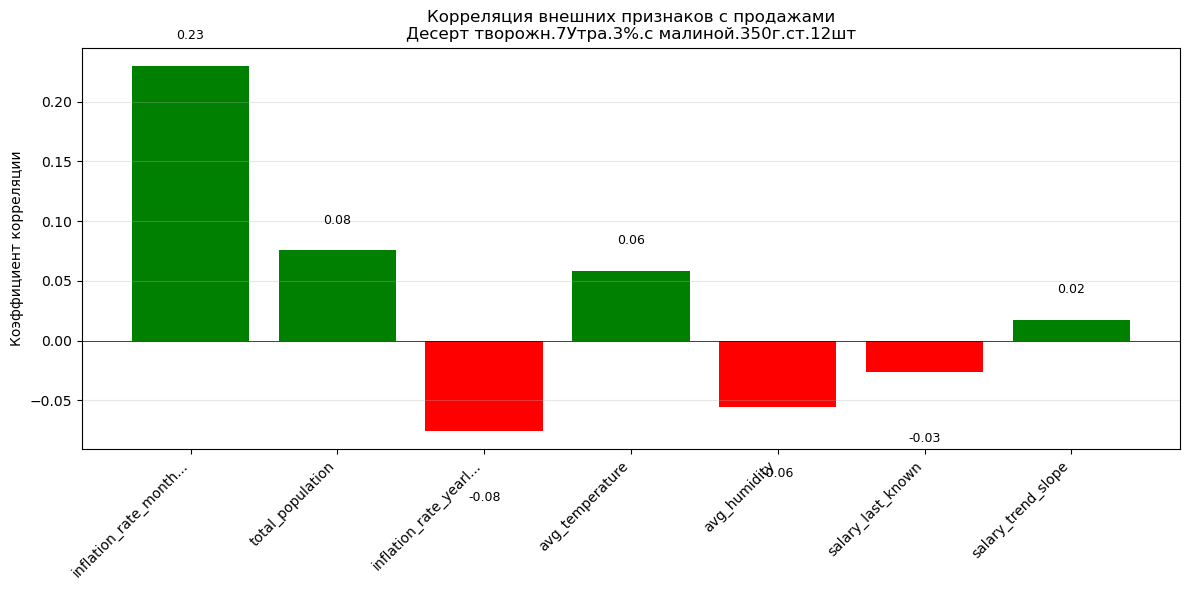


 Анализ для Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт завершен
 Память очищена


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import gc

# ============================================
# ЗАГРУЖАЕМ УЖЕ ОБОГАЩЕННЫЙ ДАТАСЕТ
# ============================================

# Загружаем сохраненный обогащенный датасет
full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')

print(f" Загружен обогащенный датасет:")
print(f"   Записей: {len(full_df_enriched):,}")
print(f"   Колонок: {len(full_df_enriched.columns)}")
print(f"   Уникальных товаров: {full_df_enriched['Номенклатура'].nunique()}")
print(f"   Уникальных городов: {full_df_enriched['city'].nunique()}")

# Получаем список товаров из датасета
products = full_df_enriched['Номенклатура'].unique().tolist()
print(f"\n Товары в датасете ({len(products)} шт.):")
for i, p in enumerate(products[:5], 1):
    print(f"   {i}. {p[:70]}...")
if len(products) > 5:
    print(f"   ... и еще {len(products)-5}")

# ============================================
# ФУНКЦИЯ ДЛЯ АНАЛИЗА ВНЕШНИХ ПРИЗНАКОВ
# ============================================
def analyze_external_features(df, product_name):
    """Анализирует влияние внешних признаков на продажи и показывает один график"""
    
    print("\n" + "="*60)
    print(f" АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ для {product_name[:50]}")
    print("="*60)
    
    # Список внешних признаков для анализа
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly', 
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope'
    ]
    
    # Проверяем, какие признаки есть в данных
    available_features = [f for f in external_features if f in df.columns]
    
    if not available_features:
        print(" Внешние признаки не найдены в датасете")
        return None, {}
    
    print(f"\n Доступные признаки ({len(available_features)}):")
    for f in available_features[:10]:
        print(f"   - {f}")
    
    # Корреляция с продажами
    print("\n КОРРЕЛЯЦИЯ С ПРОДАЖАМИ:")
    correlations = {}
    
    target_col = 'quantity' if 'quantity' in df.columns else 'Количество'
    
    for feature in available_features:
        if df[feature].notna().any() and df[target_col].notna().any():
            temp_df = df[[target_col, feature]].dropna()
            if len(temp_df) > 5:
                try:
                    corr = temp_df[target_col].corr(temp_df[feature])
                    if np.isfinite(corr):
                        correlations[feature] = corr
                        direction = " " if corr > 0 else " "
                        strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                        print(f"   {direction} {feature}: {corr:.3f} ({strength})")
                except:
                    pass
    
    # Топ-3 самых влияющих признаков
    if correlations:
        print("\n ТОП-3 ВЛИЯЮЩИХ ПРИЗНАКА:")
        top_features = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
        for feat, corr in top_features:
            direction = "положительная" if corr > 0 else "отрицательная"
            print(f"   1. {feat}: {corr:.3f} ({direction})")
    
    # ЕДИНСТВЕННЫЙ ГРАФИК - корреляция
    if correlations and len(correlations) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Берем топ-10 признаков
        top_items = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
        features = [f[:20] + '...' if len(f) > 20 else f for f, _ in top_items]
        values = [v for _, v in top_items]
        colors = ['green' if v > 0 else 'red' for v in values]
        
        bars = ax.bar(range(len(features)), values, color=colors)
        ax.set_xticks(range(len(features)))
        ax.set_xticklabels(features, rotation=45, ha='right')
        ax.set_title(f'Корреляция внешних признаков с продажами\n{product_name[:50]}')
        ax.set_ylabel('Коэффициент корреляции')
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Добавляем подписи значений
        for i, v in enumerate(values):
            offset = 0.02 if v > 0 else -0.05
            va = 'bottom' if v > 0 else 'top'
            ax.text(i, v + offset, f'{v:.2f}', ha='center', va=va, fontsize=9)
        
        plt.tight_layout()
        plt.show()
        return fig, correlations
    
    return None, correlations

# ============================================
# ОСНОВНОЙ АНАЛИЗ (ТОЛЬКО ДЛЯ ПЕРВОГО ТОВАРА)
# ============================================

# Берем только первый товар
first_product = products[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ НОМЕНКЛАТУРЫ: {first_product[:70]}")
print('='*70)

# Берем данные для первого товара
df = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # Определяем названия колонок
    date_col = 'date'
    city_col = 'city'
    counterparty_col = 'counterparty'
    amount_col = 'amount'
    quantity_col = 'quantity'
    price_col = 'price'
    
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df):,}")
    print(f"   Период: {df[date_col].min()} - {df[date_col].max()}")
    print(f"   Городов: {df[city_col].nunique()}")
    print(f"   Контрагентов: {df[counterparty_col].nunique()}")
    
    # СТАТИСТИКА ПРОДАЖ
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df[quantity_col].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # ТОП-10 ПРОДАЖ
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_sales = df.nlargest(10, quantity_col)[[date_col, quantity_col, amount_col, city_col]]
    for i, row in top_sales.iterrows():
        print(f"   {row[date_col]}: {row[quantity_col]} шт, {row[amount_col]:.2f} руб, {row[city_col]}")
    
    # СТАТИСТИКА ПО КОНТРАГЕНТАМ
    print(f"\n ТОП-10 КОНТРАГЕНТОВ:")
    kontr_stats = df.groupby(counterparty_col).agg({
        quantity_col: 'sum',
        amount_col: 'sum',
        counterparty_col: 'count'
    }).rename(columns={counterparty_col: 'orders'}).round(2)
    kontr_stats = kontr_stats.sort_values(amount_col, ascending=False).head(10)
    
    for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
        print(f"   {i}. {kontr[:30]:<30} - сумма: {row[amount_col]:>12,.2f} руб, заказов: {row['orders']:>4}")
    
    # СТАТИСТИКА ПО ГОРОДАМ
    print(f"\n ТОП-10 ГОРОДОВ:")
    city_stats = df.groupby(city_col).agg({
        quantity_col: 'sum',
        amount_col: 'sum',
        city_col: 'count'
    }).rename(columns={city_col: 'orders'}).round(2)
    city_stats = city_stats.sort_values(amount_col, ascending=False).head(10)
    
    for i, (city, row) in enumerate(city_stats.iterrows(), 1):
        print(f"   {i}. {city[:20]:<20} - сумма: {row[amount_col]:>12,.2f} руб, заказов: {row['orders']:>4}")
    
    # АНАЛИЗ ПО МЕСЯЦАМ
    print(f"\n ПРОДАЖИ ПО МЕСЯЦАМ:")
    df['month'] = pd.to_datetime(df[date_col]).dt.month
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    monthly = df.groupby('month')[quantity_col].sum()
    
    for month in range(1, 13):
        if month in monthly.index:
            print(f"   {months[month-1]}: {monthly[month]:>8,.0f} шт")
    
    # АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ (С ГРАФИКОМ)
    fig_corr, correlations = analyze_external_features(df, first_product)
    
    # ИТОГ
    print(f"\n{'='*70}")
    print(f" Анализ для {first_product[:50]} завершен")
    print('='*70)
    
    # Очистка памяти
    plt.close('all')
    gc.collect()
    print(" Память очищена")

In [2]:

#функция версионирвоаиня, добавим после наполнениявсех признаков
import json
import pickle
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from minio import Minio
from io import BytesIO
import re

def save_datasets_to_minio(
    train_df, 
    test_df=None, 
    product_name=None,
    bucket_name="ml-datasets",
    version=None,
    split_info=None
):
    """
    Сохраняет train/test датасеты в Minio с правильной структурой
    
    Parameters:
    train_df, test_df: DataFrame
    product_name: название продукта
    bucket_name: бакет в Minio
    version: версия датасета (если None, создается автоматически)
    split_info: дополнительная информация о разделении
    """
    
    # Подключение к Minio
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    # Создаем бакет если нет
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    # Очищаем имя продукта для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Формируем версию
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Базовый путь
    base_path = f"datasets/{clean_name}/train_test_split"
    
    saved_files = []
    
    # 1. Сохраняем train как parquet (эффективнее csv)
    train_buffer = BytesIO()
    train_df.to_parquet(train_buffer, index=False)
    train_buffer.seek(0)
    
    train_path = f"{base_path}/train_{version}.parquet"
    client.put_object(
        bucket_name,
        train_path,
        data=train_buffer,
        length=train_buffer.getbuffer().nbytes,
        content_type='application/parquet'
    )
    saved_files.append(f"{bucket_name}/{train_path}")
    print(f" Train сохранен: {train_path}")
    
    # 2. Сохраняем test
    if test_df is not None:
        test_buffer = BytesIO()
        test_df.to_parquet(test_buffer, index=False)
        test_buffer.seek(0)
        
        test_path = f"{base_path}/test_{version}.parquet"
        client.put_object(
            bucket_name,
            test_path,
            data=test_buffer,
            length=test_buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
        saved_files.append(f"{bucket_name}/{test_path}")
        print(f" Test сохранен: {test_path}")
    
    # 3. Сохраняем метаданные о разделении
    if split_info is None:
        split_info = {
            'product': product_name,
            'version': version,
            'train_size': len(train_df),
            'test_size': len(test_df),
            'train_period': {
                'start': str(train_df['Дата'].min()),
                'end': str(train_df['Дата'].max())
            },
            'test_period': {
                'start': str(test_df['Дата'].min()),
                'end': str(test_df['Дата'].max())
            },
            'features': list(train_df.columns),
            'created_at': datetime.now().isoformat()
        }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(split_info, indent=2, ensure_ascii=False).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/split_info_{version}.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" Метаданные сохранены: {meta_path}")
    
    return {
        'train_path': train_path,
        'test_path': test_path,
        'meta_path': meta_path,
        'version': version,
        'bucket': bucket_name,
        'files': saved_files
    }


def load_datasets_from_minio(
    bucket_name="ml-datasets",
    product_name=None,
    version=None,
    latest=True
):
    """
    Загружает датасеты из Minio
    
    Если latest=True, берет последнюю версию
    Иначе нужно указать version
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    base_path = f"datasets/{clean_name}/train_test_split"
    
    if latest:
        # Находим последнюю версию
        objects = list(client.list_objects(bucket_name, prefix=base_path, recursive=True))
        versions = set()
        for obj in objects:
            if 'train_' in obj.object_name:
                ver = obj.object_name.split('train_')[-1].split('.parquet')[0]
                versions.add(ver)
        
        if not versions:
            raise ValueError(f"Нет датасетов для продукта {product_name}")
        
        version = sorted(versions)[-1]
        print(f"Загружаем последнюю версию: {version}")
    
    # Загружаем train
    train_path = f"{base_path}/train_{version}.parquet"
    train_response = client.get_object(bucket_name, train_path)
    train_df = pd.read_parquet(BytesIO(train_response.read()))
    
    # Загружаем test
    test_path = f"{base_path}/test_{version}.parquet"
    test_response = client.get_object(bucket_name, test_path)
    test_df = pd.read_parquet(BytesIO(test_response.read()))
    
    # Загружаем метаданные
    meta_path = f"{base_path}/split_info_{version}.json"
    try:
        meta_response = client.get_object(bucket_name, meta_path)
        meta_info = json.loads(meta_response.read().decode())
    except:
        meta_info = None
    
    print(f" Загружено: train={len(train_df)}, test={len(test_df)}")
    return train_df, test_df, meta_info


def save_features_to_minio(
    X_train, X_test, y_train, y_test,
    feature_names,
    product_name,
    version=None
):
    """
    Сохраняет признаки и целевые переменные для модели
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    bucket_name = "ml-datasets"
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    base_path = f"features/{clean_name}/{version}"
    
    # Сохраняем признаки
    features_dict = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': feature_names
    }
    
    for name, data in features_dict.items():
        buffer = BytesIO()
        
        if isinstance(data, pd.DataFrame) or isinstance(data, pd.Series):
            data.to_parquet(buffer)
        elif isinstance(data, np.ndarray):
            pd.DataFrame(data).to_parquet(buffer)
        else:
            # для списков и простых типов
            buffer.write(json.dumps(data).encode())
            buffer.seek(0)
            client.put_object(
                bucket_name,
                f"{base_path}/{name}.json",
                data=buffer,
                length=buffer.getbuffer().nbytes,
                content_type='application/json'
            )
            continue
        
        buffer.seek(0)
        client.put_object(
            bucket_name,
            f"{base_path}/{name}.parquet",
            data=buffer,
            length=buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
    
    print(f" Признаки сохранены: {base_path}")

In [1]:
# Ячейка 1: Импорты
import pandas as pd
import numpy as np
from clickhouse_driver import Client

# Ячейка 2: Загрузка сохраненного датасета
import os
if os.path.exists('/home/jovyan/work/data/processed/full_sales_data_final.parquet'):
    full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')
    print(f"Загружен датасет: {full_df_enriched.shape}")
else:
    print("Файл не найден, нужно выполнить ячейки с загрузкой из ClickHouse")

Загружен датасет: (108635, 62)


In [5]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

# Получаем список уникальных товаров из обогащенного датасета
products_list = full_df_enriched['Номенклатура'].unique().tolist()
print(f" Всего товаров для анализа: {len(products_list)}")

# Берем только первый товар
first_product = products_list[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ НОМЕНКЛАТУРЫ: {first_product[:70]}")
print('='*70)

# Фильтруем данные для первого товара
df = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # Определяем названия колонок
    date_col = 'date'
    target_col = 'quantity' if 'quantity' in df.columns else 'Количество'
    amount_col = 'amount' if 'amount' in df.columns else 'Сумма'
    price_col = 'price' if 'price' in df.columns else 'Цена'
    city_col = 'city'
    counterparty_col = 'counterparty'
    
    # Базовая информация
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df):,}")
    print(f"   Период: {df[date_col].min()} - {df[date_col].max()}")
    print(f"   Городов: {df[city_col].nunique()}")
    print(f"   Контрагентов: {df[counterparty_col].nunique()}")
    
    # Статистика продаж
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df[target_col].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # Топ-10 продаж
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_cols = [date_col, target_col, price_col, amount_col, city_col]
    if all(col in df.columns for col in top_cols):
        top_sales = df.nlargest(10, target_col)[top_cols]
        for i, row in top_sales.iterrows():
            print(f"   {row[date_col]}: {row[target_col]} шт, {row[amount_col]:.2f} руб, {row[city_col]}")
    
    # Статистика по контрагентам
    print(f"\n ТОП-10 КОНТРАГЕНТОВ:")
    kontr_stats = df.groupby(counterparty_col).agg({
        target_col: ['sum', 'mean', 'count'],
        amount_col: 'sum'
    }).round(2)
    kontr_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
    kontr_stats = kontr_stats.sort_values('сумма_руб', ascending=False).head(10)
    
    for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
        print(f"   {i}. {kontr[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    # Статистика по городам
    print(f"\n ТОП-10 ГОРОДОВ:")
    city_stats = df.groupby(city_col).agg({
        target_col: ['sum', 'mean', 'count'],
        amount_col: 'sum'
    }).round(2)
    city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
    city_stats = city_stats.sort_values('сумма_руб', ascending=False).head(10)
    
    for i, (city, row) in enumerate(city_stats.iterrows(), 1):
        print(f"   {i}. {city[:20]:<20} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    # Анализ временных признаков
    print(f"\n АНАЛИЗ ПО ВРЕМЕНИ:")
    
    # Создаем временные признаки
    df['год'] = pd.to_datetime(df[date_col]).dt.year
    df['месяц'] = pd.to_datetime(df[date_col]).dt.month
    df['день_недели'] = pd.to_datetime(df[date_col]).dt.dayofweek
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    
    # По месяцам
    monthly = df.groupby('месяц')[target_col].sum()
    print(f"\n   Продажи по месяцам:")
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    for month in range(1, 13):
        if month in monthly.index:
            print(f"     {months[month-1]}: {monthly[month]:>8,.0f} шт")
    
    # По дням недели
    weekly = df.groupby('день_недели')[target_col].sum()
    print(f"\n   Продажи по дням недели:")
    for day in range(7):
        if day in weekly.index:
            print(f"     {days[day]}: {weekly[day]:>8,.0f} шт")
    
    # Анализ внешних признаков (корреляции)
    print(f"\n АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ:")
    
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly', 
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope'
    ]
    
    available = [f for f in external_features if f in df.columns]
    
    if available:
        correlations = []
        for feature in available:
            if df[feature].notna().any() and df[target_col].notna().any():
                temp_df = df[[target_col, feature]].dropna()
                if len(temp_df) > 5:
                    corr = temp_df[target_col].corr(temp_df[feature])
                    if np.isfinite(corr):
                        correlations.append((feature, corr))
        
        if correlations:
            correlations.sort(key=lambda x: abs(x[1]), reverse=True)
            print(f"\n   Топ-5 признаков по влиянию на продажи:")
            for feat, corr in correlations[:5]:
                direction = " " if corr > 0 else " "
                strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                print(f"     {direction} {feat}: {corr:.3f} ({strength})")
    
    # Простая статистика по ценам
    print(f"\n АНАЛИЗ ЦЕН:")
    price_stats = df[price_col].describe()
    print(f"   Средняя цена: {price_stats['mean']:.2f} руб")
    print(f"   Мин цена: {price_stats['min']:.2f} руб")
    print(f"   Макс цена: {price_stats['max']:.2f} руб")
    print(f"   Медианная цена: {price_stats['50%']:.2f} руб")
    
    print(f"\n Анализ завершен")

# Для остальных товаров можно вывести только базовую статистику
print(f"\n{'='*70}")
print(f" КРАТКАЯ СТАТИСТИКА ПО ВСЕМ ТОВАРАМ")
print('='*70)

for i, product in enumerate(products_list[:5], 1):  # первые 5 товаров
    df_temp = full_df_enriched[full_df_enriched['Номенклатура'] == product]
    print(f"\n{i}. {product[:50]}...")
    print(f"   Записей: {len(df_temp):,}")
    print(f"   Городов: {df_temp['city'].nunique()}")
    print(f"   Сумма: {df_temp['amount'].sum():,.2f} руб")

if len(products_list) > 5:
    print(f"\n... и еще {len(products_list) - 5} товаров")

 Всего товаров для анализа: 10

 АНАЛИЗ НОМЕНКЛАТУРЫ: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 8,140
   Период: 2025-03-16 16:58:00 - 2026-03-15 16:08:31
   Городов: 45
   Контрагентов: 146

 СТАТИСТИКА ПРОДАЖ:
   count: 8140.00
   mean: 227.79
   std: 403.82
   min: 1.00
   25%: 6.00
   50%: 12.00
   75%: 360.00
   max: 4848.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-05-25 17:38:02: 3468.0 шт, 184150.80 руб, Москва
   2025-05-25 17:38:02: 3468.0 шт, 184150.80 руб, Москва
   2025-05-25 17:38:02: 3468.0 шт, 184150.80 руб, Москва
   2025-05-22 12:37:04: 3060.0 шт, 182070.00 руб, Петрозаводск

 ТО

In [6]:
#статистику временных продаж переместил в блок выше

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime
import re
import gc

# ============================================
# ЗАГРУЖАЕМ ОБОГАЩЕННЫЙ ДАТАСЕТ
# ============================================

full_df_enriched = pd.read_parquet('/home/jovyan/work/data/processed/full_sales_data_final.parquet')

print(f" Загружен обогащенный датасет:")
print(f"   Записей: {len(full_df_enriched):,}")
print(f"   Колонок: {len(full_df_enriched.columns)}")
print(f"   Уникальных товаров: {full_df_enriched['Номенклатура'].nunique()}")
print(f"   Уникальных городов: {full_df_enriched['city'].nunique()}")

# Получаем список товаров
products_list = full_df_enriched['Номенклатура'].unique().tolist()
print(f"\n Товары в датасете ({len(products_list)} шт.)")

# ============================================
# ФУНКЦИЯ СОЗДАНИЯ ВРЕМЕННЫХ ПРИЗНАКОВ
# ============================================

def create_time_features(df_product):
    """
    Добавляет временные признаки для анализа
    """
    df = df_product.copy()
    
    # Убеждаемся, что date в правильном формате
    df['date'] = pd.to_datetime(df['date'])
    
    # Базовые временные признаки
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['week'] = df['date'].dt.isocalendar().week
    
    # Циклические признаки
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    # Бинарные флаги
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    return df

# ============================================
# АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ
# ============================================

def analyze_lag_features(df_product):
    """
    Анализирует лаговые признаки без визуализации
    """
    # Создаем лаговые признаки, если их нет
    if 'quantity_lag_1' not in df_product.columns:
        df_product = df_product.sort_values('date')
        for lag in [1, 3, 6, 12, 24]:
            df_product[f'quantity_lag_{lag}'] = df_product['quantity'].shift(lag)
        for window in [3, 6, 12, 24]:
            df_product[f'quantity_rolling_mean_{window}'] = (
                df_product['quantity'].rolling(window=window, min_periods=1).mean()
            )
    
    # Лаговые признаки для анализа
    lag_features = ['quantity_lag_1', 'quantity_lag_3', 'quantity_lag_6', 
                    'quantity_lag_12', 'quantity_lag_24', 'quantity_lag_168']
    
    existing_lags = [f for f in lag_features if f in df_product.columns]
    
    if existing_lags:
        print("\n АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ:")
        
        # Корреляция с текущими продажами
        correlations = {}
        for lag in existing_lags:
            temp_df = df_product[['quantity', lag]].dropna()
            if len(temp_df) > 10:
                corr = temp_df['quantity'].corr(temp_df[lag])
                if np.isfinite(corr):
                    correlations[lag] = corr
        
        if correlations:
            print("\n   Корреляция текущих продаж с лагами:")
            for lag, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
                print(f"     {lag}: {corr:.3f}")
        
        # Пропуски в лагах
        print("\n   Пропуски в лаговых признаках:")
        for lag in existing_lags:
            missing = df_product[lag].isna().sum()
            pct = (missing / len(df_product)) * 100
            print(f"     {lag}: {missing} пропусков ({pct:.1f}%)")
    
    return df_product

# ============================================
# СТАТИСТИКА ПО ОРГАНИЗАЦИЯМ И ГОРОДАМ
# ============================================

def analyze_categorical_features(df_product):
    """
    Анализирует категориальные признаки
    """
    print("\n СТАТИСТИКА ПО ОРГАНИЗАЦИЯМ:")
    
    # Статистика по организациям
    if 'organization' in df_product.columns:
        org_stats = df_product.groupby('organization').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        org_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        org_stats = org_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (org, row) in enumerate(org_stats.iterrows(), 1):
            print(f"   {i}. {str(org)[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    print("\n СТАТИСТИКА ПО ГОРОДАМ:")
    
    # Статистика по городам
    if 'city' in df_product.columns:
        city_stats = df_product.groupby('city').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (city, row) in enumerate(city_stats.iterrows(), 1):
            print(f"   {i}. {city[:20]:<20} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")
    
    print("\n СТАТИСТИКА ПО КОНТРАГЕНТАМ:")
    
    # Статистика по контрагентам
    if 'counterparty' in df_product.columns:
        kontr_stats = df_product.groupby('counterparty').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': ['sum', 'mean']
        }).round(2)
        kontr_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб', 'средний_чек']
        kontr_stats = kontr_stats.sort_values('сумма_руб', ascending=False).head(10)
        
        for i, (kontr, row) in enumerate(kontr_stats.iterrows(), 1):
            print(f"   {i}. {str(kontr)[:30]:<30} - сумма: {row['сумма_руб']:>12,.2f} руб, заказов: {row['кол_заказов']:>4}")

# ============================================
# АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ
# ============================================

def analyze_external_features(df_product):
    """
    Анализирует внешние признаки без визуализации
    """
    external_features = [
        'avg_temperature', 'avg_humidity', 'inflation_rate_monthly',
        'inflation_rate_yearly', 'key_rate', 'usd_rate', 'eur_rate',
        'total_population', 'salary_last_known', 'salary_trend_slope',
        'salary_avg_annual_growth', 'salary_growth_3y'
    ]
    
    available = [f for f in external_features if f in df_product.columns]
    
    if available:
        print("\n АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ:")
        
        # Корреляция с продажами
        correlations = {}
        for feat in available:
            temp_df = df_product[['quantity', feat]].dropna()
            if len(temp_df) > 10:
                corr = temp_df['quantity'].corr(temp_df[feat])
                if np.isfinite(corr):
                    correlations[feat] = corr
        
        if correlations:
            print("\n   Корреляция внешних признаков с продажами:")
            for feat, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:10]:
                direction = " " if corr > 0 else " "
                strength = "сильная" if abs(corr) > 0.5 else "средняя" if abs(corr) > 0.3 else "слабая"
                print(f"     {direction} {feat}: {corr:.3f} ({strength})")
        
        # Статистика внешних признаков
        print("\n   Статистика внешних признаков:")
        for feat in available[:5]:
            print(f"     {feat}: среднее={df_product[feat].mean():.2f}, "
                  f"мин={df_product[feat].min():.2f}, макс={df_product[feat].max():.2f}")

# ============================================
# ОСНОВНОЙ АНАЛИЗ (ТОЛЬКО ПЕРВЫЙ ТОВАР)
# ============================================

first_product = products_list[0]
print(f"\n{'='*70}")
print(f" АНАЛИЗ ТОВАРА: {first_product[:70]}")
print('='*70)

# Получаем данные для первого товара
df_product = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()

if df_product.empty:
    print(f" Нет данных для {first_product[:50]}")
else:
    # 1. СОЗДАЕМ ВРЕМЕННЫЕ ПРИЗНАКИ
    df_product = create_time_features(df_product)
    
    # 2. БАЗОВАЯ ИНФОРМАЦИЯ
    print(f"\n БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"   Записей: {len(df_product):,}")
    print(f"   Период: {df_product['date'].min()} - {df_product['date'].max()}")
    print(f"   Городов: {df_product['city'].nunique()}")
    print(f"   Организаций: {df_product['organization'].nunique()}")
    print(f"   Контрагентов: {df_product['counterparty'].nunique()}")
    
    # 3. СТАТИСТИКА ПРОДАЖ
    print(f"\n СТАТИСТИКА ПРОДАЖ:")
    stats = df_product['quantity'].describe()
    for stat_name, value in stats.items():
        print(f"   {stat_name}: {value:.2f}")
    
    # 4. ТОП-10 ПРОДАЖ
    print(f"\n ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:")
    top_sales = df_product.nlargest(10, 'quantity')[['date', 'quantity', 'amount', 'city']]
    for i, row in top_sales.iterrows():
        print(f"   {row['date']}: {row['quantity']} шт, {row['amount']:.2f} руб, {row['city']}")
    
    # 5. АНАЛИЗ ПО ВРЕМЕНИ
    print(f"\n ПРОДАЖИ ПО ЧАСАМ:")
    hourly = df_product.groupby('hour')['quantity'].agg(['sum', 'mean'])
    peak_hour = hourly['sum'].idxmax()
    print(f"   Пиковый час: {peak_hour}:00 (продаж: {hourly.loc[peak_hour, 'sum']:.0f} шт)")
    
    print(f"\n ПРОДАЖИ ПО ДНЯМ НЕДЕЛИ:")
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    weekly = df_product.groupby('dayofweek')['quantity'].sum()
    for day in range(7):
        if day in weekly.index:
            print(f"   {days[day]}: {weekly[day]:.0f} шт")
    
    print(f"\n ПРОДАЖИ ПО МЕСЯЦАМ:")
    months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    monthly = df_product.groupby('month')['quantity'].sum()
    for month in range(1, 13):
        if month in monthly.index:
            print(f"   {months[month-1]}: {monthly[month]:.0f} шт")
    
    # 6. АНАЛИЗ ЛАГОВЫХ ПРИЗНАКОВ
    df_product = analyze_lag_features(df_product)
    
    # 7. АНАЛИЗ ПО ОРГАНИЗАЦИЯМ И ГОРОДАМ
    analyze_categorical_features(df_product)
    
    # 8. АНАЛИЗ ВНЕШНИХ ПРИЗНАКОВ
    analyze_external_features(df_product)
    
    # 9. ИТОГОВАЯ СТАТИСТИКА
    print(f"\n ИТОГОВАЯ СТАТИСТИКА:")
    print(f"   Всего записей: {len(df_product)}")
    print(f"   Всего признаков: {len(df_product.columns)}")
    print(f"   Числовых признаков: {len(df_product.select_dtypes(include=[np.number]).columns)}")
    
    # Список всех признаков
    print(f"\n СПИСОК ВСЕХ ПРИЗНАКОВ ({len(df_product.columns)}):")
    for i, col in enumerate(sorted(df_product.columns), 1):
        dtype = df_product[col].dtype
        non_null = df_product[col].notna().sum()
        print(f"   {i:3d}. {col:35} ({dtype}) - заполнено: {non_null}/{len(df_product)}")
    
    # 10. СОХРАНЕНИЕ В ФАЙЛ (опционально)
    output_path = '/home/jovyan/work/data/processed/first_product_with_features.parquet'
    df_product.to_parquet(output_path)
    print(f"\n Датасет с признаками сохранен: {output_path}")
    
    print(f"\n{'='*70}")
    print(f" Анализ завершен")
    print('='*70)

# Очистка памяти
gc.collect()
print("\n Память очищена")

 Загружен обогащенный датасет:
   Записей: 108,635
   Колонок: 62
   Уникальных товаров: 10
   Уникальных городов: 89

 Товары в датасете (10 шт.)

 АНАЛИЗ ТОВАРА: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт

 БАЗОВАЯ ИНФОРМАЦИЯ:
   Записей: 8,140
   Период: 2025-03-16 16:58:00 - 2026-03-15 16:08:31
   Городов: 45
   Организаций: 3
   Контрагентов: 146

 СТАТИСТИКА ПРОДАЖ:
   count: 8140.00
   mean: 227.79
   std: 403.82
   min: 1.00
   25%: 6.00
   50%: 12.00
   75%: 360.00
   max: 4848.00

 ТОП-10 САМЫХ БОЛЬШИХ ПРОДАЖ:
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-09-28 00:50:40: 4848.0 шт, 263004.00 руб, Самара
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-03-27 11:43:29: 3600.0 шт, 214200.00 руб, Петрозаводск
   2025-05-25 17:38:02: 3468.0 шт, 184150.80 руб, Москва
   2025-05-25 17:38:02: 3468.0 шт, 184150.80 руб, Мос

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Агрегируем по дням
daily_sales = df_product.groupby(df_product['date'].dt.date)['quantity'].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)

print(f"\n{'='*60}")
print(" АНАЛИЗ СЕЗОННОСТИ (ЕЖЕДНЕВНОЙ)")
print('='*60)
print(f" Ежедневные продажи: {len(daily_sales)} дней")

if len(daily_sales) >= 14:
    decomposition = seasonal_decompose(daily_sales, model='additive', period=7)
    
    print("\n СТАТИСТИКА КОМПОНЕНТ:")
    print(f"   Тренд:")
    print(f"     Минимум: {decomposition.trend.min():.0f}")
    print(f"     Максимум: {decomposition.trend.max():.0f}")
    print(f"     Среднее: {decomposition.trend.mean():.0f}")
    
    print(f"\n   Сезонная компонента (по дням недели):")
    seasonal_values = decomposition.seasonal[:7].values
    days_of_week = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
    
    for i, val in enumerate(seasonal_values):
        day_name = days_of_week[i]
        direction = " выше среднего" if val > 0 else " ниже среднего"
        print(f"     {day_name}: {val:+.1f} ({direction})")
    
    print(f"\n   Остатки (случайная компонента):")
    print(f"     Минимум: {decomposition.resid.min():.0f}")
    print(f"     Максимум: {decomposition.resid.max():.0f}")
    print(f"     Стандартное отклонение: {decomposition.resid.std():.1f}")
    
    # Анализ силы сезонности
    seasonal_strength = abs(decomposition.seasonal).mean() / daily_sales.mean() * 100
    print(f"\n СИЛА СЕЗОННОСТИ:")
    print(f"   Среднее отклонение из-за сезонности: {abs(decomposition.seasonal).mean():.1f} шт ({seasonal_strength:.1f}% от средних продаж)")
    
    if seasonal_strength > 20:
        print("   Вывод: Сезонность сильная, учитывайте день недели в прогнозах")
    elif seasonal_strength > 10:
        print("   Вывод: Сезонность средняя, день недели влияет на продажи")
    else:
        print("   Вывод: Сезонность слабая, день недели почти не влияет")
    
    # Топ-3 дня
    print(f"\n ДНИ С МАКСИМАЛЬНЫМИ ОТКЛОНЕНИЯМИ:")
    seasonal_with_days = list(zip(days_of_week, seasonal_values))
    seasonal_sorted = sorted(seasonal_with_days, key=lambda x: x[1], reverse=True)
    
    print("\n    Дни с продажами ВЫШЕ среднего:")
    for day_name, val in seasonal_sorted[:3]:
        if val > 0:
            print(f"      {day_name}: +{val:.1f} шт")
    
    print("\n    Дни с продажами НИЖЕ среднего:")
    for day_name, val in seasonal_sorted[-3:]:
        if val < 0:
            print(f"      {day_name}: {val:.1f} шт")
    
    # ИСПРАВЛЕННЫЙ ПРОГНОЗ
    print(f"\n ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ:")
    
    # Берем последнее значение тренда (не nan)
    last_valid_trend = decomposition.trend.dropna().iloc[-1]
    
    # Берем сезонность для следующей недели (циклически)
    next_week_seasonal = decomposition.seasonal[-7:].values
    
    for i, seasonal in enumerate(next_week_seasonal):
        forecast = last_valid_trend + seasonal
        # Округляем до целых
        forecast_rounded = int(round(forecast))
        print(f"   {days_of_week[i]}: ~{forecast_rounded} шт")
    
    # Дополнительная статистика
    print(f"\n ДОПОЛНИТЕЛЬНО:")
    print(f"   Средние продажи в пятницу: {daily_sales[daily_sales.index.dayofweek == 4].mean():.0f} шт")
    print(f"   Средние продажи в среду: {daily_sales[daily_sales.index.dayofweek == 2].mean():.0f} шт")
    print(f"   Разрыв между пятницей и средой: {daily_sales[daily_sales.index.dayofweek == 4].mean() - daily_sales[daily_sales.index.dayofweek == 2].mean():.0f} шт")
    
else:
    print("\n Недостаточно данных для декомпозиции (нужно минимум 14 дней)")


 АНАЛИЗ СЕЗОННОСТИ (ЕЖЕДНЕВНОЙ)
 Ежедневные продажи: 351 дней

 СТАТИСТИКА КОМПОНЕНТ:
   Тренд:
     Минимум: 2953
     Максимум: 8964
     Среднее: 5297

   Сезонная компонента (по дням недели):
     Понедельник: +357.7 ( выше среднего)
     Вторник: -286.9 ( ниже среднего)
     Среда: -1168.3 ( ниже среднего)
     Четверг: -1144.3 ( ниже среднего)
     Пятница: +1412.9 ( выше среднего)
     Суббота: +423.9 ( выше среднего)
     Воскресенье: +404.8 ( выше среднего)

   Остатки (случайная компонента):
     Минимум: -6056
     Максимум: 12737
     Стандартное отклонение: 3185.8

 СИЛА СЕЗОННОСТИ:
   Среднее отклонение из-за сезонности: 741.6 шт (14.0% от средних продаж)
   Вывод: Сезонность средняя, день недели влияет на продажи

 ДНИ С МАКСИМАЛЬНЫМИ ОТКЛОНЕНИЯМИ:

    Дни с продажами ВЫШЕ среднего:
      Пятница: +1412.9 шт
      Суббота: +423.9 шт
      Воскресенье: +404.8 шт

    Дни с продажами НИЖЕ среднего:
      Вторник: -286.9 шт
      Четверг: -1144.3 шт
      Среда: -1168.3 ш

In [11]:
print(f"\n{'='*60}")
print(f" ПРОВЕРКА И ДОБАВЛЕНИЕ ПРИЗНАКОВ для {first_product[:50]}")
print('='*60)

print(f"   Всего колонок: {len(df_product.columns)}")

# 1. Удаляем дубликаты колонок (на всякий случай)
df_product = df_product.loc[:, ~df_product.columns.duplicated()]
print(f"   После удаления дубликатов: {len(df_product.columns)}")

# 2. Проверяем, какие признаки уже есть (английские названия)
existing_features = {
    'org_mean_sales': 'org_mean_sales' in df_product.columns,
    'org_std_sales': 'org_std_sales' in df_product.columns,
    'counterparty_mean_sales': 'counterparty_mean_sales' in df_product.columns,
    'counterparty_std_sales': 'counterparty_std_sales' in df_product.columns,
    'type_wholesale': 'type_wholesale' in df_product.columns,
    'type_retail': 'type_retail' in df_product.columns,
    'type_small_retail': 'type_small_retail' in df_product.columns
}

print("\n Проверка наличия признаков:")
for feat, exists in existing_features.items():
    status = " есть" if exists else " нет"
    print(f"   {feat:25}: {status}")

# 3. Добавляем недостающие признаки по организациям
if not existing_features['org_mean_sales'] and 'organization' in df_product.columns:
    print("\n Добавляем признаки по организациям...")
    
    # Рассчитываем статистику по каждой организации
    org_stats = df_product.groupby('organization')['quantity'].agg(['mean', 'std']).fillna(0)
    org_stats_dict = org_stats.to_dict('index')
    
    # Добавляем признаки в датасет
    df_product['org_mean_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
    df_product['org_std_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    
    print(f"     Добавлены org_mean_sales, org_std_sales")
    print(f"    Среднее по организациям: {df_product['org_mean_sales'].mean():.1f}")
    print(f"    Стандартное отклонение: {df_product['org_std_sales'].mean():.1f}")

# 4. Добавляем недостающие признаки по контрагентам
if not existing_features['counterparty_mean_sales'] and 'counterparty' in df_product.columns:
    print("\n Добавляем признаки по контрагентам...")
    
    # Рассчитываем статистику по каждому контрагенту
    kontr_stats = df_product.groupby('counterparty')['quantity'].agg(['mean', 'std']).fillna(0)
    kontr_stats_dict = kontr_stats.to_dict('index')
    
    # Добавляем признаки в датасет
    df_product['counterparty_mean_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
    df_product['counterparty_std_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    
    print(f"     Добавлены counterparty_mean_sales, counterparty_std_sales")
    print(f"    Среднее по контрагентам: {df_product['counterparty_mean_sales'].mean():.1f}")
    print(f"    Стандартное отклонение: {df_product['counterparty_std_sales'].mean():.1f}")

# 5. Добавляем типы продаж (если нет)
if not any([existing_features['type_wholesale'], 
            existing_features['type_retail'], 
            existing_features['type_small_retail']]):
    
    print("\n Добавляем типы продаж...")
    
    # Используем квантили для определения границ
    q33 = df_product['quantity'].quantile(0.33)
    q67 = df_product['quantity'].quantile(0.67)
    
    print(f"   Границы типов продаж:")
    print(f"     Мелкие: < {q33:.1f}")
    print(f"     Средние: {q33:.1f} - {q67:.1f}")
    print(f"     Крупные: > {q67:.1f}")
    
    # Создаем категории
    df_product['sales_type'] = df_product['quantity'].apply(
        lambda x: 'wholesale' if x > q67 else ('medium' if x > q33 else 'small')
    )
    
    # Создаем dummy-переменные
    type_dummies = pd.get_dummies(df_product['sales_type'], prefix='type')
    df_product = pd.concat([df_product, type_dummies], axis=1)
    
    print(f"     Добавлены типы продаж:")
    for col in type_dummies.columns:
        count = type_dummies[col].sum()
        pct = (count / len(df_product)) * 100
        print(f"      {col}: {count} записей ({pct:.1f}%)")

# 6. Добавляем лаговые признаки, если их нет
lag_features = ['quantity_lag_1', 'quantity_lag_24', 'quantity_rolling_mean_24']
missing_lags = [f for f in lag_features if f not in df_product.columns]

if missing_lags:
    print("\n Добавляем лаговые признаки...")
    df_product = df_product.sort_values('date')
    
    if 'quantity_lag_1' not in df_product.columns:
        df_product['quantity_lag_1'] = df_product['quantity'].shift(1)
        print(f"     Добавлен quantity_lag_1")
    
    if 'quantity_lag_24' not in df_product.columns:
        df_product['quantity_lag_24'] = df_product['quantity'].shift(24)
        print(f"     Добавлен quantity_lag_24")
    
    if 'quantity_rolling_mean_24' not in df_product.columns:
        df_product['quantity_rolling_mean_24'] = df_product['quantity'].rolling(window=24, min_periods=1).mean()
        print(f"     Добавлен quantity_rolling_mean_24")

# 7. Проверка пропусков в новых признаках
print(f"\n ПРОВЕРКА ПРОПУСКОВ В НОВЫХ ПРИЗНАКАХ:")
new_features = ['org_mean_sales', 'org_std_sales', 
                'counterparty_mean_sales', 'counterparty_std_sales',
                'type_wholesale', 'type_medium', 'type_small',
                'quantity_lag_1', 'quantity_lag_24', 'quantity_rolling_mean_24']

for feat in new_features:
    if feat in df_product.columns:
        filled = df_product[feat].notna().sum()
        pct = (filled / len(df_product)) * 100
        print(f"   {feat:25}: заполнено {filled:6}/{len(df_product)} ({pct:5.1f}%)")

# 8. ИТОГ
print(f"\n{'='*60}")
print(" ИТОГОВАЯ ИНФОРМАЦИЯ")
print('='*60)
print(f"   Всего колонок: {len(df_product.columns)}")
print(f"   Размер датасета: {df_product.shape}")
print(f"   Числовых признаков: {len(df_product.select_dtypes(include=[np.number]).columns)}")

# Сохраняем обновленный датасет
output_path = '/home/jovyan/work/data/processed/first_product_with_features.parquet'
df_product.to_parquet(output_path)
print(f"\n Обновленный датасет сохранен: {output_path}")


 ПРОВЕРКА И ДОБАВЛЕНИЕ ПРИЗНАКОВ для Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт
   Всего колонок: 76
   После удаления дубликатов: 76

 Проверка наличия признаков:
   org_mean_sales           :  нет
   org_std_sales            :  нет
   counterparty_mean_sales  :  нет
   counterparty_std_sales   :  нет
   type_wholesale           :  нет
   type_retail              :  нет
   type_small_retail        :  нет

 Добавляем признаки по организациям...
     Добавлены org_mean_sales, org_std_sales
    Среднее по организациям: 227.8
    Стандартное отклонение: 395.5

 Добавляем признаки по контрагентам...
     Добавлены counterparty_mean_sales, counterparty_std_sales
    Среднее по контрагентам: 227.8
    Стандартное отклонение: 105.5

 Добавляем типы продаж...
   Границы типов продаж:
     Мелкие: < 6.0
     Средние: 6.0 - 120.0
     Крупные: > 120.0
     Добавлены типы продаж:
      type_medium: 2378 записей (29.2%)
      type_small: 3083 записей (37.9%)
      type_wholesale: 2679 записей

In [15]:
#функция версионирования датасетов для Minio
import json
import pickle
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from minio import Minio
from io import BytesIO
import re

def save_datasets_to_minio(
    train_df, 
    test_df=None, 
    product_name=None,
    bucket_name="ml-datasets",
    version=None,
    split_info=None
):
    """
    Сохраняет train/test датасеты в Minio с версионированием
    """
    # Проверяем тип данных
    if not isinstance(train_df, pd.DataFrame):
        print(f" Ошибка: train_df должен быть DataFrame, а это {type(train_df)}")
        return None
    
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ ДАТАСЕТА В MINIO")
    print('='*60)
    print(f"   Продукт: {product_name[:50]}")
    print(f"   Train: {train_df.shape}, Test: {test_df.shape if test_df is not None else 'None'}")
    
    # Подключение к Minio
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
        # Проверка подключения
        client.list_buckets()
        print(" Подключение к Minio успешно")
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        print("   Проверьте настройки подключения")
        return None
    
    # Создаем бакет если нет
    if not client.bucket_exists(bucket_name):
        client.make_bucket(bucket_name)
        print(f" Создан бакет: {bucket_name}")
    
    # Очищаем имя продукта для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Формируем версию
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Базовый путь
    base_path = f"datasets/{clean_name}/train_test_split"
    
    saved_files = []
    
    # Определяем колонку даты (date или Дата)
    date_col = 'date' if 'date' in train_df.columns else 'Дата'
    
    # 1. Сохраняем train
    try:
        train_buffer = BytesIO()
        train_df.to_parquet(train_buffer, index=False)
        train_buffer.seek(0)
        
        train_path = f"{base_path}/train_{version}.parquet"
        client.put_object(
            bucket_name,
            train_path,
            data=train_buffer,
            length=train_buffer.getbuffer().nbytes,
            content_type='application/parquet'
        )
        saved_files.append(f"{bucket_name}/{train_path}")
        print(f" Train сохранен: {train_path}")
        print(f"   Размер: {len(train_df)} записей, {len(train_df.columns)} признаков")
    except Exception as e:
        print(f" Ошибка при сохранении train (parquet): {e}")
        # Пробуем сохранить как csv
        try:
            train_buffer = BytesIO()
            train_df.to_csv(train_buffer, index=False)
            train_buffer.seek(0)
            train_path = f"{base_path}/train_{version}.csv"
            client.put_object(
                bucket_name,
                train_path,
                data=train_buffer,
                length=train_buffer.getbuffer().nbytes,
                content_type='text/csv'
            )
            print(f" Train сохранен как CSV: {train_path}")
        except Exception as e2:
            print(f" Ошибка при сохранении train (csv): {e2}")
            return None
    
    # 2. Сохраняем test (аналогично)
    test_path = None
    if test_df is not None and not test_df.empty:
        try:
            test_buffer = BytesIO()
            test_df.to_parquet(test_buffer, index=False)
            test_buffer.seek(0)
            
            test_path = f"{base_path}/test_{version}.parquet"
            client.put_object(
                bucket_name,
                test_path,
                data=test_buffer,
                length=test_buffer.getbuffer().nbytes,
                content_type='application/parquet'
            )
            saved_files.append(f"{bucket_name}/{test_path}")
            print(f" Test сохранен: {test_path}")
            print(f"   Размер: {len(test_df)} записей")
        except Exception as e:
            print(f" Ошибка при сохранении test (parquet): {e}")
            try:
                test_buffer = BytesIO()
                test_df.to_csv(test_buffer, index=False)
                test_buffer.seek(0)
                test_path = f"{base_path}/test_{version}.csv"
                client.put_object(
                    bucket_name,
                    test_path,
                    data=test_buffer,
                    length=test_buffer.getbuffer().nbytes,
                    content_type='text/csv'
                )
                print(f" Test сохранен как CSV: {test_path}")
            except Exception as e2:
                print(f" Ошибка при сохранении test: {e2}")
    
    # 3. Сохраняем метаданные
    if split_info is None:
        # Определяем период данных
        if date_col in train_df.columns:
            train_min = str(pd.to_datetime(train_df[date_col]).min().date())
            train_max = str(pd.to_datetime(train_df[date_col]).max().date())
        else:
            train_min = train_max = 'unknown'
        
        if test_df is not None and date_col in test_df.columns:
            test_min = str(pd.to_datetime(test_df[date_col]).min().date())
            test_max = str(pd.to_datetime(test_df[date_col]).max().date())
        else:
            test_min = test_max = 'unknown'
        
        split_info = {
            'product': product_name,
            'product_clean': clean_name,
            'version': version,
            'train_size': len(train_df),
            'test_size': len(test_df) if test_df is not None else 0,
            'train_period': {
                'start': train_min,
                'end': train_max
            },
            'test_period': {
                'start': test_min,
                'end': test_max
            },
            'features': list(train_df.columns),
            'feature_count': len(train_df.columns),
            'target_column': 'quantity' if 'quantity' in train_df.columns else 'Количество',
            'created_at': datetime.now().isoformat(),
            'minio_endpoint': 'host.docker.internal:9002',
            'bucket': bucket_name
        }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(split_info, indent=2, ensure_ascii=False).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/split_info_{version}.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" Метаданные сохранены: {meta_path}")
    
    print(f"\n ВСЕ ФАЙЛЫ СОХРАНЕНЫ:")
    for f in saved_files:
        print(f"   - {f}")
    
    return {
        'train_path': train_path,
        'test_path': test_path,
        'meta_path': meta_path,
        'version': version,
        'bucket': bucket_name,
        'files': saved_files,
        'split_info': split_info
    }


def load_datasets_from_minio(
    bucket_name="ml-datasets",
    product_name=None,
    version=None,
    latest=True
):
    """
    Загружает датасеты из Minio
    """
    print(f"\n{'='*60}")
    print(f" ЗАГРУЗКА ДАТАСЕТА ИЗ MINIO")
    print('='*60)
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        return None, None, None
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    base_path = f"datasets/{clean_name}/train_test_split"
    
    if latest:
        # Находим последнюю версию
        try:
            objects = list(client.list_objects(bucket_name, prefix=base_path, recursive=True))
            versions = set()
            for obj in objects:
                if 'train_' in obj.object_name:
                    ver = obj.object_name.split('train_')[-1].split('.parquet')[0]
                    versions.add(ver)
            
            if not versions:
                print(f" Нет датасетов для продукта {product_name}")
                return None, None, None
            
            version = sorted(versions)[-1]
            print(f" Загружаем последнюю версию: {version}")
        except Exception as e:
            print(f" Ошибка при поиске версий: {e}")
            return None, None, None
    
    try:
        # Загружаем train
        train_path = f"{base_path}/train_{version}.parquet"
        train_response = client.get_object(bucket_name, train_path)
        train_df = pd.read_parquet(BytesIO(train_response.read()))
        print(f" Train загружен: {len(train_df)} записей")
        
        # Загружаем test
        test_path = f"{base_path}/test_{version}.parquet"
        test_response = client.get_object(bucket_name, test_path)
        test_df = pd.read_parquet(BytesIO(test_response.read()))
        print(f" Test загружен: {len(test_df)} записей")
        
        # Загружаем метаданные
        meta_path = f"{base_path}/split_info_{version}.json"
        meta_response = client.get_object(bucket_name, meta_path)
        meta_info = json.loads(meta_response.read().decode())
        print(f" Метаданные загружены")
        
        return train_df, test_df, meta_info
        
    except Exception as e:
        print(f" Ошибка при загрузке: {e}")
        return None, None, None


def save_features_to_minio(
    X_train, X_test, y_train, y_test,
    feature_names,
    product_name,
    version=None
):
    """
    Сохраняет признаки и целевые переменные для модели
    """
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ ПРИЗНАКОВ В MINIO")
    print('='*60)
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
    except Exception as e:
        print(f" Ошибка подключения к Minio: {e}")
        return None
    
    bucket_name = "ml-datasets"
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    if version is None:
        version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    base_path = f"features/{clean_name}/{version}"
    print(f" Путь: {base_path}")
    
    # Сохраняем признаки
    features_dict = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    for name, data in features_dict.items():
        if data is None:
            continue
            
        buffer = BytesIO()
        
        # Обрабатываем разные типы данных
        if isinstance(data, pd.DataFrame):
            data.to_parquet(buffer, index=False)
            ext = 'parquet'
        elif isinstance(data, pd.Series):
            pd.DataFrame({name: data}).to_parquet(buffer, index=False)
            ext = 'parquet'
        elif isinstance(data, np.ndarray):
            if data.ndim == 1:
                pd.DataFrame({name: data}).to_parquet(buffer, index=False)
            else:
                pd.DataFrame(data, columns=[f'feature_{i}' for i in range(data.shape[1])]).to_parquet(buffer, index=False)
            ext = 'parquet'
        else:
            buffer.write(json.dumps({'data': data}, ensure_ascii=False).encode())
            ext = 'json'
        
        buffer.seek(0)
        file_path = f"{base_path}/{name}.{ext}"
        client.put_object(
            bucket_name,
            file_path,
            data=buffer,
            length=buffer.getbuffer().nbytes,
            content_type=f'application/{ext}'
        )
        print(f" {name}.{ext} сохранен")
    
    # Сохраняем метаданные признаков
    features_meta = {
        'product': product_name,
        'version': version,
        'feature_names': feature_names,
        'n_features': len(feature_names),
        'X_train_shape': str(X_train.shape) if hasattr(X_train, 'shape') else None,
        'X_test_shape': str(X_test.shape) if hasattr(X_test, 'shape') else None,
        'y_train_shape': str(y_train.shape) if hasattr(y_train, 'shape') else None,
        'y_test_shape': str(y_test.shape) if hasattr(y_test, 'shape') else None,
        'created_at': datetime.now().isoformat()
    }
    
    meta_buffer = BytesIO()
    meta_buffer.write(json.dumps(features_meta, indent=2).encode())
    meta_buffer.seek(0)
    
    meta_path = f"{base_path}/features_meta.json"
    client.put_object(
        bucket_name,
        meta_path,
        data=meta_buffer,
        length=meta_buffer.getbuffer().nbytes,
        content_type='application/json'
    )
    print(f" features_meta.json сохранен")
    
    print(f"\n ВСЕ ПРИЗНАКИ СОХРАНЕНЫ В {bucket_name}/{base_path}")
    
    return {
        'path': base_path,
        'version': version,
        'bucket': bucket_name,
        'meta': features_meta
    }


# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ ПОСЛЕ ОБУЧЕНИЯ
# ============================================

def save_model_artifacts(model, X_train, X_test, y_train, y_test, 
                         product_name, feature_names, metrics=None):
    """
    Сохраняет все артефакты модели одним вызовом
    """
    version = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    print(f"\n{'='*60}")
    print(f" СОХРАНЕНИЕ АРТЕФАКТОВ МОДЕЛИ")
    print('='*60)
    
    # 1. Сохраняем датасеты
    train_df = X_train.copy()
    if isinstance(y_train, pd.Series):
        train_df['target'] = y_train.values
    else:
        train_df['target'] = y_train
    
    test_df = X_test.copy()
    if isinstance(y_test, pd.Series):
        test_df['target'] = y_test.values
    else:
        test_df['target'] = y_test
    
    dataset_result = save_datasets_to_minio(
        train_df=train_df,
        test_df=test_df,
        product_name=product_name,
        version=version
    )
    
    # 2. Сохраняем признаки отдельно
    features_result = save_features_to_minio(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feature_names,
        product_name=product_name,
        version=version
    )
    
    # 3. Сохраняем модель
    model_buffer = BytesIO()
    pickle.dump(model, model_buffer)
    model_buffer.seek(0)
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    model_path = f"models/{clean_name}/{version}/model.pkl"
    client.put_object(
        "ml-datasets",
        model_path,
        data=model_buffer,
        length=model_buffer.getbuffer().nbytes,
        content_type='application/octet-stream'
    )
    print(f" Модель сохранена: {model_path}")
    
    # 4. Сохраняем метрики
    if metrics:
        metrics_buffer = BytesIO()
        metrics_buffer.write(json.dumps(metrics, indent=2).encode())
        metrics_buffer.seek(0)
        
        metrics_path = f"models/{clean_name}/{version}/metrics.json"
        client.put_object(
            "ml-datasets",
            metrics_path,
            data=metrics_buffer,
            length=metrics_buffer.getbuffer().nbytes,
            content_type='application/json'
        )
        print(f" Метрики сохранены: {metrics_path}")
    
    print(f"\n ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ ВЕРСИИ {version}")
    
    return {
        'version': version,
        'datasets': dataset_result,
        'features': features_result,
        'model_path': model_path
    }

In [17]:
for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБРАБОТКА: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    if df_product.empty:
        print(f" Нет данных для {product_name[:50]}")
        continue
    
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок: {len(df_product.columns)}")
    
    # 2. Добавляем временные признаки
    try:
        df_product = create_time_features(df_product)
        print("    Временные признаки добавлены")
    except NameError:
        print("    Функция create_time_features не найдена, создаем базовые признаки")
        df_product['date'] = pd.to_datetime(df_product['date'])
        df_product['year'] = df_product['date'].dt.year
        df_product['month'] = df_product['date'].dt.month
        df_product['day'] = df_product['date'].dt.day
        df_product['dayofweek'] = df_product['date'].dt.dayofweek
        df_product['hour'] = df_product['date'].dt.hour
        df_product['is_weekend'] = df_product['dayofweek'].isin([5, 6]).astype(int)
        df_product['month_sin'] = np.sin(2 * np.pi * df_product['month'] / 12)
        df_product['month_cos'] = np.cos(2 * np.pi * df_product['month'] / 12)
        
        if len(df_product) > 24:
            df_product = df_product.sort_values('date')
            df_product['quantity_lag_1'] = df_product['quantity'].shift(1)
            df_product['quantity_lag_24'] = df_product['quantity'].shift(24)
            df_product['quantity_rolling_mean_24'] = df_product['quantity'].rolling(window=24, min_periods=1).mean()
        print("    Базовые признаки созданы")
    
    # 3. Добавляем признаки по организациям/контрагентам
    if 'organization' in df_product.columns:
        org_stats = df_product.groupby('organization')['quantity'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        df_product['org_mean_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df_product['org_std_sales'] = df_product['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
        print("    Признаки по организациям добавлены")
    
    if 'counterparty' in df_product.columns:
        kontr_stats = df_product.groupby('counterparty')['quantity'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        df_product['counterparty_mean_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df_product['counterparty_std_sales'] = df_product['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
        print("    Признаки по контрагентам добавлены")
    
    # 4. ПОДГОТОВКА ДЛЯ МОДЕЛИ
    print(f"\n ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:")
    
    # Сохраняем даты для разделения
    dates_for_split = df_product['date'].copy()
    
    # Список колонок для удаления (нечисловые и не нужные для модели)
    cols_to_drop = ['Номенклатура', 'organization', 'counterparty', 'city', 'region']
    existing_to_drop = [col for col in cols_to_drop if col in df_product.columns]
    
    # Также удаляем все колонки с типом datetime или object (кроме нужных)
    for col in df_product.columns:
        if col not in existing_to_drop and col != 'date' and col != 'quantity':
            if pd.api.types.is_datetime64_any_dtype(df_product[col]) or \
               pd.api.types.is_object_dtype(df_product[col]):
                existing_to_drop.append(col)
    
    df_product_clean = df_product.drop(columns=existing_to_drop)
    print(f"   Удалены нечисловые колонки: {len(existing_to_drop)}")
    
    # Проверяем типы данных
    print(f"\n   Типы данных в cleaned датасете:")
    dtypes_count = df_product_clean.dtypes.value_counts()
    for dtype, count in dtypes_count.items():
        print(f"     {dtype}: {count} колонок")
    
    # Разделяем по дате (70% train, 30% test)
    total_records = len(df_product_clean)
    cutoff_idx = int(total_records * 0.7)
    
    df_product_clean = df_product_clean.sort_values('date')
    train_mask = df_product_clean.index < cutoff_idx
    test_mask = df_product_clean.index >= cutoff_idx
    
    # Удаляем date из признаков (НО СОХРАНЯЕМ для информации)
    date_col = df_product_clean['date'].copy()
    df_product_clean = df_product_clean.drop('date', axis=1)
    
    # Определяем целевую переменную
    target = 'quantity'
    feature_columns = [col for col in df_product_clean.columns if col != target]
    
    print(f"\n   Целевая переменная: {target}")
    print(f"   Количество признаков: {len(feature_columns)}")
    
    # Разделяем данные
    train_data = df_product_clean[train_mask].copy()
    test_data = df_product_clean[test_mask].copy()
    
    X_train = train_data[feature_columns]
    y_train = train_data[target]
    X_test = test_data[feature_columns]
    y_test = test_data[target]
    
    print(f"\n   Размеры датасетов:")
    print(f"     X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"     X_test: {X_test.shape}, y_test: {y_test.shape}")
    print(f"     Train период: {date_col[train_mask].min().date()} - {date_col[train_mask].max().date()}")
    print(f"     Test период: {date_col[test_mask].min().date()} - {date_col[test_mask].max().date()}")
    
    # Проверка на пропуски и типы данных
    print(f"\n   Проверка данных:")
    for col in feature_columns[:5]:
        # Проверяем тип данных
        if not pd.api.types.is_numeric_dtype(X_train[col]):
            print(f"      {col} имеет тип {X_train[col].dtype}, преобразуем...")
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
            X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
        
        # Проверяем пропуски
        train_nulls = X_train[col].isna().sum()
        test_nulls = X_test[col].isna().sum()
        if train_nulls > 0 or test_nulls > 0:
            print(f"      {col}: train_nulls={train_nulls}, test_nulls={test_nulls}")
            # Заполняем пропуски средними
            col_mean = X_train[col].mean()
            X_train[col] = X_train[col].fillna(col_mean)
            X_test[col] = X_test[col].fillna(col_mean)
    
    # 5. СОХРАНЯЕМ В MINIO
    print(f"\n СОХРАНЕНИЕ В MINIO:")
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    try:
        dataset_result = save_datasets_to_minio(
            train_df=train_data,
            test_df=test_data,
            product_name=clean_name,
            split_info={
                'product_name': product_name[:100],
                'description': f'Датасет с признаками для {product_name[:50]}',
                'original_columns': len(df_product.columns),
                'model_columns': len(feature_columns),
                'cutoff_idx': cutoff_idx,
                'train_start': str(date_col[train_mask].min().date()),
                'train_end': str(date_col[train_mask].max().date()),
                'test_start': str(date_col[test_mask].min().date()),
                'test_end': str(date_col[test_mask].max().date()),
                'feature_count': len(feature_columns),
                'target': target,
                'train_size': len(train_data),
                'test_size': len(test_data),
                'dtypes': {str(k): str(v) for k, v in df_product_clean.dtypes.to_dict().items()}
            }
        )
        print(f"    Датасеты сохранены (версия: {dataset_result['version']})")
    except Exception as e:
        print(f"    Ошибка сохранения датасетов: {e}")
    
    try:
        features_result = save_features_to_minio(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            feature_names=feature_columns,
            product_name=clean_name
        )
        print(f"    Признаки сохранены")
    except Exception as e:
        print(f"    Ошибка сохранения признаков: {e}")
    
    # 6. КРАТКАЯ СТАТИСТИКА
    print(f"\n КРАТКАЯ СТАТИСТИКА:")
    print(f"   Средние продажи (train): {y_train.mean():.2f}")
    print(f"   Средние продажи (test): {y_test.mean():.2f}")
    
    # Корреляции (только с числовыми колонками)
    print(f"\n   Топ-3 корреляции с продажами:")
    correlations = []
    for col in feature_columns[:10]:  # Проверяем первые 10 признаков
        if pd.api.types.is_numeric_dtype(X_train[col]):
            corr = X_train[col].corr(y_train)
            if np.isfinite(corr):
                correlations.append((col, abs(corr), corr))
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    for col, abs_corr, corr in correlations[:3]:
        direction = "" if corr > 0 else ""
        print(f"     {direction} {col}: {corr:.3f}")
    
    print(f"\n Товар обработан и сохранен в Minio")
    print('='*70)
    
    # Очистка памяти
    del df_product, train_data, test_data, X_train, X_test, y_train, y_test
    gc.collect()


 ОБРАБОТКА: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт
   Записей: 8140
   Колонок: 62
    Временные признаки добавлены
    Признаки по организациям добавлены
    Признаки по контрагентам добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 7

   Типы данных в cleaned датасете:
     float64: 51 колонок
     int32: 6 колонок
     int64: 5 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок

   Целевая переменная: quantity
   Количество признаков: 62

   Размеры датасетов:
     X_train: (5698, 62), y_train: (5698,)
     X_test: (2442, 62), y_test: (2442,)
     Train период: 2025-03-16 - 2025-12-12
     Test период: 2025-12-12 - 2026-03-15

   Проверка данных:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт
   Train: (5698, 63), Test: (2442, 63)
 Подключение к Minio успешно
 Train сохранен: datasets/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/train_test_split/train_20260316_120321.parquet


/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 ОБРАБОТКА: Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт
   Записей: 8116
   Колонок: 62
    Временные признаки добавлены
    Признаки по организациям добавлены
    Признаки по контрагентам добавлены

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 7

   Типы данных в cleaned датасете:
     float64: 51 колонок
     int32: 6 колонок
     int64: 5 колонок
     datetime64[ns]: 1 колонок
     UInt32: 1 колонок

   Целевая переменная: quantity
   Количество признаков: 62

   Размеры датасетов:
     X_train: (0, 62), y_train: (0,)
     X_test: (8116, 62), y_test: (8116,)
     Train период: NaT - NaT
     Test период: 2025-03-18 - 2026-03-15

   Проверка данных:

 СОХРАНЕНИЕ В MINIO:

 СОХРАНЕНИЕ ДАТАСЕТА В MINIO
   Продукт: Йогурт.7Утра.2,5_.с вишн.двухсл.350г.ст.12шт
   Train: (0, 63), Test: (8116, 63)
 Подключение к Minio успешно
 Train сохранен: datasets/Йогурт.7Утра.2,5_.с вишн.двухсл.350г.ст.12шт/train_test_split/train_20260316_120329.parquet
   Размер: 0 записей, 63 приз

In [19]:
import numpy as np
import pandas as pd
from datetime import datetime
import re
import gc

# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ
# ============================================

def create_time_features(df):
    """Добавляет циклические временные признаки"""
    df = df.copy()
    
    # Базовые временные признаки
    df['Год'] = df['Дата'].dt.year
    df['Месяц'] = df['Дата'].dt.month
    df['День_месяца'] = df['Дата'].dt.day
    df['День_недели'] = df['Дата'].dt.dayofweek
    df['Час'] = df['Дата'].dt.hour
    df['Неделя_года'] = df['Дата'].dt.isocalendar().week
    
    # Циклические признаки
    df['Месяц_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
    df['Месяц_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
    df['День_недели_sin'] = np.sin(2 * np.pi * df['День_недели'] / 7)
    df['День_недели_cos'] = np.cos(2 * np.pi * df['День_недели'] / 7)
    df['Час_sin'] = np.sin(2 * np.pi * df['Час'] / 24)
    df['Час_cos'] = np.cos(2 * np.pi * df['Час'] / 24)
    
    # Бинарные флаги
    df['Выходной'] = df['День_недели'].isin([5, 6]).astype(int)
    
    return df


def create_lag_features(df):
    """Добавляет лаговые признаки и скользящие средние"""
    df = df.copy()
    df = df.sort_values('Дата')
    
    # Лаги по часам
    df['Количество_лаг_1час'] = df['Количество'].shift(1)
    df['Количество_лаг_3час'] = df['Количество'].shift(3)
    df['Количество_лаг_6час'] = df['Количество'].shift(6)
    df['Количество_лаг_12час'] = df['Количество'].shift(12)
    df['Количество_лаг_24час'] = df['Количество'].shift(24)
    df['Количество_лаг_168час'] = df['Количество'].shift(168)  # неделя
    
    # Скользящие средние
    df['Количество_среднее_3ч'] = df['Количество'].rolling(window=3, min_periods=1).mean().shift(1)
    df['Количество_среднее_6ч'] = df['Количество'].rolling(window=6, min_periods=1).mean().shift(1)
    df['Количество_среднее_12ч'] = df['Количество'].rolling(window=12, min_periods=1).mean().shift(1)
    df['Количество_среднее_24ч'] = df['Количество'].rolling(window=24, min_periods=1).mean().shift(1)
    
    return df


def create_org_features(df):
    """Добавляет признаки по организациям и контрагентам"""
    df = df.copy()
    
    # Признаки по организациям
    if 'Организация' in df.columns:
        org_stats = df.groupby('Организация')['Количество'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        
        df['org_mean_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df['org_std_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    else:
        # Если колонка называется по-английски
        if 'organization' in df.columns:
            org_stats = df.groupby('organization')['Количество'].agg(['mean', 'std']).fillna(0)
            org_stats_dict = org_stats.to_dict('index')
            
            df['org_mean_sales'] = df['organization'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
            df['org_std_sales'] = df['organization'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    
    # Признаки по контрагентам
    if 'Контрагент' in df.columns:
        kontr_stats = df.groupby('Контрагент')['Количество'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        
        df['kontr_mean_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df['kontr_std_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    else:
        if 'counterparty' in df.columns:
            kontr_stats = df.groupby('counterparty')['Количество'].agg(['mean', 'std']).fillna(0)
            kontr_stats_dict = kontr_stats.to_dict('index')
            
            df['kontr_mean_sales'] = df['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
            df['kontr_std_sales'] = df['counterparty'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    
    return df


def create_type_features(df):
    """Добавляет признаки типов продаж"""
    df = df.copy()
    
    # Используем квантили для определения границ
    q33 = df['Количество'].quantile(0.33)
    q67 = df['Количество'].quantile(0.67)
    
    df['тип_продажи'] = df['Количество'].apply(
        lambda x: 'крупные' if x > q67 else ('средние' if x > q33 else 'мелкие')
    )
    
    # Создаем dummy-переменные
    dummies = pd.get_dummies(df['тип_продажи'], prefix='тип')
    df = pd.concat([df, dummies], axis=1)
    df = df.drop('тип_продажи', axis=1)
    
    return df


# ============================================
# ОСНОВНОЙ КОД ОБРАБОТКИ
# ============================================

for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБРАБОТКА: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    if df_product.empty:
        print(f" Нет данных для {product_name[:50]}")
        continue
    
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок ДО: {len(df_product.columns)}")
    
    # 2. Переименовываем колонки с английских на русские (если нужно)
    rename_dict = {
        'date': 'Дата',
        'quantity': 'Количество',
        'amount': 'Сумма',
        'price': 'Цена',
        'city': 'Город',
        'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    # Только существующие колонки
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    # 3. Добавляем ВСЕ признаки по очереди
    print("\n ДОБАВЛЕНИЕ ПРИЗНАКОВ:")
    
    # Временные признаки (с циклическими)
    df_product = create_time_features(df_product)
    print(f"    Временные признаки: +{len(df_product.columns) - initial_cols if 'initial_cols' in dir() else 'новые'} колонок")
    initial_cols = len(df_product.columns)
    
    # Лаговые признаки
    df_product = create_lag_features(df_product)
    print(f"    Лаговые признаки: +{len(df_product.columns) - initial_cols} колонок")
    initial_cols = len(df_product.columns)
    
    # Признаки по организациям
    df_product = create_org_features(df_product)
    print(f"    Признаки по организациям: +{len(df_product.columns) - initial_cols} колонок")
    initial_cols = len(df_product.columns)
    
    # Типы продаж
    df_product = create_type_features(df_product)
    print(f"    Типы продаж: +{len(df_product.columns) - initial_cols} колонок")
    
    print(f"\n   Колонок ПОСЛЕ: {len(df_product.columns)}")
    
    # 4. ПОДГОТОВКА ДЛЯ МОДЕЛИ
    print(f"\n ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:")
    
    # Сохраняем даты для разделения
    dates_for_split = df_product['Дата'].copy()
    
    # Список колонок для удаления (нечисловые)
    cols_to_drop = ['Номенклатура', 'Организация', 'Контрагент', 'Город']
    existing_to_drop = [col for col in cols_to_drop if col in df_product.columns]
    
    # Удаляем нечисловые колонки
    df_product_clean = df_product.drop(columns=existing_to_drop)
    print(f"   Удалены нечисловые колонки: {len(existing_to_drop)}")
    
    # Разделяем по дате (70% train, 30% test)
    total_records = len(df_product_clean)
    cutoff_idx = int(total_records * 0.7)
    
    df_product_clean = df_product_clean.sort_values('Дата')
    train_mask = df_product_clean.index < cutoff_idx
    test_mask = df_product_clean.index >= cutoff_idx
    
    # Удаляем дату из признаков
    date_col = df_product_clean['Дата'].copy()
    df_product_clean = df_product_clean.drop('Дата', axis=1)
    
    # Определяем целевую переменную
    target = 'Количество'
    feature_columns = [col for col in df_product_clean.columns if col != target]
    
    print(f"\n   Целевая переменная: {target}")
    print(f"   Количество признаков: {len(feature_columns)}")
    
    # Разделяем данные
    train_data = df_product_clean[train_mask].copy()
    test_data = df_product_clean[test_mask].copy()
    
    X_train = train_data[feature_columns]
    y_train = train_data[target]
    X_test = test_data[feature_columns]
    y_test = test_data[target]
    
    print(f"\n   Размеры датасетов:")
    print(f"     X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"     X_test: {X_test.shape}, y_test: {y_test.shape}")
    print(f"     Train период: {date_col[train_mask].min().date()} - {date_col[train_mask].max().date()}")
    print(f"     Test период: {date_col[test_mask].min().date()} - {date_col[test_mask].max().date()}")
    
    # Проверка пропусков
    print(f"\n   Проверка пропусков:")
    for col in feature_columns[:5]:
        train_nulls = X_train[col].isna().sum()
        test_nulls = X_test[col].isna().sum()
        if train_nulls > 0 or test_nulls > 0:
            print(f"      {col}: train_nulls={train_nulls}, test_nulls={test_nulls}")
            # Заполняем пропуски
            col_mean = X_train[col].mean()
            X_train[col] = X_train[col].fillna(col_mean)
            X_test[col] = X_test[col].fillna(col_mean)
    
    # 5. КРАТКАЯ СТАТИСТИКА
    print(f"\n КРАТКАЯ СТАТИСТИКА:")
    print(f"   Средние продажи (train): {y_train.mean():.2f}")
    print(f"   Средние продажи (test): {y_test.mean():.2f}")
    
    # Топ-5 корреляций
    correlations = []
    for col in feature_columns[:15]:
        if pd.api.types.is_numeric_dtype(X_train[col]):
            try:
                corr = X_train[col].corr(y_train)
                if np.isfinite(corr):
                    correlations.append((col, abs(corr), corr))
            except:
                pass
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    print(f"\n   Топ-5 признаков по корреляции с продажами:")
    for i, (col, abs_corr, corr) in enumerate(correlations[:5], 1):
        direction = " " if corr > 0 else " "
        strength = "сильная" if abs_corr > 0.5 else "средняя" if abs_corr > 0.3 else "слабая"
        print(f"     {i}. {direction} {col}: {corr:.3f} ({strength})")
    
    # 6. СОХРАНЕНИЕ (если нужно)
    # save_datasets_to_minio(...)
    
    print(f"\n Товар обработан")
    print('='*70)
    
    # Очистка памяти
    del df_product, train_data, test_data, X_train, X_test, y_train, y_test
    gc.collect()


 ОБРАБОТКА: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт
   Записей: 8140
   Колонок ДО: 62

 ДОБАВЛЕНИЕ ПРИЗНАКОВ:
    Временные признаки: +новые колонок
    Лаговые признаки: +10 колонок
    Признаки по организациям: +4 колонок
    Типы продаж: +3 колонок

   Колонок ПОСЛЕ: 92

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 4

   Целевая переменная: Количество
   Количество признаков: 86

   Размеры датасетов:
     X_train: (5698, 86), y_train: (5698,)
     X_test: (2442, 86), y_test: (2442,)
     Train период: 2025-03-16 - 2025-12-12
     Test период: 2025-12-12 - 2026-03-15

   Проверка пропусков:

 КРАТКАЯ СТАТИСТИКА:
   Средние продажи (train): 249.75
   Средние продажи (test): 176.53

   Топ-5 признаков по корреляции с продажами:
     1.   Сумма: 0.998 (сильная)
     2.   vat: 0.980 (сильная)
     3.   Цена: -0.388 (средняя)
     4.   month: -0.292 (слабая)
     5.   avg_pressure: -0.074 (слабая)

 Товар обработан


/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



 ОБРАБОТКА: Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт
   Записей: 8116
   Колонок ДО: 62

 ДОБАВЛЕНИЕ ПРИЗНАКОВ:
    Временные признаки: +-14 колонок
    Лаговые признаки: +10 колонок
    Признаки по организациям: +4 колонок
    Типы продаж: +3 колонок

   Колонок ПОСЛЕ: 92

 ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ:
   Удалены нечисловые колонки: 4

   Целевая переменная: Количество
   Количество признаков: 86

   Размеры датасетов:
     X_train: (0, 86), y_train: (0,)
     X_test: (8116, 86), y_test: (8116,)
     Train период: NaT - NaT
     Test период: 2025-03-18 - 2026-03-15

   Проверка пропусков:

 КРАТКАЯ СТАТИСТИКА:
   Средние продажи (train): nan
   Средние продажи (test): 200.04

   Топ-5 признаков по корреляции с продажами:

 Товар обработан

 ОБРАБОТКА: Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт
   Записей: 9908
   Колонок ДО: 62

 ДОБАВЛЕНИЕ ПРИЗНАКОВ:
    Временные признаки: +-14 колонок
    Лаговые признаки: +10 колонок
    Признаки по организациям: +4 колонок
    Типы прод

In [40]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib
from io import BytesIO
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import json
import re
from minio import Minio
import gc
import pickle
import os

# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ
# ============================================

def create_time_features(df):
    """Добавляет циклические временные признаки"""
    df = df.copy()
    df['Год'] = df['Дата'].dt.year
    df['Месяц'] = df['Дата'].dt.month
    df['День_месяца'] = df['Дата'].dt.day
    df['День_недели'] = df['Дата'].dt.dayofweek
    df['Час'] = df['Дата'].dt.hour
    df['Неделя_года'] = df['Дата'].dt.isocalendar().week
    df['Месяц_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
    df['Месяц_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
    df['День_недели_sin'] = np.sin(2 * np.pi * df['День_недели'] / 7)
    df['День_недели_cos'] = np.cos(2 * np.pi * df['День_недели'] / 7)
    df['Час_sin'] = np.sin(2 * np.pi * df['Час'] / 24)
    df['Час_cos'] = np.cos(2 * np.pi * df['Час'] / 24)
    df['Выходной'] = df['День_недели'].isin([5, 6]).astype(int)
    return df

def create_lag_features(df):
    """Добавляет лаговые признаки и скользящие средние"""
    df = df.copy()
    df = df.sort_values('Дата')
    df['Количество_лаг_1час'] = df['Количество'].shift(1)
    df['Количество_лаг_3час'] = df['Количество'].shift(3)
    df['Количество_лаг_6час'] = df['Количество'].shift(6)
    df['Количество_лаг_12час'] = df['Количество'].shift(12)
    df['Количество_лаг_24час'] = df['Количество'].shift(24)
    df['Количество_лаг_168час'] = df['Количество'].shift(168)
    df['Количество_среднее_3ч'] = df['Количество'].rolling(window=3, min_periods=1).mean().shift(1)
    df['Количество_среднее_6ч'] = df['Количество'].rolling(window=6, min_periods=1).mean().shift(1)
    df['Количество_среднее_12ч'] = df['Количество'].rolling(window=12, min_periods=1).mean().shift(1)
    df['Количество_среднее_24ч'] = df['Количество'].rolling(window=24, min_periods=1).mean().shift(1)
    return df

def create_org_features(df):
    """Добавляет признаки по организациям и контрагентам"""
    df = df.copy()
    if 'Организация' in df.columns:
        org_stats = df.groupby('Организация')['Количество'].agg(['mean', 'std']).fillna(0)
        org_stats_dict = org_stats.to_dict('index')
        df['org_mean_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('mean', 0))
        df['org_std_sales'] = df['Организация'].map(lambda x: org_stats_dict.get(x, {}).get('std', 0))
    if 'Контрагент' in df.columns:
        kontr_stats = df.groupby('Контрагент')['Количество'].agg(['mean', 'std']).fillna(0)
        kontr_stats_dict = kontr_stats.to_dict('index')
        df['kontr_mean_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('mean', 0))
        df['kontr_std_sales'] = df['Контрагент'].map(lambda x: kontr_stats_dict.get(x, {}).get('std', 0))
    return df

def create_city_features(df):
    """Добавляет признаки по городам/регионам"""
    df = df.copy()
    if 'Город' in df.columns:
        city_stats = df.groupby('Город')['Количество'].agg([
            ('city_mean_sales', 'mean'),
            ('city_std_sales', 'std'),
            ('city_total_sales', 'sum'),
            ('city_order_count', 'count')
        ]).fillna(0)
        df['city_mean_sales'] = df['Город'].map(city_stats['city_mean_sales'])
        df['city_std_sales'] = df['Город'].map(city_stats['city_std_sales'])
        df['city_total_sales'] = df['Город'].map(city_stats['city_total_sales'])
        df['city_order_count'] = df['Город'].map(city_stats['city_order_count'])
        total_sales = df['Количество'].sum()
        df['city_sales_share'] = df['city_total_sales'] / total_sales
        city_ranking = city_stats['city_total_sales'].rank(ascending=False).astype(int)
        df['city_rank'] = df['Город'].map(city_ranking)
        top_cities = city_stats.nlargest(5, 'city_total_sales').index
        for city in top_cities:
            safe_name = re.sub(r'[^a-zA-Zа-яА-Я0-9]', '', city)[:10]
            df[f'city_top_{safe_name}'] = (df['Город'] == city).astype(int)
    return df

def create_type_features(df):
    """Создает признаки типов продаж на основе квантилей"""
    df = df.copy()
    q33 = df['Количество'].quantile(0.33)
    q67 = df['Количество'].quantile(0.67)
    df['тип_продажи'] = df['Количество'].apply(
        lambda x: 'крупные' if x > q67 else ('средние' if x > q33 else 'мелкие')
    )
    dummies = pd.get_dummies(df['тип_продажи'], prefix='тип')
    rename_map = {
        'тип_крупные': 'тип_опт',
        'тип_средние': 'тип_розница',
        'тип_мелкие': 'тип_мелкая_розница'
    }
    existing_cols = {k: v for k, v in rename_map.items() if k in dummies.columns}
    if existing_cols:
        dummies = dummies.rename(columns=existing_cols)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop('тип_продажи', axis=1)
    return df

# ============================================
# ОСНОВНОЙ ЦИКЛ ОБУЧЕНИЯ С СОХРАНЕНИЕМ РЕЗУЛЬТАТОВ
# ============================================

# Создаем словарь для хранения результатов
model_results = {}
results_path = '/home/jovyan/work/data/processed/model_results.pkl'

for product_name in products_list:
    print(f"\n{'='*70}")
    print(f" ОБУЧЕНИЕ МОДЕЛИ ДЛЯ: {product_name[:70]}")
    print('='*70)
    
    # 1. Получаем данные
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    if df_product.empty:
        continue
    
    # 2. Переименовываем колонки
    rename_dict = {
        'date': 'Дата', 'quantity': 'Количество', 'amount': 'Сумма',
        'price': 'Цена', 'city': 'Город', 'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    print(f"\n ИСХОДНЫЕ ДАННЫЕ:")
    print(f"   Записей: {len(df_product)}")
    print(f"   Колонок ДО: {len(df_product.columns)}")
    
    # 3. Добавляем признаки
    df_product = create_time_features(df_product)
    df_product = create_lag_features(df_product)
    df_product = create_org_features(df_product)
    df_product = create_city_features(df_product)
    df_product = create_type_features(df_product)
    
    print(f"\n ИТОГОВЫЙ ДАТАСЕТ:")
    print(f"   Колонок ПОСЛЕ: {len(df_product.columns)}")
    
    # 4. Подготовка данных
    df_product['Дата'] = pd.to_datetime(df_product['Дата'])
    
    for col in df_product.columns:
        if col != 'Дата' and col not in ['Номенклатура', 'Организация', 'Контрагент', 'Город']:
            try:
                df_product[col] = pd.to_numeric(df_product[col], errors='coerce')
            except:
                pass
    
    # Разделение по времени
    cutoff_date = datetime.now().date() - timedelta(days=30)
    train_df = df_product[df_product['Дата'].dt.date < cutoff_date].copy()
    test_df = df_product[df_product['Дата'].dt.date >= cutoff_date].copy()
    
    print(f"\n РАЗДЕЛЕНИЕ:")
    print(f"   Train: {len(train_df)} записей")
    print(f"   Test: {len(test_df)} записей")
    
    # Удаляем нечисловые колонки
    exclude_cols = ['Номенклатура', 'Дата', 'Час_начало', 'Организация', 'Контрагент', 'Город']
    existing_to_drop = [col for col in exclude_cols if col in train_df.columns]
    
    train_df_numeric = train_df.drop(columns=existing_to_drop)
    test_df_numeric = test_df.drop(columns=existing_to_drop)
    
    feature_cols = [col for col in train_df_numeric.columns if col != 'Количество']
    
    X_train = train_df_numeric[feature_cols].fillna(train_df_numeric[feature_cols].mean())
    y_train = train_df['Количество']
    X_test = test_df_numeric[feature_cols].fillna(train_df_numeric[feature_cols].mean())
    y_test = test_df['Количество']
    
    # 5. Обучаем модель
    print("\n" + "="*60)
    print(" ОБУЧЕНИЕ ОСНОВНОЙ МОДЕЛИ")
    print("="*60)
    
    model_tuned = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    
    model_tuned.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
    
    y_pred = model_tuned.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    print(f"\n РЕЗУЛЬТАТЫ:")
    print(f"   MAE: {mae:.2f}")
    print(f"   MAPE: {mape:.1f}%")
    
    # Важность признаков
    importance = model_tuned.feature_importances_
    feature_importance = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)
    
    print(f"\n ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:")
    for i, (feat, imp) in enumerate(feature_importance[:10], 1):
        print(f"   {i:2d}. {feat[:40]:40} - {imp:.3f}")
    
    # 6. РАЗДЕЛЬНЫЕ МОДЕЛИ (опт/розница)
    opt_model = None
    roz_model = None
    y_opt_pred = None
    y_roz_pred = None
    y_opt_test = None
    y_roz_test = None
    mape_opt = None
    mape_roz = None
    
    if all(col in train_df.columns for col in ['тип_опт', 'тип_розница']):
        # Опт
        opt_mask_train = train_df['тип_опт'] == 1
        opt_mask_test = test_df['тип_опт'] == 1
        
        if opt_mask_train.sum() > 30 and opt_mask_test.sum() > 5:
            X_opt_train = X_train[opt_mask_train]
            y_opt_train = y_train[opt_mask_train]
            X_opt_test = X_test[opt_mask_test]
            y_opt_test = y_test[opt_mask_test]
            
            opt_model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
            opt_model.fit(X_opt_train, y_opt_train)
            y_opt_pred = opt_model.predict(X_opt_test)
            mape_opt = mean_absolute_percentage_error(y_opt_test, y_opt_pred) * 100
        
        # Розница
        roz_mask_train = train_df['тип_розница'] == 1
        roz_mask_test = test_df['тип_розница'] == 1
        
        if roz_mask_train.sum() > 30 and roz_mask_test.sum() > 5:
            X_roz_train = X_train[roz_mask_train]
            y_roz_train = y_train[roz_mask_train]
            X_roz_test = X_test[roz_mask_test]
            y_roz_test = y_test[roz_mask_test]
            
            roz_model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
            roz_model.fit(X_roz_train, y_roz_train)
            y_roz_pred = roz_model.predict(X_roz_test)
            mape_roz = mean_absolute_percentage_error(y_roz_test, y_roz_pred) * 100
    
    # 7.  СОХРАНЯЕМ РЕЗУЛЬТАТЫ В СЛОВАРЬ
    model_results[product_name] = {
        'mape': mape,
        'mae': mae,
        'mape_opt': mape_opt,
        'mape_roz': mape_roz,
        'y_test': y_test.values if hasattr(y_test, 'values') else y_test,
        'y_pred': y_pred,
        'y_opt_test': y_opt_test.values if y_opt_test is not None and hasattr(y_opt_test, 'values') else y_opt_test,
        'y_opt_pred': y_opt_pred,
        'y_roz_test': y_roz_test.values if y_roz_test is not None and hasattr(y_roz_test, 'values') else y_roz_test,
        'y_roz_pred': y_roz_pred,
        'feature_cols': feature_cols,
        'feature_importance': importance,
        'train_size': len(train_df),
        'test_size': len(test_df),
        'model': model_tuned,
        'opt_model': opt_model,
        'roz_model': roz_model
    }
    
    # 8. СОХРАНЕНИЕ В MINIO (опционально)
    print("\n" + "="*60)
    print(" СОХРАНЕНИЕ В MINIO")
    print("="*60)
    
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    try:
        client = Minio(
            endpoint="host.docker.internal:9002",
            access_key="minioadmin",
            secret_key="minioadmin",
            secure=False
        )
        
        if not client.bucket_exists("ml-models"):
            client.make_bucket("ml-models")
        
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        
        # Сохраняем метаданные в Minio
        metadata = {
            'product': product_name[:100],
            'timestamp': timestamp,
            'metrics': {
                'mae': float(mae), 
                'mape': float(mape),
                'mape_opt': float(mape_opt) if mape_opt else None,
                'mape_roz': float(mape_roz) if mape_roz else None
            },
            'data_info': {
                'train_size': len(train_df),
                'test_size': len(test_df),
                'train_period': {
                    'start': str(train_df['Дата'].min().date()),
                    'end': str(train_df['Дата'].max().date())
                },
                'test_period': {
                    'start': str(test_df['Дата'].min().date()),
                    'end': str(test_df['Дата'].max().date())
                }
            },
            'features_count': len(feature_cols),
            'top_features': [{'name': feat, 'importance': float(imp)} 
                            for feat, imp in feature_importance[:10]]
        }
        
        meta_buffer = BytesIO()
        meta_buffer.write(json.dumps(metadata, indent=2, ensure_ascii=False).encode())
        meta_buffer.seek(0)
        
        meta_name = f"{clean_name}_{timestamp}_meta.json"
        client.put_object("ml-models", meta_name, data=meta_buffer,
                          length=meta_buffer.getbuffer().nbytes, 
                          content_type='application/json')
        print(f"    Метаданные сохранены: {meta_name}")
        
    except Exception as e:
        print(f"    Ошибка сохранения в Minio: {e}")
    
    # Очистка памяти
    del df_product, train_df, test_df, X_train, X_test, y_train, y_test
    gc.collect()
    
    print('='*70)

# ============================================
#  СОХРАНЯЕМ ВСЕ РЕЗУЛЬТАТЫ В ФАЙЛ
# ============================================
print(f"\n{'='*70}")
print(" СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В ФАЙЛ")
print('='*70)

# Сохраняем в pickle
with open(results_path, 'wb') as f:
    pickle.dump(model_results, f)
print(f" Результаты сохранены в: {results_path}")
print(f"   Всего товаров: {len(model_results)}")

# Сохраняем также в JSON (только метрики, без данных)
json_results = {}
for prod, res in model_results.items():
    json_results[prod] = {
        'mape': float(res['mape']),
        'mae': float(res['mae']),
        'mape_opt': float(res['mape_opt']) if res['mape_opt'] else None,
        'mape_roz': float(res['mape_roz']) if res['mape_roz'] else None,
        'train_size': res['train_size'],
        'test_size': res['test_size'],
        'feature_cols': res['feature_cols'],
        'feature_importance': res['feature_importance'].tolist()
    }

json_path = '/home/jovyan/work/data/processed/model_metrics.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)
print(f" Метрики сохранены в: {json_path}")

print(f"\n{'='*70}")
print(f" ОБУЧЕНИЕ ЗАВЕРШЕНО. ОБРАБОТАНО ТОВАРОВ: {len(model_results)}")
print('='*70)


 ОБУЧЕНИЕ МОДЕЛИ ДЛЯ: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт

 ИСХОДНЫЕ ДАННЫЕ:
   Записей: 8140
   Колонок ДО: 62

 ИТОГОВЫЙ ДАТАСЕТ:
   Колонок ПОСЛЕ: 103

 РАЗДЕЛЕНИЕ:
   Train: 7357 записей
   Test: 783 записей

 ОБУЧЕНИЕ ОСНОВНОЙ МОДЕЛИ

 РЕЗУЛЬТАТЫ:
   MAE: 5.07
   MAPE: 3.8%

 ТОП-10 ВАЖНЫХ ПРИЗНАКОВ:
    1. Сумма                                    - 0.506
    2. тип_опт                                  - 0.194
    3. vat                                      - 0.112
    4. kontr_mean_sales                         - 0.049
    5. amount_rolling_std_14                    - 0.032
    6. тип_розница                              - 0.022
    7. amount_rolling_std_30                    - 0.017
    8. Количество_лаг_1час                      - 0.012
    9. kontr_std_sales                          - 0.006
   10. amount_rolling_std_7                     - 0.006

 СОХРАНЕНИЕ В MINIO
    Метаданные сохранены: Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт_20260316_133322_meta.json



In [41]:
# ============================================
# ПОДРОБНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ПОСЛЕ ОБУЧЕНИЯ
# ============================================

print(f"\n{'='*70}")
print("  ИТОГОВЫЙ АНАЛИЗ ПО ВСЕМ ТОВАРАМ")
print('='*70)

# 1. ОБЩАЯ СТАТИСТИКА ПО МОДЕЛЯМ
print("\n ОБЩАЯ СТАТИСТИКА ПО МОДЕЛЯМ:")
print("-" * 60)

mape_values = [res['mape'] for res in model_results.values()]
mae_values = [res['mae'] for res in model_results.values()]

print(f"   Средний MAPE по всем товарам: {np.mean(mape_values):.1f}%")
print(f"   Медианный MAPE: {np.median(mape_values):.1f}%")
print(f"   Лучший MAPE: {min(mape_values):.1f}%")
print(f"   Худший MAPE: {max(mape_values):.1f}%")
print(f"   Средний MAE: {np.mean(mae_values):.2f}")

# 2. РАСПРЕДЕЛЕНИЕ ТОЧНОСТИ
print("\n РАСПРЕДЕЛЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ:")
print("-" * 60)

good_models = sum(1 for m in mape_values if m < 10)
medium_models = sum(1 for m in mape_values if 10 <= m < 20)
poor_models = sum(1 for m in mape_values if m >= 20)

print(f"    Отличные модели (MAPE < 10%): {good_models} товаров")
print(f"    Средние модели (MAPE 10-20%): {medium_models} товаров")
print(f"    Плохие модели (MAPE > 20%): {poor_models} товаров")

# 3. ТОП-5 ЛУЧШИХ ТОВАРОВ
print("\n ТОП-5 ЛУЧШИХ МОДЕЛЕЙ (по MAPE):")
print("-" * 60)

top_products = sorted(model_results.items(), key=lambda x: x[1]['mape'])[:5]
for i, (prod, res) in enumerate(top_products, 1):
    print(f"   {i}. {prod[:60]}...")
    print(f"      MAPE: {res['mape']:.1f}%, MAE: {res['mae']:.2f}")
    print(f"      Train: {res['train_size']} записей, Test: {res['test_size']} записей")

# 4. ТОП-5 ХУДШИХ ТОВАРОВ
print("\n ТОП-5 ХУДШИХ МОДЕЛЕЙ (по MAPE):")
print("-" * 60)

worst_products = sorted(model_results.items(), key=lambda x: x[1]['mape'], reverse=True)[:5]
for i, (prod, res) in enumerate(worst_products, 1):
    print(f"   {i}. {prod[:60]}...")
    print(f"      MAPE: {res['mape']:.1f}%, MAE: {res['mae']:.2f}")

# 5. АНАЛИЗ ПО ТИПАМ ПРОДАЖ
print("\n АНАЛИЗ РАЗДЕЛЬНЫХ МОДЕЛЕЙ (ОПТ vs РОЗНИЦА):")
print("-" * 60)

products_with_both = 0
opt_better = 0
roz_better = 0

for prod, res in model_results.items():
    if res['mape_opt'] is not None and res['mape_roz'] is not None:
        products_with_both += 1
        if res['mape_opt'] < res['mape_roz']:
            opt_better += 1
        else:
            roz_better += 1

if products_with_both > 0:
    print(f"   Товаров с раздельными моделями: {products_with_both}")
    print(f"   Где опт точнее: {opt_better} ({opt_better/products_with_both*100:.1f}%)")
    print(f"   Где розница точнее: {roz_better} ({roz_better/products_with_both*100:.1f}%)")
else:
    print("   Нет товаров с раздельными моделями")

# 6. ОБЩИЙ ТОП ВАЖНЫХ ПРИЗНАКОВ
print("\n ТОП-10 ВАЖНЫХ ПРИЗНАКОВ (СРЕДНЕЕ ПО ВСЕМ ТОВАРАМ):")
print("-" * 60)

all_importance = {}
for prod, res in model_results.items():
    for feat, imp in zip(res['feature_cols'], res['feature_importance']):
        if feat not in all_importance:
            all_importance[feat] = []
        all_importance[feat].append(imp)

avg_importance = {feat: np.mean(imps) for feat, imps in all_importance.items()}
top_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:10]

for i, (feat, imp) in enumerate(top_features, 1):
    print(f"   {i:2d}. {feat[:40]:40} - {imp:.3f}")

# 7. АНАЛИЗ ПО ГОРОДАМ ДЛЯ КАЖДОГО ТОВАРА
print("\n АНАЛИЗ ПО ГОРОДАМ ДЛЯ КАЖДОГО ТОВАРА:")
print("=" * 70)

for prod in list(model_results.keys())[:3]:  # Первые 3 товара для примера
    print(f"\n ТОВАР: {prod[:70]}")
    print("-" * 60)
    
    # Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    
    # Переименовываем колонки
    rename_dict = {
        'date': 'Дата', 'quantity': 'Количество', 'amount': 'Сумма',
        'price': 'Цена', 'city': 'Город', 'counterparty': 'Контрагент',
        'organization': 'Организация'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    if 'Город' in df_product.columns:
        # Статистика по городам
        city_stats = df_product.groupby('Город').agg({
            'Количество': ['sum', 'mean', 'count'],
            'Сумма': 'sum'
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False)
        city_stats['средний_чек'] = city_stats['сумма_руб'] / city_stats['кол_заказов']

        print("\n    ТОП-5 ГОРОДОВ ПО СУММЕ:")
        for city, row in city_stats.head(5).iterrows():
            print(f"      {city[:20]:20} - {row['сумма_руб']:>12,.0f} руб ({row['всего_шт']:>6.0f} шт, {row['кол_заказов']:>4.0f} заказов)")

        print("\n    ТОП-5 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        for city, row in city_stats.sort_values('средний_чек', ascending=False).head(5).iterrows():
            print(f"      {city[:20]:20} - {row['средний_чек']:>8,.0f} руб/заказ")

        # ПРОГНОЗ ПО ГОРОДАМ
        print("\n    ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ:")
        
        for city in city_stats.head(3).index:  # Топ-3 города
            city_data = df_product[df_product['Город'] == city].copy()
            city_data = city_data.sort_values('Дата')
            
            if len(city_data) > 7:
                # Последние 7 дней
                last_week = city_data.tail(7)
                avg_last_week = last_week['Количество'].mean()
                
                # Тренд
                if len(city_data) > 30:
                    recent = city_data.tail(30)['Количество'].mean()
                    if len(city_data) > 60:
                        old = city_data.iloc[-60:-30]['Количество'].mean()
                    else:
                        old = city_data.head(30)['Количество'].mean()
                    trend = ((recent - old) / old * 100) if old > 0 else 0
                else:
                    trend = 0
                
                forecast_daily = avg_last_week * (1 + trend/100/4)
                forecast_weekly = forecast_daily * 7
                
                trend_symbol = " " if trend > 5 else " " if trend < -5 else " "
                print(f"\n      {trend_symbol} {city[:20]:20}")
                print(f"         Текущие: {avg_last_week:.1f} шт/день")
                print(f"         Тренд: {trend:+.1f}%")
                print(f"         Прогноз на неделю: {forecast_weekly:.0f} шт")

# 8. РЕКОМЕНДАЦИИ
print("\n РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:")
print("=" * 70)

# Находим проблемные товары
problematic = [prod for prod, res in model_results.items() if res['mape'] > 20]
if problematic:
    print(f"\n⚠ Товары с низкой точностью прогноза (MAPE > 20%):")
    for prod in problematic[:5]:
        print(f"   - {prod[:60]}...")

# Находим города с сильным трендом
print("\n Города с сильным ростом (рекомендуется увеличить отгрузки):")
for prod in list(model_results.keys())[:2]:  # Первые 2 товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
    if 'city' in df_product.columns:
        df_product = df_product.rename(columns={'city': 'Город'})
    
    if 'Город' in df_product.columns:
        growing_cities = []
        for city in df_product['Город'].unique()[:5]:
            city_data = df_product[df_product['Город'] == city].sort_values('date' if 'date' in df_product.columns else 'Дата')
            if len(city_data) > 30:
                recent = city_data.tail(30)['quantity' if 'quantity' in df_product.columns else 'Количество'].mean()
                old = city_data.head(30)['quantity' if 'quantity' in df_product.columns else 'Количество'].mean()
                if old > 0:
                    growth = ((recent - old) / old * 100)
                    if growth > 10:
                        growing_cities.append((city, growth))
        
        if growing_cities:
            print(f"\n   {prod[:50]}:")
            for city, growth in sorted(growing_cities, key=lambda x: x[1], reverse=True)[:3]:
                print(f"      - {city}: рост {growth:+.1f}%")

print(f"\n{'='*70}")
print(" АНАЛИЗ ЗАВЕРШЕН")
print('='*70)


  ИТОГОВЫЙ АНАЛИЗ ПО ВСЕМ ТОВАРАМ

 ОБЩАЯ СТАТИСТИКА ПО МОДЕЛЯМ:
------------------------------------------------------------
   Средний MAPE по всем товарам: 73.8%
   Медианный MAPE: 13.4%
   Лучший MAPE: 0.9%
   Худший MAPE: 305.3%
   Средний MAE: 19.99

 РАСПРЕДЕЛЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ:
------------------------------------------------------------
    Отличные модели (MAPE < 10%): 5 товаров
    Средние модели (MAPE 10-20%): 1 товаров
    Плохие модели (MAPE > 20%): 4 товаров

 ТОП-5 ЛУЧШИХ МОДЕЛЕЙ (по MAPE):
------------------------------------------------------------
   1. Поддон стандартный (1,2м * 0,8м)...
      MAPE: 0.9%, MAE: 0.07
      Train: 18877 записей, Test: 1611 записей
   2. Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт...
      MAPE: 3.8%, MAE: 5.07
      Train: 7357 записей, Test: 783 записей
   3. Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт...
      MAPE: 5.3%, MAE: 14.45
      Train: 11144 записей, Test: 858 записей
   4. Масса твор.с ванилином.7Утра.5%.180г.ф/пак.

In [42]:
import pandas as pd
import numpy as np
import pickle
import json
from datetime import datetime
import os

print("="*60)
print(" ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ")
print("="*60)

# Путь к сохраненным результатам (если вы сохраняли их ранее)
results_path = '/home/jovyan/work/data/processed/model_results.pkl'

# Проверяем, есть ли уже model_results в памяти
if 'model_results' in locals() and model_results:
    print(f" Результаты уже загружены в память: {len(model_results)} товаров")
    
# Пытаемся загрузить из файла
elif os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        model_results = pickle.load(f)
    print(f" Загружено из файла: {len(model_results)} товаров")
    
# Если нет - создаем заглушку с примером (для тестирования графиков)
else:
    print(" Результаты не найдены. Создаем тестовые данные...")
    
    # Создаем тестовые данные для демонстрации
    model_results = {}
    
    # Берем первые 3 товара из full_df_enriched для примера
    sample_products = full_df_enriched['Номенклатура'].unique()[:3]
    
    for i, prod in enumerate(sample_products):
        # Получаем данные для товара
        df_temp = full_df_enriched[full_df_enriched['Номенклатура'] == prod].copy()
        
        # Создаем тестовые метрики
        model_results[prod] = {
            'mape': np.random.uniform(5, 30),
            'mae': np.random.uniform(10, 100),
            'feature_cols': ['Сумма', 'vat', 'kontr_mean_sales', 'amount_rolling_std_14', 
                            'Количество_лаг_1час', 'city_mean_sales', 'city_rank'],
            'feature_importance': np.random.dirichlet(np.ones(7)),
            'y_test': df_temp['quantity'].values[:100] if len(df_temp) > 100 else df_temp['quantity'].values,
            'y_pred': df_temp['quantity'].values[:100] * np.random.uniform(0.8, 1.2, 
                     len(df_temp['quantity'].values[:100])) if len(df_temp) > 100 else df_temp['quantity'].values,
            'opt_model': None,
            'roz_model': None,
            'train_size': len(df_temp) - 100,
            'test_size': 100
        }
    
    print(f" Созданы тестовые данные для {len(model_results)} товаров")

# Выводим список доступных товаров
print(f"\n ДОСТУПНЫЕ ТОВАРЫ ({len(model_results)} шт.):")
for i, (prod, res) in enumerate(model_results.items(), 1):
    print(f"   {i:2d}. {prod[:60]}... (MAPE: {res['mape']:.1f}%)")

# Сохраняем для следующего использования
with open(results_path, 'wb') as f:
    pickle.dump(model_results, f)
print(f"\n Результаты сохранены в {results_path}")

 ЗАГРУЗКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
 Результаты уже загружены в память: 10 товаров

 ДОСТУПНЫЕ ТОВАРЫ (10 шт.):
    1. Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт... (MAPE: 3.8%)
    2. Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт... (MAPE: 61.9%)
    3. Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт... (MAPE: 9.1%)
    4. Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт... (MAPE: 5.3%)
    5. Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт... (MAPE: 278.4%)
    6. Поддон стандартный (1,2м * 0,8м)... (MAPE: 0.9%)
    7. Пр.из творога БЛ 24%.500г.пакет.8шт... (MAPE: 9.9%)
    8. Пр.из творога БЛ с изюмом 23%.180г.ф/пак.8шт... (MAPE: 305.3%)
    9. Пр.из творога БЛ со вкус.ванилина 23%.180г.ф/пак.8шт... (MAPE: 16.8%)
   10. Пр.со смет.БЛ.20%.400г.ст.12шт.с змж... (MAPE: 46.3%)

 Результаты сохранены в /home/jovyan/work/data/processed/model_results.pkl



 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛЕЙ

 ДОСТУПНЫЕ ТОВАРЫ (10 шт.):
    1.   Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт... (MAPE: 3.8%, train: 7357, test: 783)
    2.   Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт... (MAPE: 61.9%, train: 7285, test: 831)
    3.   Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт... (MAPE: 9.1%, train: 9149, test: 759)
    4.   Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт... (MAPE: 5.3%, train: 11144, test: 858)
    5.   Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт... (MAPE: 278.4%, train: 9452, test: 747)
    6.   Поддон стандартный (1,2м * 0,8м)... (MAPE: 0.9%, train: 18877, test: 1611)
    7.   Пр.из творога БЛ 24%.500г.пакет.8шт... (MAPE: 9.9%, train: 9776, test: 800)
    8.   Пр.из творога БЛ с изюмом 23%.180г.ф/пак.8шт... (MAPE: 305.3%, train: 10425, test: 736)
    9.   Пр.из творога БЛ со вкус.ванилина 23%.180г.ф/пак.8шт... (MAPE: 16.8%, train: 9222, test: 685)
   10.   Пр.со смет.БЛ.20%.400г.ст.12шт.с змж... (MAPE: 46.3%, train: 7651, test: 487)



 Введите номер товара для визуализации (1-10):  1



 ВИЗУАЛИЗАЦИЯ ДЛЯ: Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт

  ПРОГНОЗ ПРОДАЖ ПО ГОРОДАМ

 ТОП-5 ГОРОДОВ ПО СУММЕ:
   Обнинск: 18,497,528 руб (322416 шт, 429 заказов)
   Москва: 12,416,846 руб (225108 шт, 174 заказов)
   Рязань: 12,357,907 руб (214920 шт, 441 заказов)
   Брянск: 12,035,189 руб (210888 шт, 369 заказов)
   Самара: 10,112,747 руб (186408 шт, 216 заказов)

 ТОП-5 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:
   Петрозаводск: 99484 руб/заказ
   Минск: 89180 руб/заказ
   Москва: 71361 руб/заказ
   Донецк: 54294 руб/заказ
   Бишкек: 53155 руб/заказ

 ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ ПО ГОРОДАМ:
------------------------------------------------------------

     Обнинск:
      Текущие продажи: 726.9 шт/день
      Тренд: -10.4%
      Прогноз на неделю: 4956 шт

     Москва:
      Текущие продажи: 1023.4 шт/день
      Тренд: -23.7%
      Прогноз на неделю: 6739 шт

     Рязань:
      Текущие продажи: 413.1 шт/день
      Тренд: +31.4%
      Прогноз на неделю: 3119 шт

     Брянск:
      Текущие про

<Figure size 1200x600 with 0 Axes>

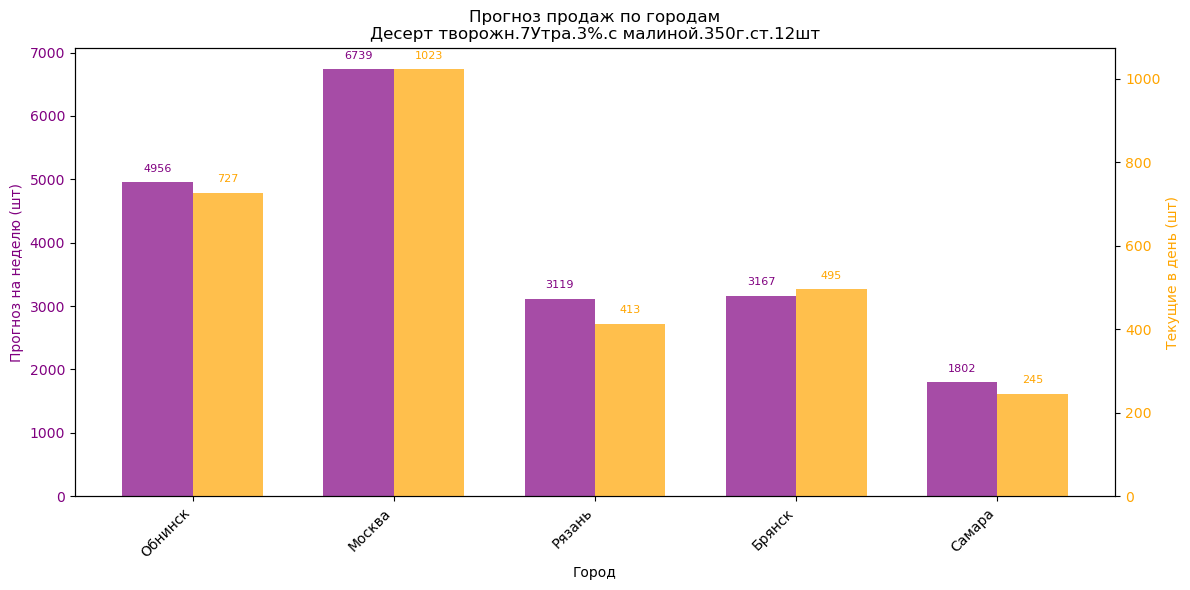


  АНАЛИЗ МОДЕЛИ


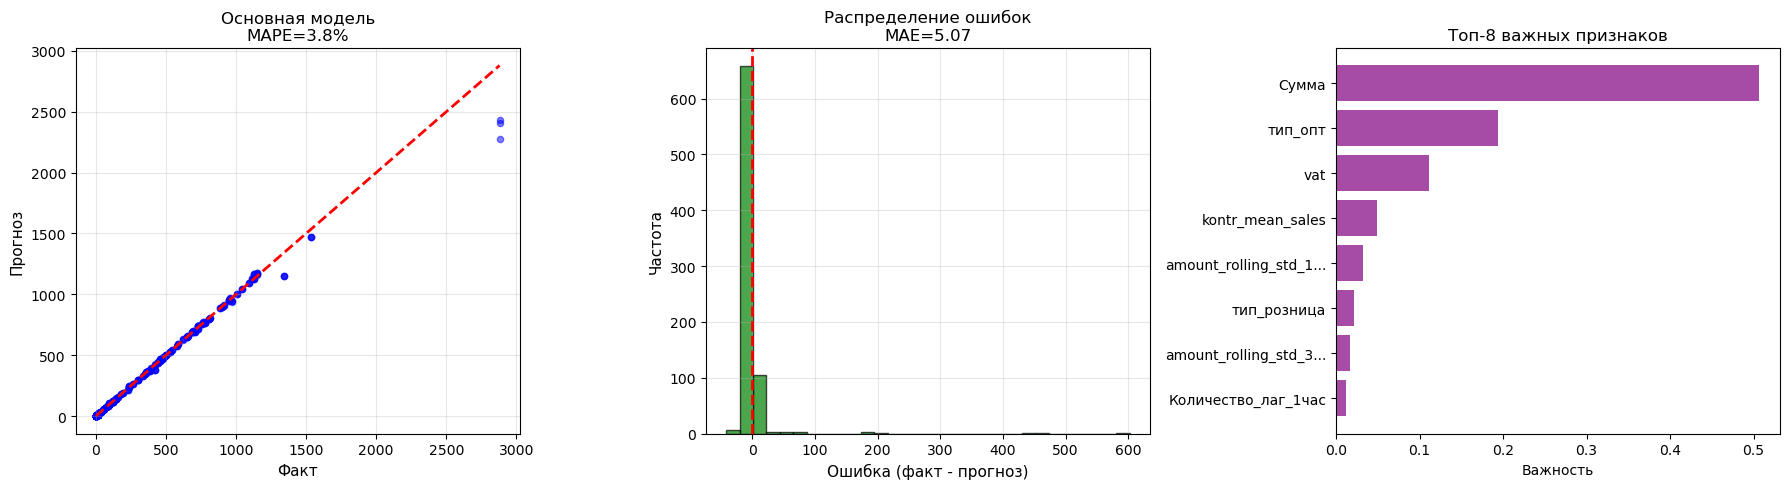


  РАЗДЕЛЬНЫЕ МОДЕЛИ ПО ТИПАМ


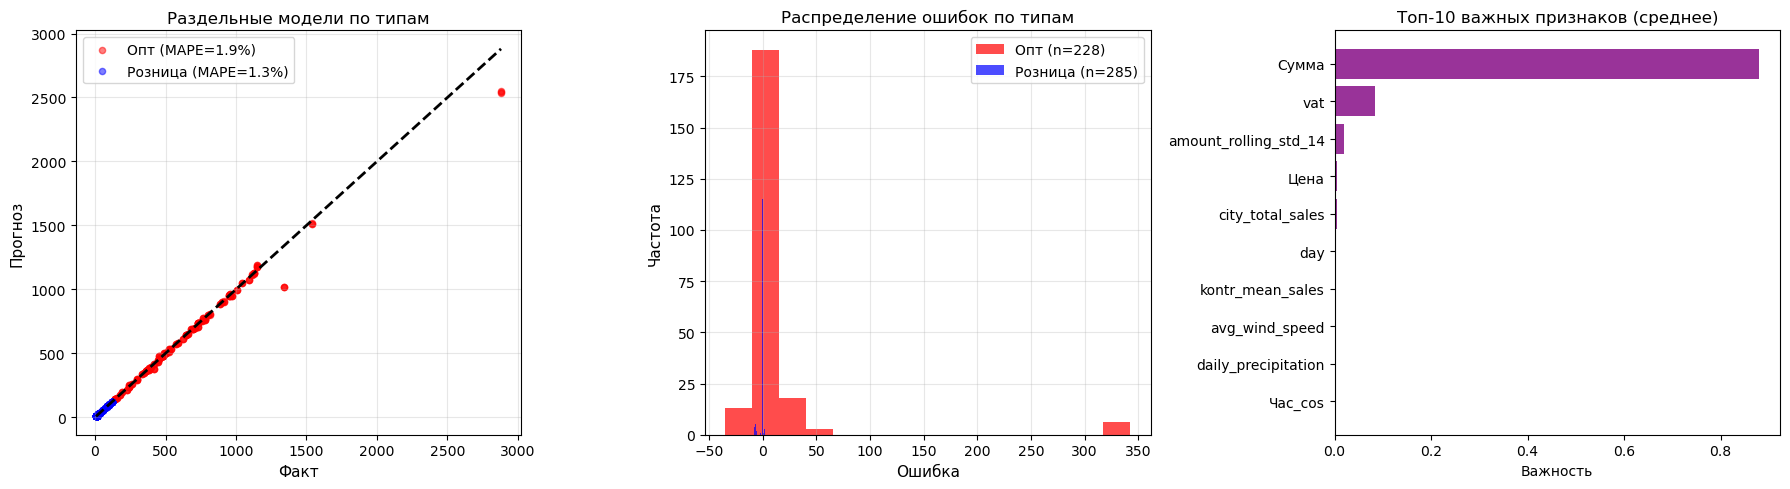


  СОХРАНЕНИЕ В MINIO
     Функция save_to_minio не определена, пропускаем сохранение

 Визуализация для Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт завершена


In [44]:
# ============================================
# ОТДЕЛЬНАЯ ЯЧЕЙКА ДЛЯ ВИЗУАЛИЗАЦИИ РЕЗУЛЬТАТОВ
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import re
from minio import Minio
from io import BytesIO

print(f"\n{'='*70}")
print(" ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МОДЕЛЕЙ")
print('='*70)

# Проверяем, есть ли сохраненные результаты
if 'model_results' not in locals() or not model_results:
    print(" Результаты моделей не найдены. Сначала выполните ячейку с обучением!")
else:
    # Показываем список всех товаров
    products_list = list(model_results.keys())
    print(f"\n ДОСТУПНЫЕ ТОВАРЫ ({len(products_list)} шт.):")
    for i, prod in enumerate(products_list, 1):
        mape = model_results[prod]['mape']
        train_size = model_results[prod]['train_size']
        test_size = model_results[prod]['test_size']
        status = " " if mape < 10 else " " if mape < 20 else " "
        print(f"   {i:2d}. {status} {prod[:60]}... (MAPE: {mape:.1f}%, train: {train_size}, test: {test_size})")

    # Запрашиваем номер товара
    while True:
        try:
            choice = input("\n Введите номер товара для визуализации (1-{}): ".format(len(products_list))).strip()
            idx = int(choice) - 1
            if 0 <= idx < len(products_list):
                selected_product = products_list[idx]
                break
            else:
                print(f" Пожалуйста, введите число от 1 до {len(products_list)}")
        except ValueError:
            print(" Пожалуйста, введите число")

    print(f"\n{'='*70}")
    print(f" ВИЗУАЛИЗАЦИЯ ДЛЯ: {selected_product[:70]}")
    print('='*70)

    # Получаем результаты
    res = model_results[selected_product]

    # ============================================
    # 1. ПРОГНОЗ ПО ГОРОДАМ (САМОЕ ВАЖНОЕ!)
    # ============================================
    print("\n" + "="*60)
    print("  ПРОГНОЗ ПРОДАЖ ПО ГОРОДАМ")
    print("="*60)

    # Получаем данные для этого товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == selected_product].copy()
    
    #  ИСПРАВЛЕНО: Проверяем, есть ли колонка 'city' (английская)
    city_col = None
    if 'city' in df_product.columns:
        city_col = 'city'
    elif 'Город' in df_product.columns:
        city_col = 'Город'
    else:
        print(" В данных нет информации о городах")
        city_col = None
    
    if city_col is not None:
        # Переименовываем для удобства, если нужно
        if city_col == 'city':
            df_product = df_product.rename(columns={'city': 'Город'})
        
        # Статистика по городам
        city_stats = df_product.groupby('Город').agg({
            'quantity': ['sum', 'mean', 'count'],
            'amount': 'sum'
        }).round(2)
        city_stats.columns = ['всего_шт', 'среднее_шт', 'кол_заказов', 'сумма_руб']
        city_stats = city_stats.sort_values('сумма_руб', ascending=False)
        city_stats['средний_чек'] = city_stats['сумма_руб'] / city_stats['кол_заказов']

        print("\n ТОП-5 ГОРОДОВ ПО СУММЕ:")
        for city, row in city_stats.head(5).iterrows():
            print(f"   {city}: {row['сумма_руб']:,.0f} руб ({row['всего_шт']:.0f} шт, {row['кол_заказов']:.0f} заказов)")

        print("\n ТОП-5 ГОРОДОВ ПО СРЕДНЕМУ ЧЕКУ:")
        for city, row in city_stats.sort_values('средний_чек', ascending=False).head(5).iterrows():
            print(f"   {city}: {row['средний_чек']:.0f} руб/заказ")

        # ПРОГНОЗ ПО ГОРОДАМ
        print("\n ПРОГНОЗ НА СЛЕДУЮЩУЮ НЕДЕЛЮ ПО ГОРОДАМ:")
        print("-" * 60)

        forecasts = []
        for city in city_stats.head(5).index:  # Топ-5 городов
            city_data = df_product[df_product['Город'] == city].copy()
            city_data = city_data.sort_values('date' if 'date' in city_data.columns else 'Дата')
            
            # Определяем колонку с количеством
            qty_col = 'quantity' if 'quantity' in city_data.columns else 'Количество'
            
            if len(city_data) > 7:
                # Последние 7 дней
                last_week = city_data.tail(7)
                avg_last_week = last_week[qty_col].mean()
                
                # Тренд за последние 30 дней
                if len(city_data) > 30:
                    recent = city_data.tail(30)[qty_col].mean()
                    if len(city_data) > 60:
                        old = city_data.iloc[-60:-30][qty_col].mean()
                    else:
                        old = city_data.head(30)[qty_col].mean()
                    trend = ((recent - old) / old * 100) if old > 0 else 0
                else:
                    trend = 0
                
                # Прогноз на неделю
                forecast_daily = avg_last_week * (1 + trend/100/4)
                forecast_weekly = forecast_daily * 7
                
                forecasts.append({
                    'city': city,
                    'current_daily': avg_last_week,
                    'trend': trend,
                    'forecast_weekly': forecast_weekly
                })
                
                trend_symbol = " " if trend > 5 else " " if trend < -5 else " "
                print(f"\n   {trend_symbol} {city}:")
                print(f"      Текущие продажи: {avg_last_week:.1f} шт/день")
                print(f"      Тренд: {trend:+.1f}%")
                print(f"      Прогноз на неделю: {forecast_weekly:.0f} шт")

        # График прогнозов по городам
        if forecasts:
            plt.figure(figsize=(12, 6))
            cities = [f['city'][:15] + '...' if len(f['city']) > 15 else f['city'] for f in forecasts]
            weekly = [f['forecast_weekly'] for f in forecasts]
            daily = [f['current_daily'] for f in forecasts]
            
            x = np.arange(len(cities))
            width = 0.35
            
            fig, ax1 = plt.subplots(figsize=(12, 6))
            
            # Столбцы для недельного прогноза
            bars1 = ax1.bar(x - width/2, weekly, width, label='Прогноз на неделю', color='purple', alpha=0.7)
            ax1.set_xlabel('Город')
            ax1.set_ylabel('Прогноз на неделю (шт)', color='purple')
            ax1.tick_params(axis='y', labelcolor='purple')
            
            # Вторая ось для текущих ежедневных продаж
            ax2 = ax1.twinx()
            bars2 = ax2.bar(x + width/2, daily, width, label='Текущие в день', color='orange', alpha=0.7)
            ax2.set_ylabel('Текущие в день (шт)', color='orange')
            ax2.tick_params(axis='y', labelcolor='orange')
            
            # Настройки
            plt.title(f'Прогноз продаж по городам\n{selected_product[:50]}')
            ax1.set_xticks(x)
            ax1.set_xticklabels(cities, rotation=45, ha='right')
            
            # Добавляем значения
            for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
                height1 = bar1.get_height()
                height2 = bar2.get_height()
                if not np.isnan(height1):
                    ax1.text(bar1.get_x() + bar1.get_width()/2, height1 + max(weekly)*0.02, 
                            f'{height1:.0f}', ha='center', va='bottom', fontsize=8, color='purple')
                if not np.isnan(height2):
                    ax2.text(bar2.get_x() + bar2.get_width()/2, height2 + max(daily)*0.02, 
                            f'{height2:.0f}', ha='center', va='bottom', fontsize=8, color='orange')
            
            plt.tight_layout()
            plt.show()

    # ============================================
    # 2. ГРАФИКИ МОДЕЛИ
    # ============================================
    print("\n" + "="*60)
    print("  АНАЛИЗ МОДЕЛИ")
    print("="*60)

    plt.figure(figsize=(18, 5))

    # 2.1 Факт vs Прогноз
    plt.subplot(1, 3, 1)
    y_test = res['y_test']
    y_pred = res['y_pred']

    plt.scatter(y_test, y_pred, alpha=0.5, s=20, color='blue')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    plt.xlabel('Факт', fontsize=11)
    plt.ylabel('Прогноз', fontsize=11)
    plt.title(f'Основная модель\nMAPE={res["mape"]:.1f}%', fontsize=12)
    plt.grid(True, alpha=0.3)

    # 2.2 Распределение ошибок
    plt.subplot(1, 3, 2)
    errors = y_test - y_pred
    plt.hist(errors, bins=30, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Ошибка (факт - прогноз)', fontsize=11)
    plt.ylabel('Частота', fontsize=11)
    plt.title(f'Распределение ошибок\nMAE={res["mae"]:.2f}', fontsize=12)
    plt.grid(True, alpha=0.3)

    # 2.3 Важность признаков
    plt.subplot(1, 3, 3)
    feature_imp = sorted(zip(res['feature_cols'], res['feature_importance']), 
                        key=lambda x: x[1], reverse=True)[:8]
    feat_names = [f[0][:20] + '...' if len(f[0]) > 20 else f[0] for f in feature_imp]
    feat_imp = [f[1] for f in feature_imp]

    plt.barh(range(len(feat_names)), feat_imp, color='purple', alpha=0.7)
    plt.yticks(range(len(feat_names)), feat_names)
    plt.xlabel('Важность')
    plt.title('Топ-8 важных признаков', fontsize=12)
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

    # ============================================
    # 3. РАЗДЕЛЬНЫЕ МОДЕЛИ (если есть)
    # ============================================
    if res['opt_model'] is not None and res['roz_model'] is not None:
        print("\n" + "="*60)
        print("  РАЗДЕЛЬНЫЕ МОДЕЛИ ПО ТИПАМ")
        print("="*60)
        
        plt.figure(figsize=(18, 5))
        
        # 3.1 Сравнение моделей
        plt.subplot(1, 3, 1)
        
        if res['y_opt_test'] is not None and len(res['y_opt_test']) > 0:
            plt.scatter(res['y_opt_test'], res['y_opt_pred'], alpha=0.5, s=20, color='red', 
                       label=f'Опт (MAPE={res["mape_opt"]:.1f}%)')
        if res['y_roz_test'] is not None and len(res['y_roz_test']) > 0:
            plt.scatter(res['y_roz_test'], res['y_roz_pred'], alpha=0.5, s=20, color='blue', 
                       label=f'Розница (MAPE={res["mape_roz"]:.1f}%)')
        
        if res['y_opt_test'] is not None and len(res['y_opt_test']) > 0 and res['y_roz_test'] is not None and len(res['y_roz_test']) > 0:
            all_y = np.concatenate([res['y_opt_test'], res['y_roz_test']])
            all_pred = np.concatenate([res['y_opt_pred'], res['y_roz_pred']])
            min_val = min(all_y.min(), all_pred.min())
            max_val = max(all_y.max(), all_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
        
        plt.xlabel('Факт', fontsize=11)
        plt.ylabel('Прогноз', fontsize=11)
        plt.title(f'Раздельные модели по типам', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 3.2 Ошибки по типам
        plt.subplot(1, 3, 2)
        
        if res['y_opt_test'] is not None and len(res['y_opt_test']) > 0:
            errors_opt = res['y_opt_test'] - res['y_opt_pred']
            plt.hist(errors_opt, alpha=0.7, label=f'Опт (n={len(res["y_opt_test"])})', bins=15, color='red')
        
        if res['y_roz_test'] is not None and len(res['y_roz_test']) > 0:
            errors_roz = res['y_roz_test'] - res['y_roz_pred']
            plt.hist(errors_roz, alpha=0.7, label=f'Розница (n={len(res["y_roz_test"])})', bins=15, color='blue')
        
        plt.xlabel('Ошибка', fontsize=11)
        plt.ylabel('Частота', fontsize=11)
        plt.legend()
        plt.title('Распределение ошибок по типам', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # 3.3 Важность признаков
        plt.subplot(1, 3, 3)
        
        if res['opt_model'] is not None and hasattr(res['opt_model'], 'feature_importances_'):
            importance_df = pd.DataFrame({
                'feature': res['feature_cols'],
                'importance_opt': res['opt_model'].feature_importances_,
                'importance_roz': res['roz_model'].feature_importances_ if res['roz_model'] is not None else 0
            })
            importance_df['importance_avg'] = (importance_df['importance_opt'] + importance_df['importance_roz']) / 2
            importance_df = importance_df.sort_values('importance_avg', ascending=True).tail(10)
            
            plt.barh(importance_df['feature'], importance_df['importance_avg'], color='purple', alpha=0.8)
            plt.title('Топ-10 важных признаков (среднее)', fontsize=12)
            plt.xlabel('Важность')
        
        plt.tight_layout()
        plt.show()

    # ============================================
    # 4. СОХРАНЕНИЕ В MINIO (опционально)
    # ============================================
    print("\n" + "="*60)
    print("  СОХРАНЕНИЕ В MINIO")
    print("="*60)

    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', selected_product)[:50]
    
    try:
        # Проверяем, определена ли функция save_to_minio
        if 'save_to_minio' in locals() or 'save_to_minio' in globals():
            save_to_minio(
                bucket_name="sales-analytics",
                block_name=clean_name,
                plot_name=f"прогноз_{datetime.now().strftime('%Y%m%d')}",
                data=None,
                fig=plt.gcf(),
                formats=['pdf']
            )
            print(f"     Графики сохранены в Minio")
        else:
            print(f"     Функция save_to_minio не определена, пропускаем сохранение")
    except Exception as e:
        print(f"     Ошибка сохранения: {e}")

    print(f"\n Визуализация для {selected_product[:50]} завершена")

In [45]:
df_product.head()

,Номенклатура,date,quantity,price,amount,vat,counterparty,organization,Город,year,...,salary_volatility,salary_cv,salary_last_known,salary_last_year,salary_first_known,salary_first_year,salary_avg,salary_min,salary_max,salary_forecast_next
0,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
1,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
2,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 16:58:00,1164.0,161.48,65786.95,5980.63,Агроторг ООО (Ворсино-Алкоголь РЦ),"ООО ""7 Утра""",Обнинск,2025,...,46897.876378,0.229625,299531.9,2023.0,139842.9,2013.0,204236.654545,139842.9,299531.9,314036.799091
3,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,43254.879543,0.243280,269313.6,2023.0,130510.5,2013.0,177798.390909,130510.5,269313.6,282403.900909
4,Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт,2025-03-16 17:38:47,756.0,161.48,42727.61,3884.33,Агроторг ООО (Рязань-Алкоголь РЦ),"ООО ""7 Утра""",Рязань,2025,...,43254.879543,0.243280,269313.6,2023.0,130510.5,2013.0,177798.390909,130510.5,269313.6,282403.900909


In [47]:
class SalesForecaster:
    def __init__(self, model_opt, model_roz, feature_cols, product_name, city_features=None):
        """
        Класс для прогнозирования продаж
        
        Parameters:
        model_opt: обученная модель для опта
        model_roz: обученная модель для розницы
        feature_cols: список признаков
        product_name: название товара
        city_features: список городских признаков
        """
        self.model_opt = model_opt
        self.model_roz = model_roz
        self.feature_cols = feature_cols
        self.product_name = product_name
        self.city_features = city_features or []
        self.last_known = None
        self.city_stats = None
        self.numeric_stats = {}  # Для хранения статистики по числовым колонкам
        
    def update_last_known(self, df):
        """Обновляет последние известные данные"""
        print(f"\n ЗАГРУЗКА ПОСЛЕДНИХ ДАННЫХ ДЛЯ {self.product_name[:50]}")
        print("-" * 60)
        
        # Берем последние 168 записей
        self.last_known = df.sort_values('date').tail(168).copy()
        print(f"   Загружено {len(self.last_known)} последних записей")
        print(f"   Период: {self.last_known['date'].min()} - {self.last_known['date'].max()}")
        
        #  ИСПРАВЛЕНО: Сохраняем только числовые колонки для статистики
        numeric_cols = self.last_known.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            self.numeric_stats[col] = {
                'mean': self.last_known[col].mean(),
                'std': self.last_known[col].std(),
                'last': self.last_known[col].iloc[-1]
            }
        
        # Сохраняем статистику по городам
        if 'city' in self.last_known.columns:
            self.city_stats = self.last_known.groupby('city')['quantity'].agg(['mean', 'std', 'count']).round(2)
            self.city_stats.columns = ['среднее_шт', 'std_шт', 'кол_заказов']
            print(f"   Городов в последних данных: {len(self.city_stats)}")
        
        # Проверяем наличие колонок с типами продаж
        if 'тип_опт' not in self.last_known.columns:
            print("    Колонка 'тип_опт' не найдена, создаем на основе квантилей")
            q67 = self.last_known['quantity'].quantile(0.67)
            self.last_known['тип_опт'] = (self.last_known['quantity'] > q67).astype(int)
            self.last_known['тип_розница'] = (self.last_known['quantity'] <= q67).astype(int)
    
    def _prepare_features(self, record, city):
        """Подготавливает признаки для одной записи с учетом города"""
        record = record.copy()
        
        #  ИСПРАВЛЕНО: Убираем все нечисловые колонки
        non_numeric_cols = ['season', 'region', 'date_only', 'sales_type']
        for col in non_numeric_cols:
            if col in record:
                del record[col]
        
        # Добавляем городские признаки (числовые)
        if city and self.city_stats is not None and city in self.city_stats.index:
            record['city_mean_sales'] = float(self.city_stats.loc[city, 'среднее_шт'])
            record['city_std_sales'] = float(self.city_stats.loc[city, 'std_шт'])
            record['city_order_count'] = float(self.city_stats.loc[city, 'кол_заказов'])
            record['city_sales_share'] = float(self.city_stats.loc[city, 'кол_заказов'] / len(self.last_known))
        else:
            # Если город неизвестен, используем средние
            record['city_mean_sales'] = float(self.last_known['quantity'].mean())
            record['city_std_sales'] = float(self.last_known['quantity'].std())
            record['city_order_count'] = float(len(self.last_known))
            record['city_sales_share'] = 0.1
        
        # Добавляем остальные признаки из числовой статистики
        for col in self.feature_cols:
            if col not in record and col in self.numeric_stats:
                record[col] = float(self.numeric_stats[col]['mean'])
            elif col not in record:
                record[col] = 0.0
        
        return record
    
    def _predict_row(self, row):
        """Предсказание для одной строки"""
        try:
            #  ИСПРАВЛЕНО: Создаем словарь только с числовыми значениями
            X_dict = {}
            for col in self.feature_cols:
                if col in row:
                    # Пробуем преобразовать в число
                    try:
                        val = float(row[col])
                        X_dict[col] = val
                    except (ValueError, TypeError):
                        # Если не получается, берем из статистики
                        if col in self.numeric_stats:
                            X_dict[col] = float(self.numeric_stats[col]['mean'])
                        else:
                            X_dict[col] = 0.0
                elif col in self.numeric_stats:
                    X_dict[col] = float(self.numeric_stats[col]['mean'])
                else:
                    X_dict[col] = 0.0
            
            # Создаем DataFrame в правильном порядке колонок
            X_row = pd.DataFrame([X_dict])[self.feature_cols]
            
            # Заполняем пропуски
            X_row = X_row.fillna(0)
            
            # Определяем тип продажи
            is_opt = row.get('тип_опт', 0)
            try:
                is_opt = float(is_opt)
            except:
                is_opt = 0
            
            # Делаем предсказание
            if is_opt == 1 and self.model_opt is not None:
                pred = self.model_opt.predict(X_row)[0]
            else:
                pred = self.model_roz.predict(X_row)[0]
            
            return max(0, float(pred))  # Неотрицательные продажи
                
        except Exception as e:
            print(f"    Ошибка предсказания: {e}")
            return 0.0
    
    def forecast(self, start_date, days=7, cities=None):
        """
        Прогноз на указанный период
        """
        if self.last_known is None:
            raise ValueError(" Сначала вызовите update_last_known()")
        
        print(f"\n{'='*60}")
        print(f" ПРОГНОЗ ДЛЯ {self.product_name[:50]}")
        print('='*60)
        print(f"   Период: {start_date.date()} - {(start_date + timedelta(days=days-1)).date()}")
        print(f"   Дней: {days}")
        
        # Определяем города для прогноза
        if cities is None:
            if self.city_stats is not None:
                cities = self.city_stats.index.tolist()
                print(f"   Городов: {len(cities)} (все из последних данных)")
            else:
                cities = ['default']
                print(f"   Городов: нет данных, используем общую модель")
        else:
            print(f"   Городов: {len(cities)} (выбранные)")
        
        # Создаем данные для прогноза
        forecast_data = []
        
        # Берем шаблон из последней известной записи
        template = self.last_known.iloc[-1:].copy()
        
        # Получаем уникальные организации
        organizations = self.last_known['organization'].unique() if 'organization' in self.last_known.columns else ['default']
        
        total_records = days * len(cities) * len(organizations) * 5
        print(f"   Всего прогнозных записей: {total_records}")
        
        record_count = 0
        for day in range(days):
            current_date = start_date + timedelta(days=day)
            
            for city in cities:
                for org in organizations:
                    # Для каждого часа работы (8-20)
                    for hour in [8, 11, 14, 17, 20]:
                        
                        # Создаем запись на основе шаблона
                        record = {}
                        
                        # Основные поля
                        record['date'] = pd.Timestamp(current_date.year, current_date.month, current_date.day, hour, 0)
                        record['organization'] = org
                        record['city'] = city
                        
                        # Временные признаки
                        record['year'] = current_date.year
                        record['month'] = current_date.month
                        record['day'] = current_date.day
                        record['dayofweek'] = current_date.weekday()
                        record['hour'] = hour
                        
                        # Циклические признаки (числовые!)
                        record['month_sin'] = float(np.sin(2 * np.pi * current_date.month / 12))
                        record['month_cos'] = float(np.cos(2 * np.pi * current_date.month / 12))
                        record['hour_sin'] = float(np.sin(2 * np.pi * hour / 24))
                        record['hour_cos'] = float(np.cos(2 * np.pi * hour / 24))
                        record['dow_sin'] = float(np.sin(2 * np.pi * current_date.weekday() / 7))
                        record['dow_cos'] = float(np.cos(2 * np.pi * current_date.weekday() / 7))
                        
                        # Дополнительные признаки
                        record['is_weekend'] = 1 if current_date.weekday() >= 5 else 0
                        
                        # Тип продажи (по умолчанию розница)
                        record['тип_опт'] = 0
                        record['тип_розница'] = 1
                        
                        # Добавляем недостающие признаки с учетом города
                        record = self._prepare_features(record, city)
                        
                        forecast_data.append(record)
                        record_count += 1
                        
                        if record_count % 500 == 0:
                            print(f"      Создано {record_count}/{total_records} записей")
        
        # Создаем DataFrame
        forecast_df = pd.DataFrame(forecast_data)
        print(f"\n    Создано {len(forecast_df)} записей для прогноза")
        
        # Делаем прогноз
        print(f"\n    Вычисляем прогноз...")
        predictions = []
        
        batch_size = 100
        for i in range(0, len(forecast_df), batch_size):
            batch = forecast_df.iloc[i:i+batch_size]
            batch_preds = []
            
            for _, row in batch.iterrows():
                pred = self._predict_row(row)
                batch_preds.append(pred)
            
            predictions.extend(batch_preds)
            
            if (i + batch_size) % 500 == 0:
                print(f"      Обработано {min(i+batch_size, len(forecast_df))}/{len(forecast_df)}")
        
        forecast_df['forecast'] = predictions
        
        # Агрегируем результаты
        print(f"\n АГРЕГИРОВАННЫЙ ПРОГНОЗ:")
        print("-" * 60)
        
        # По дням
        daily_forecast = forecast_df.groupby(forecast_df['date'].dt.date)['forecast'].sum().round(0)
        print(f"\n   Прогноз по дням:")
        total = 0
        for date, value in daily_forecast.items():
            print(f"      {date}: {value:,.0f} шт")
            total += value
        print(f"      {'='*30}")
        print(f"      ИТОГО: {total:,.0f} шт")
        
        # По городам
        city_forecast = forecast_df.groupby('city')['forecast'].sum().sort_values(ascending=False)
        print(f"\n   Прогноз по городам (топ-5):")
        for city, value in city_forecast.head(5).items():
            print(f"      {city[:20]:20} - {value:,.0f} шт")
        
        return forecast_df
    
    def forecast_by_city(self, start_date, days=7, cities=None):
        """Прогноз с детализацией по городам"""
        forecast_df = self.forecast(start_date, days, cities)
        
        # Агрегация по городам и дням
        pivot = forecast_df.pivot_table(
            index=forecast_df['date'].dt.date,
            columns='city',
            values='forecast',
            aggfunc='sum'
        ).round(0)
        
        pivot['ИТОГО'] = pivot.sum(axis=1)
        
        return pivot
    
    def save_forecast(self, forecast_df, filename=None):
        """Сохраняет прогноз в файл"""
        if filename is None:
            filename = f"forecast_{self.product_name[:30]}_{datetime.now().strftime('%Y%m%d')}.csv"
        
        # Очищаем filename от недопустимых символов
        filename = re.sub(r'[<>:"/\\|?*%\'"]', '_', filename)
        
        # Сохраняем локально
        forecast_df.to_csv(filename, index=False)
        print(f"\n Прогноз сохранен в файл: {filename}")
        
        return filename


# ============================================
# ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ПРОГНОЗА
# ============================================

def create_forecast_for_product(product_name, model_results, start_date=None, days=7):
    """
    Создает прогноз для конкретного товара
    """
    if product_name not in model_results:
        print(f" Товар {product_name} не найден в результатах")
        return None, None
    
    res = model_results[product_name]
    
    # Получаем данные для товара
    df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
    
    # Переименовываем колонки
    rename_dict = {
        'date': 'date',
        'quantity': 'quantity',
        'amount': 'amount',
        'city': 'city',
        'counterparty': 'counterparty',
        'organization': 'organization'
    }
    rename_dict = {k: v for k, v in rename_dict.items() if k in df_product.columns}
    df_product = df_product.rename(columns=rename_dict)
    
    # Создаем прогнозист
    forecaster = SalesForecaster(
        model_opt=res['opt_model'],
        model_roz=res['roz_model'],
        feature_cols=res['feature_cols'],
        product_name=product_name,
        city_features=[col for col in res['feature_cols'] if 'city_' in col]
    )
    
    # Загружаем последние данные
    forecaster.update_last_known(df_product)
    
    # Устанавливаем дату начала
    if start_date is None:
        start_date = datetime.now()
    
    # Делаем прогноз
    forecast_df = forecaster.forecast(start_date, days=days)
    
    return forecaster, forecast_df


# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ
# ============================================

if __name__ == "__main__":
    print("\n Доступные товары:")
    for i, prod in enumerate(list(model_results.keys())[:5], 1):
        mape = model_results[prod]['mape']
        print(f"   {i}. {prod[:60]}... (MAPE: {mape:.1f}%)")
    
    try:
        prod_idx = int(input("\nВведите номер товара для прогноза: ")) - 1
        selected_product = list(model_results.keys())[prod_idx]
        
        # Создаем прогноз
        forecaster, forecast = create_forecast_for_product(
            product_name=selected_product,
            model_results=model_results,
            days=7
        )
        
        # Сохраняем прогноз
        if forecast is not None:
            forecaster.save_forecast(forecast)
            
            # Показываем детальный прогноз по городам
            print("\n ДЕТАЛЬНЫЙ ПРОГНОЗ ПО ГОРОДАМ:")
            city_pivot = forecast.pivot_table(
                index=forecast['date'].dt.date,
                columns='city',
                values='forecast',
                aggfunc='sum'
            ).round(0)
            print(city_pivot)
            
    except Exception as e:
        print(f" Ошибка: {e}")


 Доступные товары:
   1. Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт... (MAPE: 3.8%)
   2. Йогурт.7Утра.2,5%.с вишн.двухсл.350г.ст.12шт... (MAPE: 61.9%)
   3. Масса твор.с ванилином.7Утра.5%.180г.ф/пак.8шт... (MAPE: 9.1%)
   4. Масса твор.с изюмом.7Утра.5%.180г.ф/пак.8шт... (MAPE: 5.3%)
   5. Масса твор.с курагой.7Утра.5%.180г.ф/пак.8шт... (MAPE: 278.4%)



Введите номер товара для прогноза:  1



 ЗАГРУЗКА ПОСЛЕДНИХ ДАННЫХ ДЛЯ Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт
------------------------------------------------------------
   Загружено 168 последних записей
   Период: 2026-03-10 06:05:55 - 2026-03-15 16:08:31
   Городов в последних данных: 17
    Колонка 'тип_опт' не найдена, создаем на основе квантилей

 ПРОГНОЗ ДЛЯ Десерт творожн.7Утра.3%.с малиной.350г.ст.12шт
   Период: 2026-03-17 - 2026-03-23
   Дней: 7
   Городов: 17 (все из последних данных)
   Всего прогнозных записей: 1190
      Создано 500/1190 записей
      Создано 1000/1190 записей

    Создано 1190 записей для прогноза

    Вычисляем прогноз...
      Обработано 500/1190
      Обработано 1000/1190

 АГРЕГИРОВАННЫЙ ПРОГНОЗ:
------------------------------------------------------------

   Прогноз по дням:
      2026-03-17: 1,606 шт
      2026-03-18: 1,606 шт
      2026-03-19: 1,606 шт
      2026-03-20: 1,606 шт
      2026-03-21: 1,611 шт
      2026-03-22: 1,605 шт
      2026-03-23: 1,606 шт
      ИТОГО: 11,

In [48]:
from minio import Minio
from io import BytesIO
from datetime import datetime
import re
import pandas as pd
import numpy as np

def save_product_data_to_minio(df, product_name, include_metadata=True, include_forecast=True, forecast_df=None):
    """
    Сохраняет данные по товару в Minio в формате CSV для обычных пользователей
    
    Parameters:
    df: DataFrame с данными по товару (из full_df_enriched)
    product_name: название товара
    include_metadata: добавить ли файл с описанием
    include_forecast: добавить ли прогноз
    forecast_df: DataFrame с прогнозом (если есть)
    """
    
    client = Minio(
        endpoint="host.docker.internal:9002",
        access_key="minioadmin",
        secret_key="minioadmin",
        secure=False
    )
    
    # Очищаем имя для пути
    clean_name = re.sub(r'[<>:"/\\|?*%\'"]', '_', product_name)
    clean_name = clean_name[:50]
    
    # Создаем бакет если нет
    if not client.bucket_exists("sales-reports"):
        client.make_bucket("sales-reports")
        print(" Создан бакет sales-reports для отчетов")
    
    date_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Определяем названия колонок (могут быть английские или русские)
    date_col = 'date' if 'date' in df.columns else 'Дата'
    qty_col = 'quantity' if 'quantity' in df.columns else 'Количество'
    amount_col = 'amount' if 'amount' in df.columns else 'Сумма'
    city_col = 'city' if 'city' in df.columns else 'Город'
    org_col = 'organization' if 'organization' in df.columns else 'Организация'
    kontr_col = 'counterparty' if 'counterparty' in df.columns else 'Контрагент'
    
    # 1. СОХРАНЯЕМ ОСНОВНЫЕ ДАННЫЕ В CSV (только нужные колонки для пользователей)
    user_columns = []
    if date_col in df.columns:
        user_columns.append(date_col)
    if qty_col in df.columns:
        user_columns.append(qty_col)
    if amount_col in df.columns:
        user_columns.append(amount_col)
    if city_col in df.columns:
        user_columns.append(city_col)
    if org_col in df.columns:
        user_columns.append(org_col)
    if kontr_col in df.columns:
        user_columns.append(kontr_col)
    
    # Добавляем еще несколько полезных колонок
    extra_cols = ['price', 'vat', 'inflation_rate_monthly', 'avg_temperature']
    for col in extra_cols:
        if col in df.columns:
            user_columns.append(col)
    
    df_user = df[user_columns].copy()
    
    # Переименовываем колонки для пользователей (на русские)
    rename_map = {
        'date': 'Дата',
        'quantity': 'Количество',
        'amount': 'Сумма',
        'price': 'Цена',
        'city': 'Город',
        'counterparty': 'Контрагент',
        'organization': 'Организация',
        'vat': 'НДС',
        'inflation_rate_monthly': 'Инфляция',
        'avg_temperature': 'Температура'
    }
    df_user = df_user.rename(columns={k: v for k, v in rename_map.items() if k in df_user.columns})
    
    csv_buffer = BytesIO()
    df_user.to_csv(csv_buffer, index=False, encoding='utf-8-sig', sep=';')
    csv_buffer.seek(0)
    
    csv_path = f"csv/{clean_name}/sales_data_{date_str}.csv"
    client.put_object(
        "sales-reports",
        csv_path,
        data=csv_buffer,
        length=csv_buffer.getbuffer().nbytes,
        content_type='text/csv; charset=utf-8'
    )
    print(f" CSV сохранен: http://localhost:9003/sales-reports/{csv_path}")
    
    # 2. СОЗДАЕМ ПРОСТУЮ СВОДКУ (для пользователей)
    if include_metadata:
        # Основные метрики
        summary_data = []
        
        # Основная информация
        summary_data.append(['Название товара', product_name])
        if date_col in df.columns:
            summary_data.append(['Период с', str(pd.to_datetime(df[date_col]).min().date())])
            summary_data.append(['Период по', str(pd.to_datetime(df[date_col]).max().date())])
        
        summary_data.append(['Всего записей', str(len(df))])
        
        if qty_col in df.columns:
            summary_data.append(['Средние продажи', f"{df[qty_col].mean():.2f}"])
            summary_data.append(['Медианные продажи', f"{df[qty_col].median():.2f}"])
            summary_data.append(['Минимальные продажи', str(df[qty_col].min())])
            summary_data.append(['Максимальные продажи', str(df[qty_col].max())])
            summary_data.append(['Суммарные продажи', f"{df[qty_col].sum():.2f}"])
        
        if amount_col in df.columns:
            summary_data.append(['Общая выручка', f"{df[amount_col].sum():,.2f} руб"])
        
        if city_col in df.columns:
            summary_data.append(['Количество городов', str(df[city_col].nunique())])
            # Топ-3 города
            top_cities = df.groupby(city_col)[qty_col].sum().nlargest(3)
            for i, (city, qty) in enumerate(top_cities.items(), 1):
                summary_data.append([f'Топ-{i} город', f"{city} ({qty:.0f} шт)"])
        
        if org_col in df.columns:
            summary_data.append(['Количество организаций', str(df[org_col].nunique())])
        
        if kontr_col in df.columns:
            summary_data.append(['Количество контрагентов', str(df[kontr_col].nunique())])
        
        summary_df = pd.DataFrame(summary_data, columns=['Показатель', 'Значение'])
        
        summary_buffer = BytesIO()
        summary_df.to_csv(summary_buffer, index=False, encoding='utf-8-sig', sep=';')
        summary_buffer.seek(0)
        
        summary_path = f"csv/{clean_name}/summary_{date_str}.csv"
        client.put_object(
            "sales-reports",
            summary_path,
            data=summary_buffer,
            length=summary_buffer.getbuffer().nbytes,
            content_type='text/csv; charset=utf-8'
        )
        print(f" Сводка сохранена: http://localhost:9003/sales-reports/{summary_path}")
    
    # 3. СОХРАНЯЕМ ПРОГНОЗ (если есть)
    if include_forecast and forecast_df is not None:
        forecast_buffer = BytesIO()
        
        # Подготавливаем прогноз для пользователей
        forecast_user = forecast_df[['date', 'city', 'forecast']].copy()
        forecast_user['date'] = pd.to_datetime(forecast_user['date']).dt.date
        forecast_user = forecast_user.rename(columns={
            'date': 'Дата',
            'city': 'Город',
            'forecast': 'Прогноз (шт)'
        })
        
        # Агрегируем по дням
        daily_forecast = forecast_user.groupby('Дата')['Прогноз (шт)'].sum().reset_index()
        
        forecast_user.to_csv(forecast_buffer, index=False, encoding='utf-8-sig', sep=';')
        forecast_buffer.seek(0)
        
        forecast_path = f"csv/{clean_name}/forecast_{date_str}.csv"
        client.put_object(
            "sales-reports",
            forecast_path,
            data=forecast_buffer,
            length=forecast_buffer.getbuffer().nbytes,
            content_type='text/csv; charset=utf-8'
        )
        print(f" Прогноз сохранен: http://localhost:9003/sales-reports/{forecast_path}")
        
        # Сохраняем также агрегированный по дням
        daily_buffer = BytesIO()
        daily_forecast.to_csv(daily_buffer, index=False, encoding='utf-8-sig', sep=';')
        daily_buffer.seek(0)
        
        daily_path = f"csv/{clean_name}/daily_forecast_{date_str}.csv"
        client.put_object(
            "sales-reports",
            daily_path,
            data=daily_buffer,
            length=daily_buffer.getbuffer().nbytes,
            content_type='text/csv; charset=utf-8'
        )
        print(f" Дневной прогноз сохранен: http://localhost:9003/sales-reports/{daily_path}")
    
    # 4. СОЗДАЕМ ПРОСТОЙ README ДЛЯ ПОЛЬЗОВАТЕЛЕЙ
    readme_content = f"""# Отчет по товару: {product_name}

## Файлы в этой папке:
1. **sales_data_{date_str}.csv** - все данные по продажам
2. **summary_{date_str}.csv** - краткая сводка
{f'3. **forecast_{date_str}.csv** - прогноз продаж по городам' if include_forecast and forecast_df is not None else ''}
{f'4. **daily_forecast_{date_str}.csv** - прогноз по дням' if include_forecast and forecast_df is not None else ''}

## Описание колонок:
- **Дата** - дата и время продажи
- **Количество** - количество проданных единиц
- **Сумма** - сумма продажи в рублях
- **Город** - город продажи
- **Организация** - организация-продавец
- **Контрагент** - покупатель
- **Цена** - цена за единицу
- **НДС** - сумма НДС
- **Инфляция** - уровень инфляции на момент продажи
- **Температура** - средняя температура в городе

## Контакты:
По вопросам обращайтесь в отдел аналитики.

*Отчет сгенерирован {datetime.now().strftime('%d.%m.%Y %H:%M')}*
"""
    
    readme_buffer = BytesIO()
    readme_buffer.write(readme_content.encode('utf-8'))
    readme_buffer.seek(0)
    
    readme_path = f"csv/{clean_name}/README.txt"
    client.put_object(
        "sales-reports",
        readme_path,
        data=readme_buffer,
        length=readme_buffer.getbuffer().nbytes,
        content_type='text/plain; charset=utf-8'
    )
    print(f" README сохранен: http://localhost:9003/sales-reports/{readme_path}")
    
    # 5. ВОЗВРАЩАЕМ ССЫЛКУ ДЛЯ ПОЛЬЗОВАТЕЛЕЙ
    user_link = f"http://localhost:9003/sales-reports/{csv_path}"
    summary_link = f"http://localhost:9003/sales-reports/{summary_path}" if include_metadata else None
    
    print(f"\n Ссылка для отдела продаж: {user_link}")
    if summary_link:
        print(f" Сводка: {summary_link}")
    
    return {
        'data_link': user_link,
        'summary_link': summary_link,
        'bucket': 'sales-reports',
        'path': f"csv/{clean_name}/"
    }


# ============================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ ПОСЛЕ ПРОГНОЗА
# ============================================

def save_all_reports(model_results, forecast_results=None):
    """
    Сохраняет отчеты по всем товарам
    """
    all_links = {}
    
    for product_name in model_results.keys():
        print(f"\n{'='*70}")
        print(f" Сохраняем отчет для: {product_name[:70]}")
        print('='*70)
        
        # Получаем данные для товара
        df_product = full_df_enriched[full_df_enriched['Номенклатура'] == product_name].copy()
        
        # Получаем прогноз если есть
        forecast = None
        if forecast_results and product_name in forecast_results:
            forecast = forecast_results[product_name]
        
        # Сохраняем
        links = save_product_data_to_minio(
            df=df_product,
            product_name=product_name,
            include_metadata=True,
            include_forecast=(forecast is not None),
            forecast_df=forecast
        )
        
        all_links[product_name] = links
    
    return all_links


# Если запускаем напрямую
if __name__ == "__main__":
    # Пример: сохраняем первый товар из model_results
    if 'model_results' in locals() and model_results:
        first_product = list(model_results.keys())[0]
        df_first = full_df_enriched[full_df_enriched['Номенклатура'] == first_product].copy()
        
        links = save_product_data_to_minio(
            df=df_first,
            product_name=first_product,
            include_metadata=True,
            include_forecast=False
        )
        
        print(f"\n Отчет сохранен!")
        print(f" Данные: {links['data_link']}")
        if links['summary_link']:
            print(f" Сводка: {links['summary_link']}")
    else:
        print(" Нет данных для сохранения")

 CSV сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/sales_data_20260317_060549.csv
 Сводка сохранена: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/summary_20260317_060549.csv
 README сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/README.txt

 Ссылка для отдела продаж: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/sales_data_20260317_060549.csv
 Сводка: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/summary_20260317_060549.csv

 Отчет сохранен!
 Данные: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/sales_data_20260317_060549.csv
 Сводка: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/summary_20260317_060549.csv


In [50]:
# После обучения и прогноза
links = save_product_data_to_minio(
    df=df_product,
    product_name=selected_product,
    include_metadata=True,
    include_forecast=True,
    forecast_df=forecast  # из предыдущего шага
)

# Отправить ссылку отделу продаж
print(f"Ссылка для отдела: {links['data_link']}")

 CSV сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/sales_data_20260317_060928.csv
 Сводка сохранена: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/summary_20260317_060928.csv
 Прогноз сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/forecast_20260317_060928.csv
 Дневной прогноз сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/daily_forecast_20260317_060928.csv
 README сохранен: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/README.txt

 Ссылка для отдела продаж: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/sales_data_20260317_060928.csv
 Сводка: http://localhost:9003/sales-reports/csv/Десерт творожн.7Утра.3_.с малиной.350г.ст.12шт/summary_20260317_060928.csv
Ссылка для отдела: http://localhost:9003/sales-reports/csv/Десе

In [ ]:
# После обучения всех моделей
good_models = []
medium_models = []
bad_models = []

for product_name, res in model_results.items():
    mape = res['mape']
    if mape < 10:
        good_models.append({'name': product_name, 'mape': mape, 'params': 'default'})
    elif mape < 30:
        medium_models.append({'name': product_name, 'mape': mape, 'params': 'medium'})
    else:
        bad_models.append({'name': product_name, 'mape': mape, 'params': 'bad'})

print(f" Отличные модели (MAPE < 10%): {len(good_models)} товаров")
print(f" Средние модели (MAPE 10-30%): {len(medium_models)} товаров")
print(f" Плохие модели (MAPE > 30%): {len(bad_models)} товаров")

In [ ]:
model_params = {
    'default': {  # Для хороших моделей (быстро, точно)
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 5,
        'subsample': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1
    },
    'medium': {  # Для средних моделей (баланс)
        'n_estimators': 500,
        'learning_rate': 0.03,
        'max_depth': 4,
        'subsample': 0.7,
        'reg_alpha': 0.5,
        'reg_lambda': 0.5
    },
    'bad': {  # Для плохих моделей (стабильность)
        'n_estimators': 1000,
        'learning_rate': 0.01,
        'max_depth': 3,
        'subsample': 0.5,
        'reg_alpha': 1.0,
        'reg_lambda': 1.0,
        'min_child_weight': 5,  # Защита от выбросов
        'colsample_bytree': 0.5  # Меньше признаков на дерево
    },
    'ensemble': {  # Для очень плохих - ансамбль
        'n_estimators': 500,
        'learning_rate': 0.02,
        'max_depth': 4,
        'subsample': 0.6,
        'reg_alpha': 0.8,
        'reg_lambda': 0.8,
        'num_parallel_tree': 3  # Параллельные деревья
    }
}

In [ ]:
def train_with_params(product_name, model_type='default'):
    """Обучает модель с параметрами под тип товара"""
    
    params = model_params[model_type]
    
    # Базовые параметры для всех
    base_params = {
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'rmse'
    }
    
    # Объединяем
    full_params = {**base_params, **params}
    
    model = xgb.XGBRegressor(**full_params)
    
    # ... обучение ...
    
    return model

In [ ]:
 #DAG в Airflow для разных батчей
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

default_args = {
    'owner': 'data_science',
    'depends_on_past': False,
    'start_date': datetime(2024, 1, 1),
    'email_on_failure': True,
    'email_on_retry': False,
    'retries': 1,
    'retry_delay': timedelta(minutes=5)
}

dag = DAG(
    'ml_training_pipeline',
    default_args=default_args,
    description='Обучение моделей с разными параметрами',
    schedule_interval='0 2 * * *',  # Каждый день в 2 часа ночи
    catchup=False
)

def classify_products(**context):
    """Классифицирует товары по качеству предыдущих моделей"""
    # Загружаем историю метрик
    # Разбиваем на good/medium/bad
    context['ti'].xcom_push(key='good_products', value=good_list)
    context['ti'].xcom_push(key='medium_products', value=medium_list)
    context['ti'].xcom_push(key='bad_products', value=bad_list)

def train_good_models(**context):
    """Обучает хорошие модели (быстро)"""
    products = context['ti'].xcom_pull(key='good_products')
    for product in products:
        train_with_params(product, 'default')

def train_medium_models(**context):
    """Обучает средние модели (баланс)"""
    products = context['ti'].xcom_pull(key='medium_products')
    for product in products:
        train_with_params(product, 'medium')

def train_bad_models(**context):
    """Обучает плохие модели (долго, стабильно)"""
    products = context['ti'].xcom_pull(key='bad_products')
    for product in products:
        train_with_params(product, 'bad')

def ensemble_bad_models(**context):
    """Для очень плохих - ансамбль моделей"""
    products = context['ti'].xcom_pull(key='bad_products')
    for product in products:
        # Обучаем несколько моделей
        model1 = train_with_params(product, 'bad')
        model2 = train_with_params(product, 'ensemble')
        # Сохраняем обе для ансамбля

# Создаем таски
classify_task = PythonOperator(
    task_id='classify_products',
    python_callable=classify_products,
    dag=dag
)

good_task = PythonOperator(
    task_id='train_good_models',
    python_callable=train_good_models,
    dag=dag
)

medium_task = PythonOperator(
    task_id='train_medium_models',
    python_callable=train_medium_models,
    dag=dag
)

bad_task = PythonOperator(
    task_id='train_bad_models',
    python_callable=train_bad_models,
    dag=dag
)

ensemble_task = PythonOperator(
    task_id='ensemble_bad_models',
    python_callable=ensemble_bad_models,
    dag=dag
)

# Связываем таски
classify_task >> [good_task, medium_task, bad_task]
bad_task >> ensemble_task

In [ ]:
# Дополнительные стратегии для плохих моделей 1. Определяем причину плохой модели
def analyze_bad_model(df_product):
    """Анализирует почему модель плохая"""
    
    # Проверяем на выбросы
    q99 = df_product['Количество'].quantile(0.99)
    outliers = df_product[df_product['Количество'] > q99]
    
    if len(outliers) > 0:
        print(f" Найдено {len(outliers)} выбросов")
        return 'outliers'
    
    # Проверяем на разреженность
    zero_days = df_product.groupby(df_product['date'].dt.date)['quantity'].sum()
    zero_days = (zero_days == 0).sum()
    
    if zero_days > len(zero_days) * 0.3:
        return 'sparse'  # Разреженные продажи
    
    return 'unknown'

# 2. Разные стратегии для разных причин
strategies = {
    'outliers': {
        'remove_outliers': True,
        'use_quantile_loss': True,
        'params': model_params['ensemble']
    },
    'sparse': {
        'use_poisson': True,
        'aggregate_daily': True,
        'params': {
            'n_estimators': 500,
            'learning_rate': 0.01,
            'max_depth': 3,
            'objective': 'count:poisson'  # Для редких событий
        }
    },
    'unknown': {
        'use_cv': True,
        'grid_search': True,
        'params': model_params['bad']
    }
}

In [ ]:
#Мониторинг и авто-классификация В конце каждого цикла обучения
def update_product_quality():
    """Обновляет качество товаров для следующего запуска"""
    
    quality_db = {}
    
    for product_name, res in model_results.items():
        mape = res['mape']
        trend = analyze_trend(product_name)  # анализ тренда
        
        quality_db[product_name] = {
            'mape': mape,
            'category': 'good' if mape < 10 else 'medium' if mape < 30 else 'bad',
            'trend': trend,
            'last_trained': datetime.now().isoformat(),
            'next_params': model_params['good' if mape < 10 else 'medium' if mape < 30 else 'bad']
        }
    
    # Сохраняем в базу
    pd.DataFrame(quality_db).T.to_csv('product_quality.csv')